# Trial End

In [1]:
import matplotlib
# matplotlib.use("Qt5Agg")
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import signal, stats
import mat73
import re
from neurodsp.timefrequency import compute_wavelet_transform
import os
import mne
import IPython
import seaborn as sns
import scipy
import joblib
import pickle

import statsmodels
from statsmodels import stats
from statsmodels.stats import multitest

# Import required code for visualizing example models
from fooof import FOOOF
from fooof.sim.gen import gen_power_spectrum
from fooof.sim.utils import set_random_seed
from fooof.plts.spectra import plot_spectra
from fooof.plts.annotate import plot_annotated_model
from neurodsp.utils import create_times
from neurodsp.plts.time_series import plot_time_series
from neurodsp.spectral import compute_spectrum, rotate_powerlaw
from neurodsp.plts.spectral import plot_power_spectra

## import custom functions
import sys
sys.path.append('/home/brooke/pacman/preprocessing/scripts')
import preproc_functions
import average_tfr_functions



In [2]:
# folders
raw_dir = '/home/brooke/pacman/raw_data'
preproc_dir = '/home/brooke/pacman/preprocessing'
tfr_dir = '/home/brooke/knight_server/remote/bstavel/pacman/preprocessing'

# subjects
sub_list = ['BJH021', 'BJH025', 'BJH016', 'SLCH002', 'BJH026', 'BJH027', 'BJH029', 'BJH039', 'BJH041', 'LL10', 'LL12', 'LL13', 'LL14', 'LL17', 'LL19']

# conditions
conditions = ['chase_trial == 0 & died == 0', 'chase_trial == 1', 'died == 1']

## Hippocampus

In [4]:
all_subs_average_hcs = calculate_trial_end_average(sub_list, conditions, 'hc')
all_subs_average_hc_escape = all_subs_average_hcs[0]
all_subs_average_hc_chase = all_subs_average_hcs[1]
all_subs_average_hc_die = all_subs_average_hcs[2]
    

Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH021/ieeg/trial_end/hc-tfr.h5 ...
Adding metadata with 6 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH021']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH025/ieeg/trial_end/hc-tfr.h5 ...
Adding metadata with 6 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH021', 'BJH025']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH016/ieeg/trial_end/hc-tfr.h5 ...
Adding metadata with 6 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH021', 'BJH025', 'BJH016']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/SLCH002/ieeg/trial_end/hc-tfr.h5 ...
Adding metadata with 5 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH021', 'BJH025', 'BJH016', 'SLCH002']
currently used subs: ['BJH021', 'BJH025', 'BJH016', 'SLCH002']
Reading /home/brooke/knight_server/remo

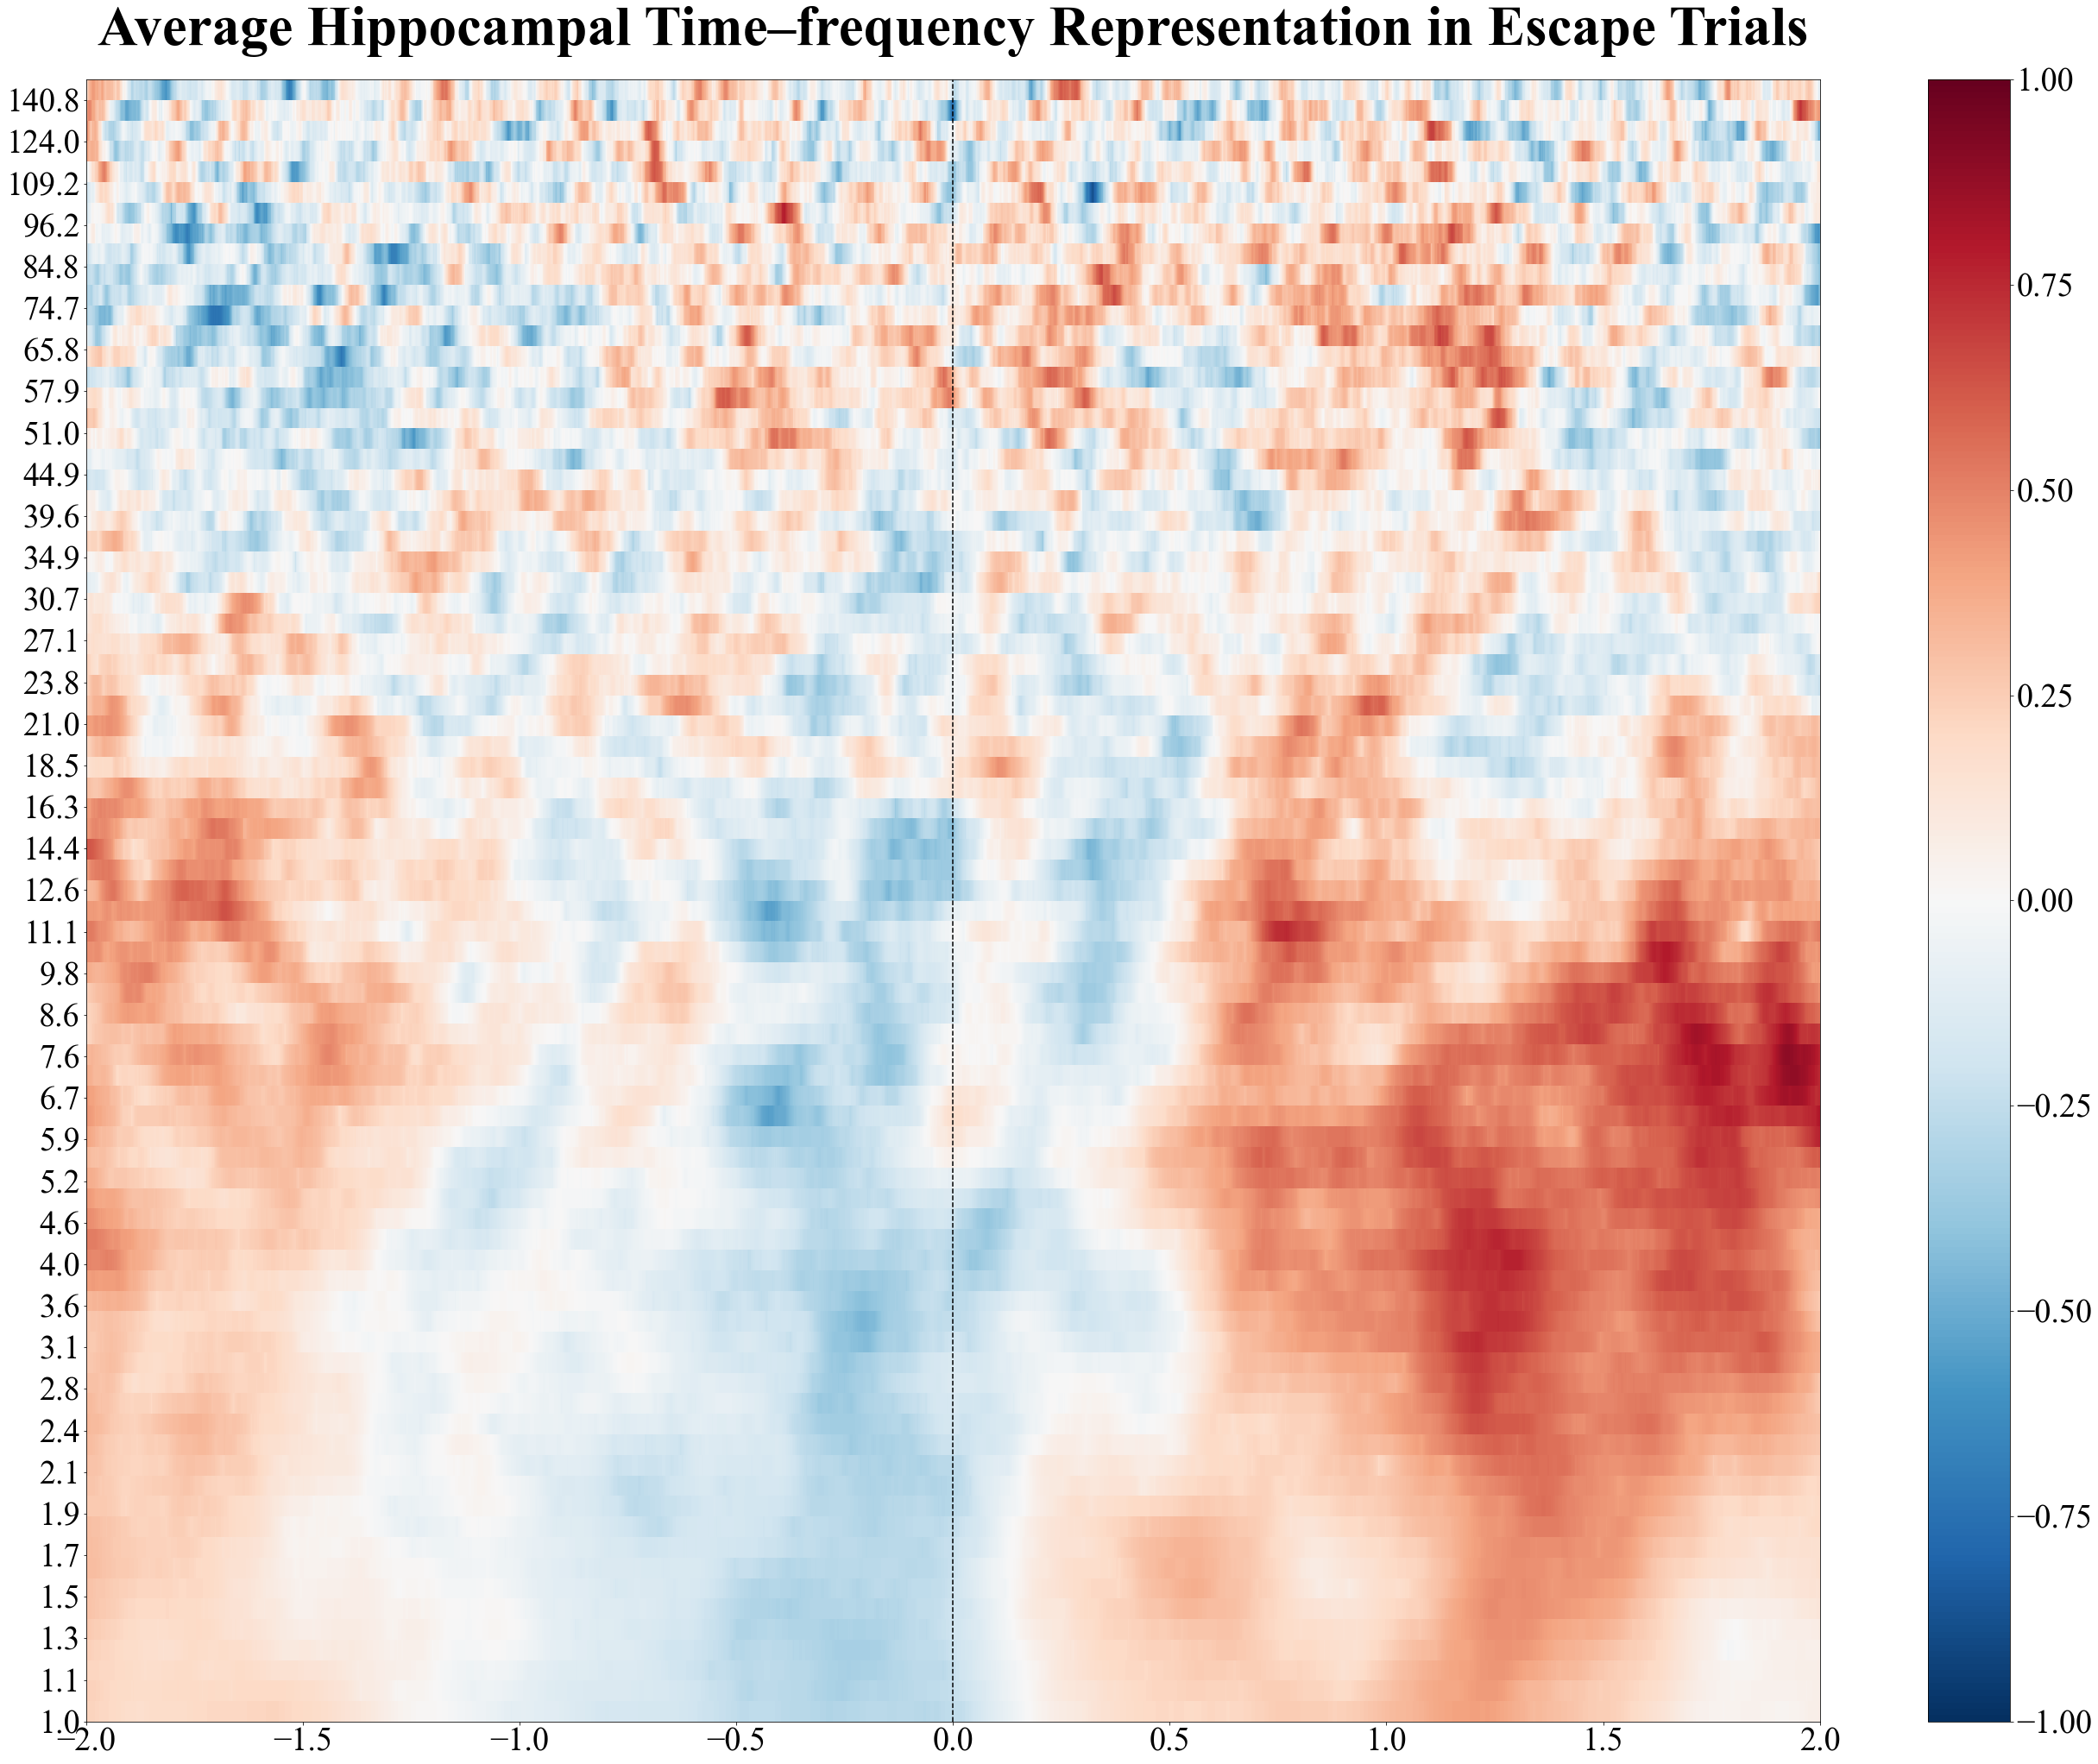

In [6]:
plot_allsub_averages(all_subs_average_hc_escape, "Average Hippocampal Time–frequency Representation in Escape Trials", 'average_hc_escape_all_subs.png', -2, 2)

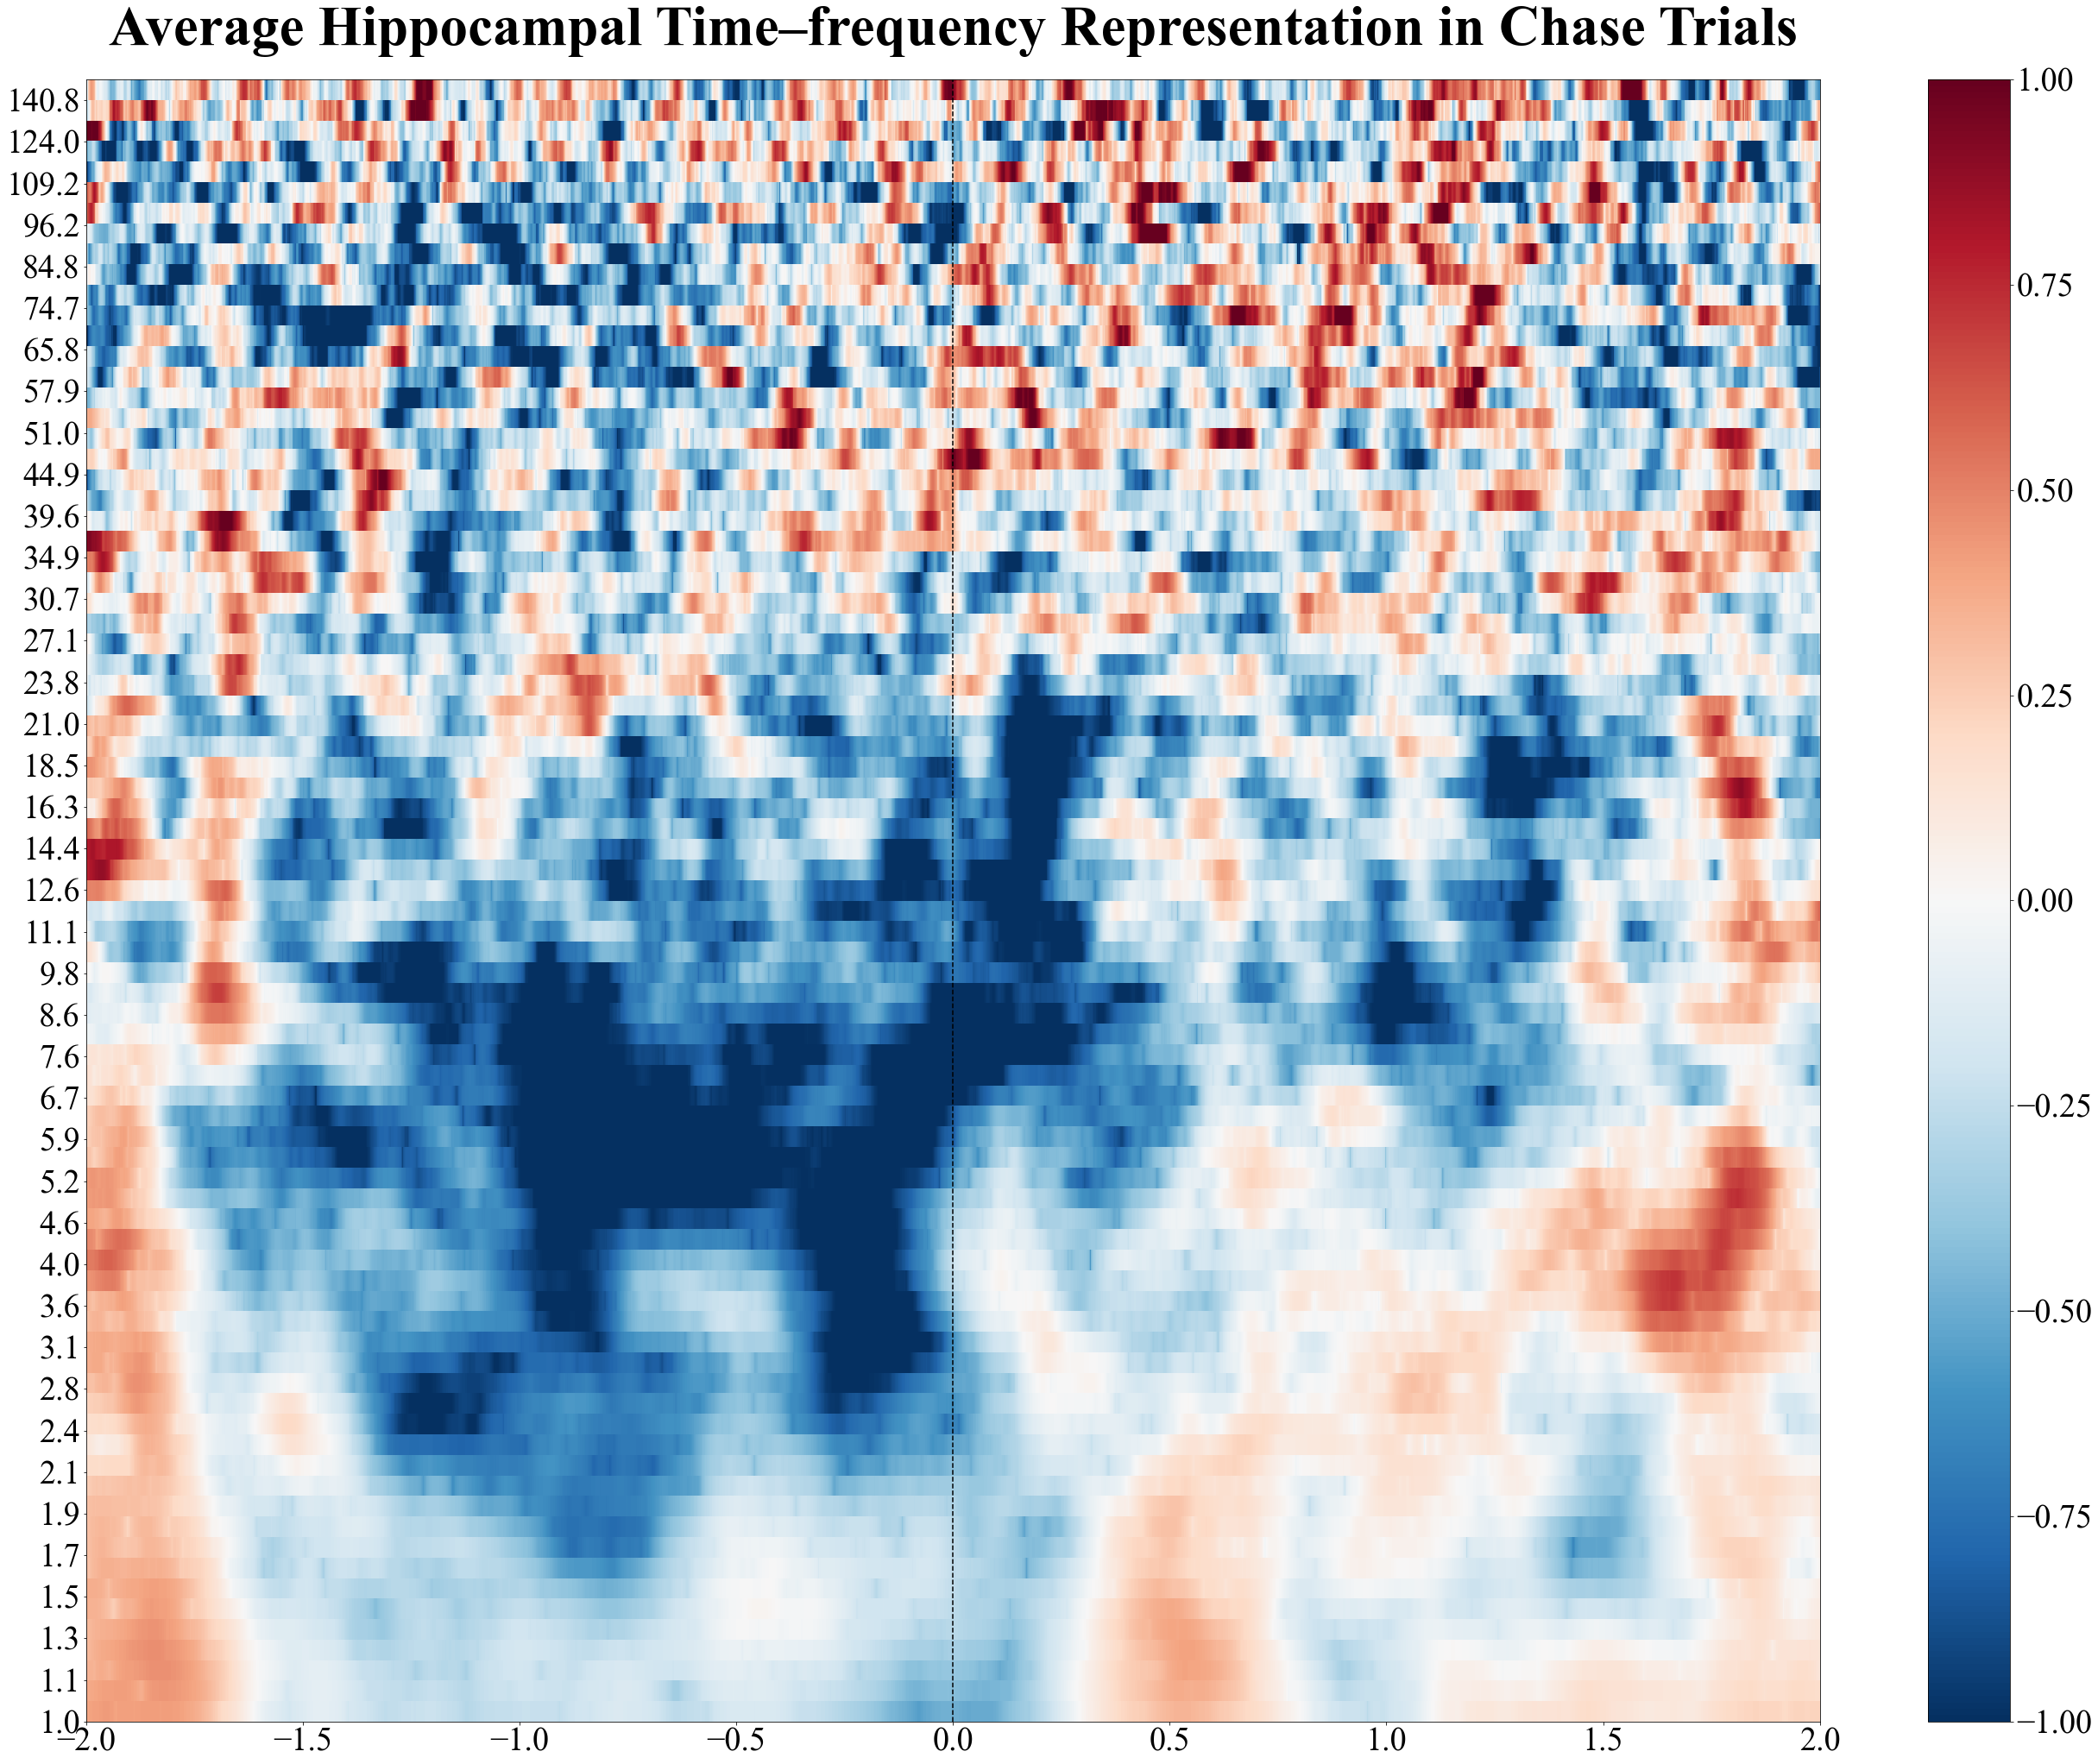

In [6]:
plot_allsub_averages(all_subs_average_hc_chase, "Average Hippocampal Time–frequency Representation in Chase Trials", 'average_hc_chase_all_subs.png', -2, 2)

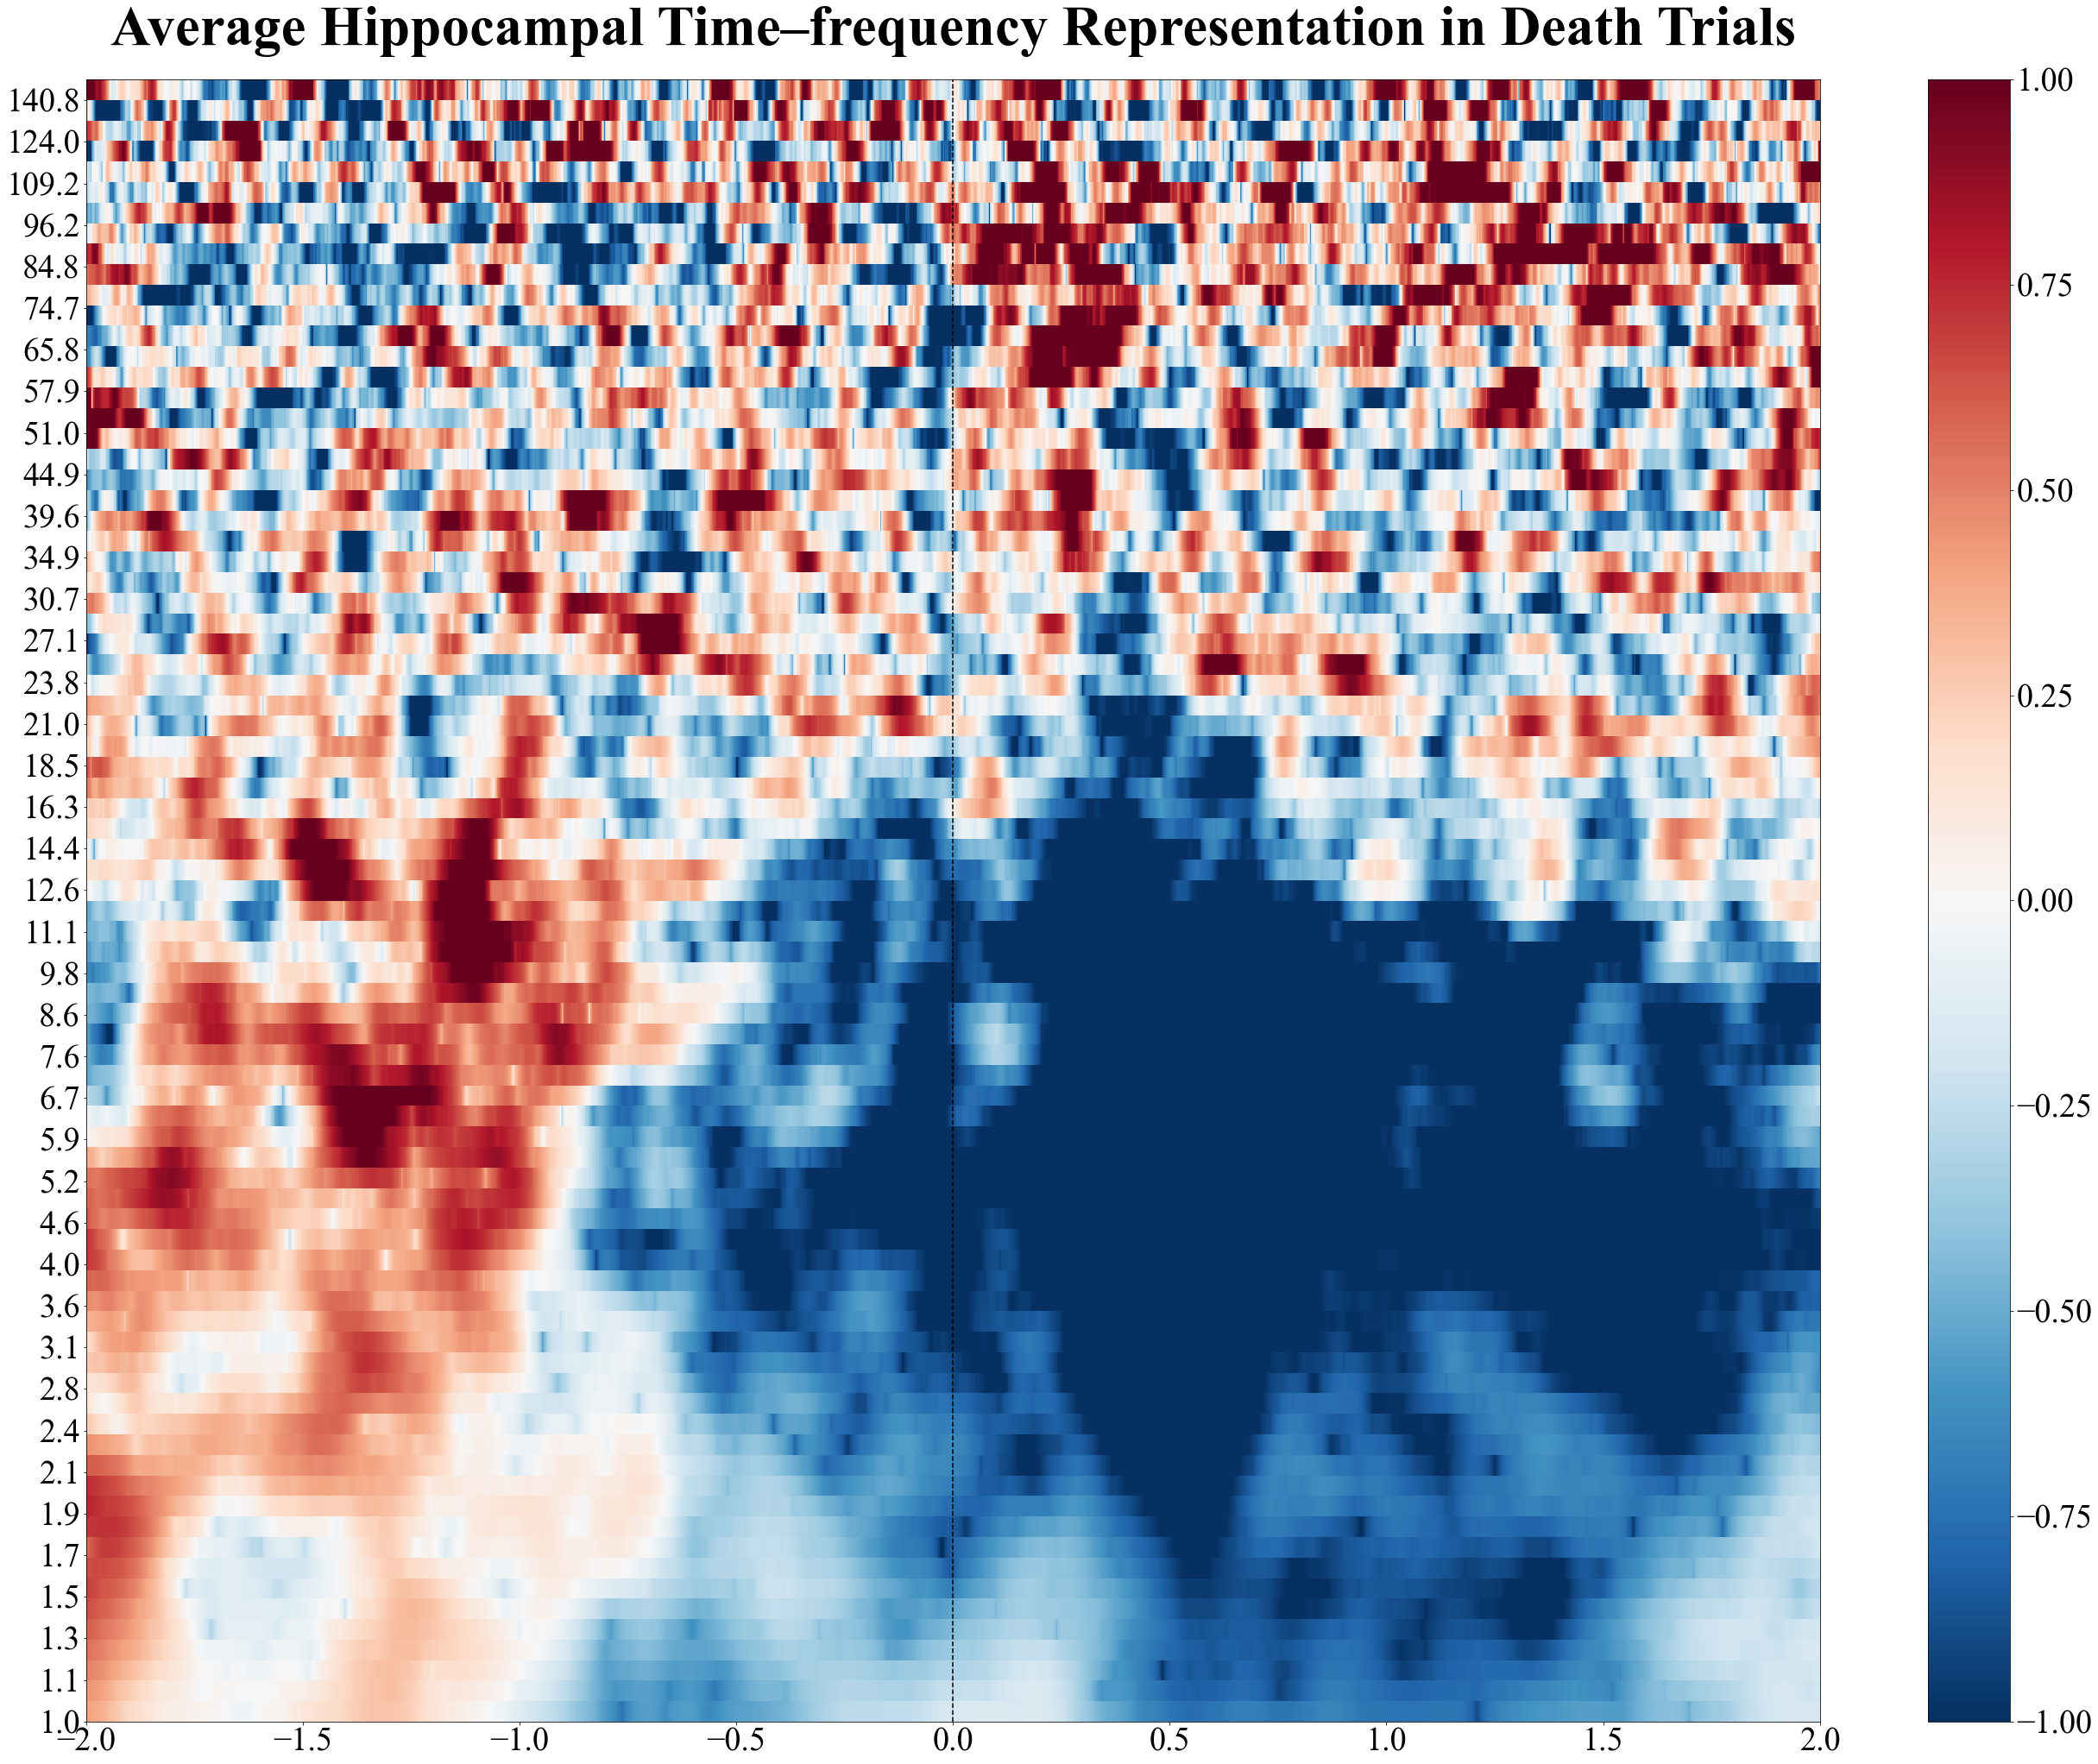

In [7]:
plot_allsub_averages(all_subs_average_hc_die, "Average Hippocampal Time–frequency Representation in Death Trials", 'average_hc_death_all_subs.png', -2, 2)

## OFC

In [8]:
all_subs_average_ofcs = calculate_trial_end_average(sub_list, conditions, 'ofc')
all_subs_average_ofc_escape = all_subs_average_ofcs[0]
all_subs_average_ofc_chase = all_subs_average_ofcs[1]
all_subs_average_ofc_die = all_subs_average_ofcs[2]

Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH021/ieeg/trial_end/ofc-tfr.h5 ...
Adding metadata with 6 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH021']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH025/ieeg/trial_end/ofc-tfr.h5 ...
Adding metadata with 6 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH021', 'BJH025']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH016/ieeg/trial_end/ofc-tfr.h5 ...
Adding metadata with 6 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH021', 'BJH025', 'BJH016']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/SLCH002/ieeg/trial_end/ofc-tfr.h5 ...
Adding metadata with 5 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH021', 'BJH025', 'BJH016', 'SLCH002']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH026/ieeg/trial_end/ofc-t

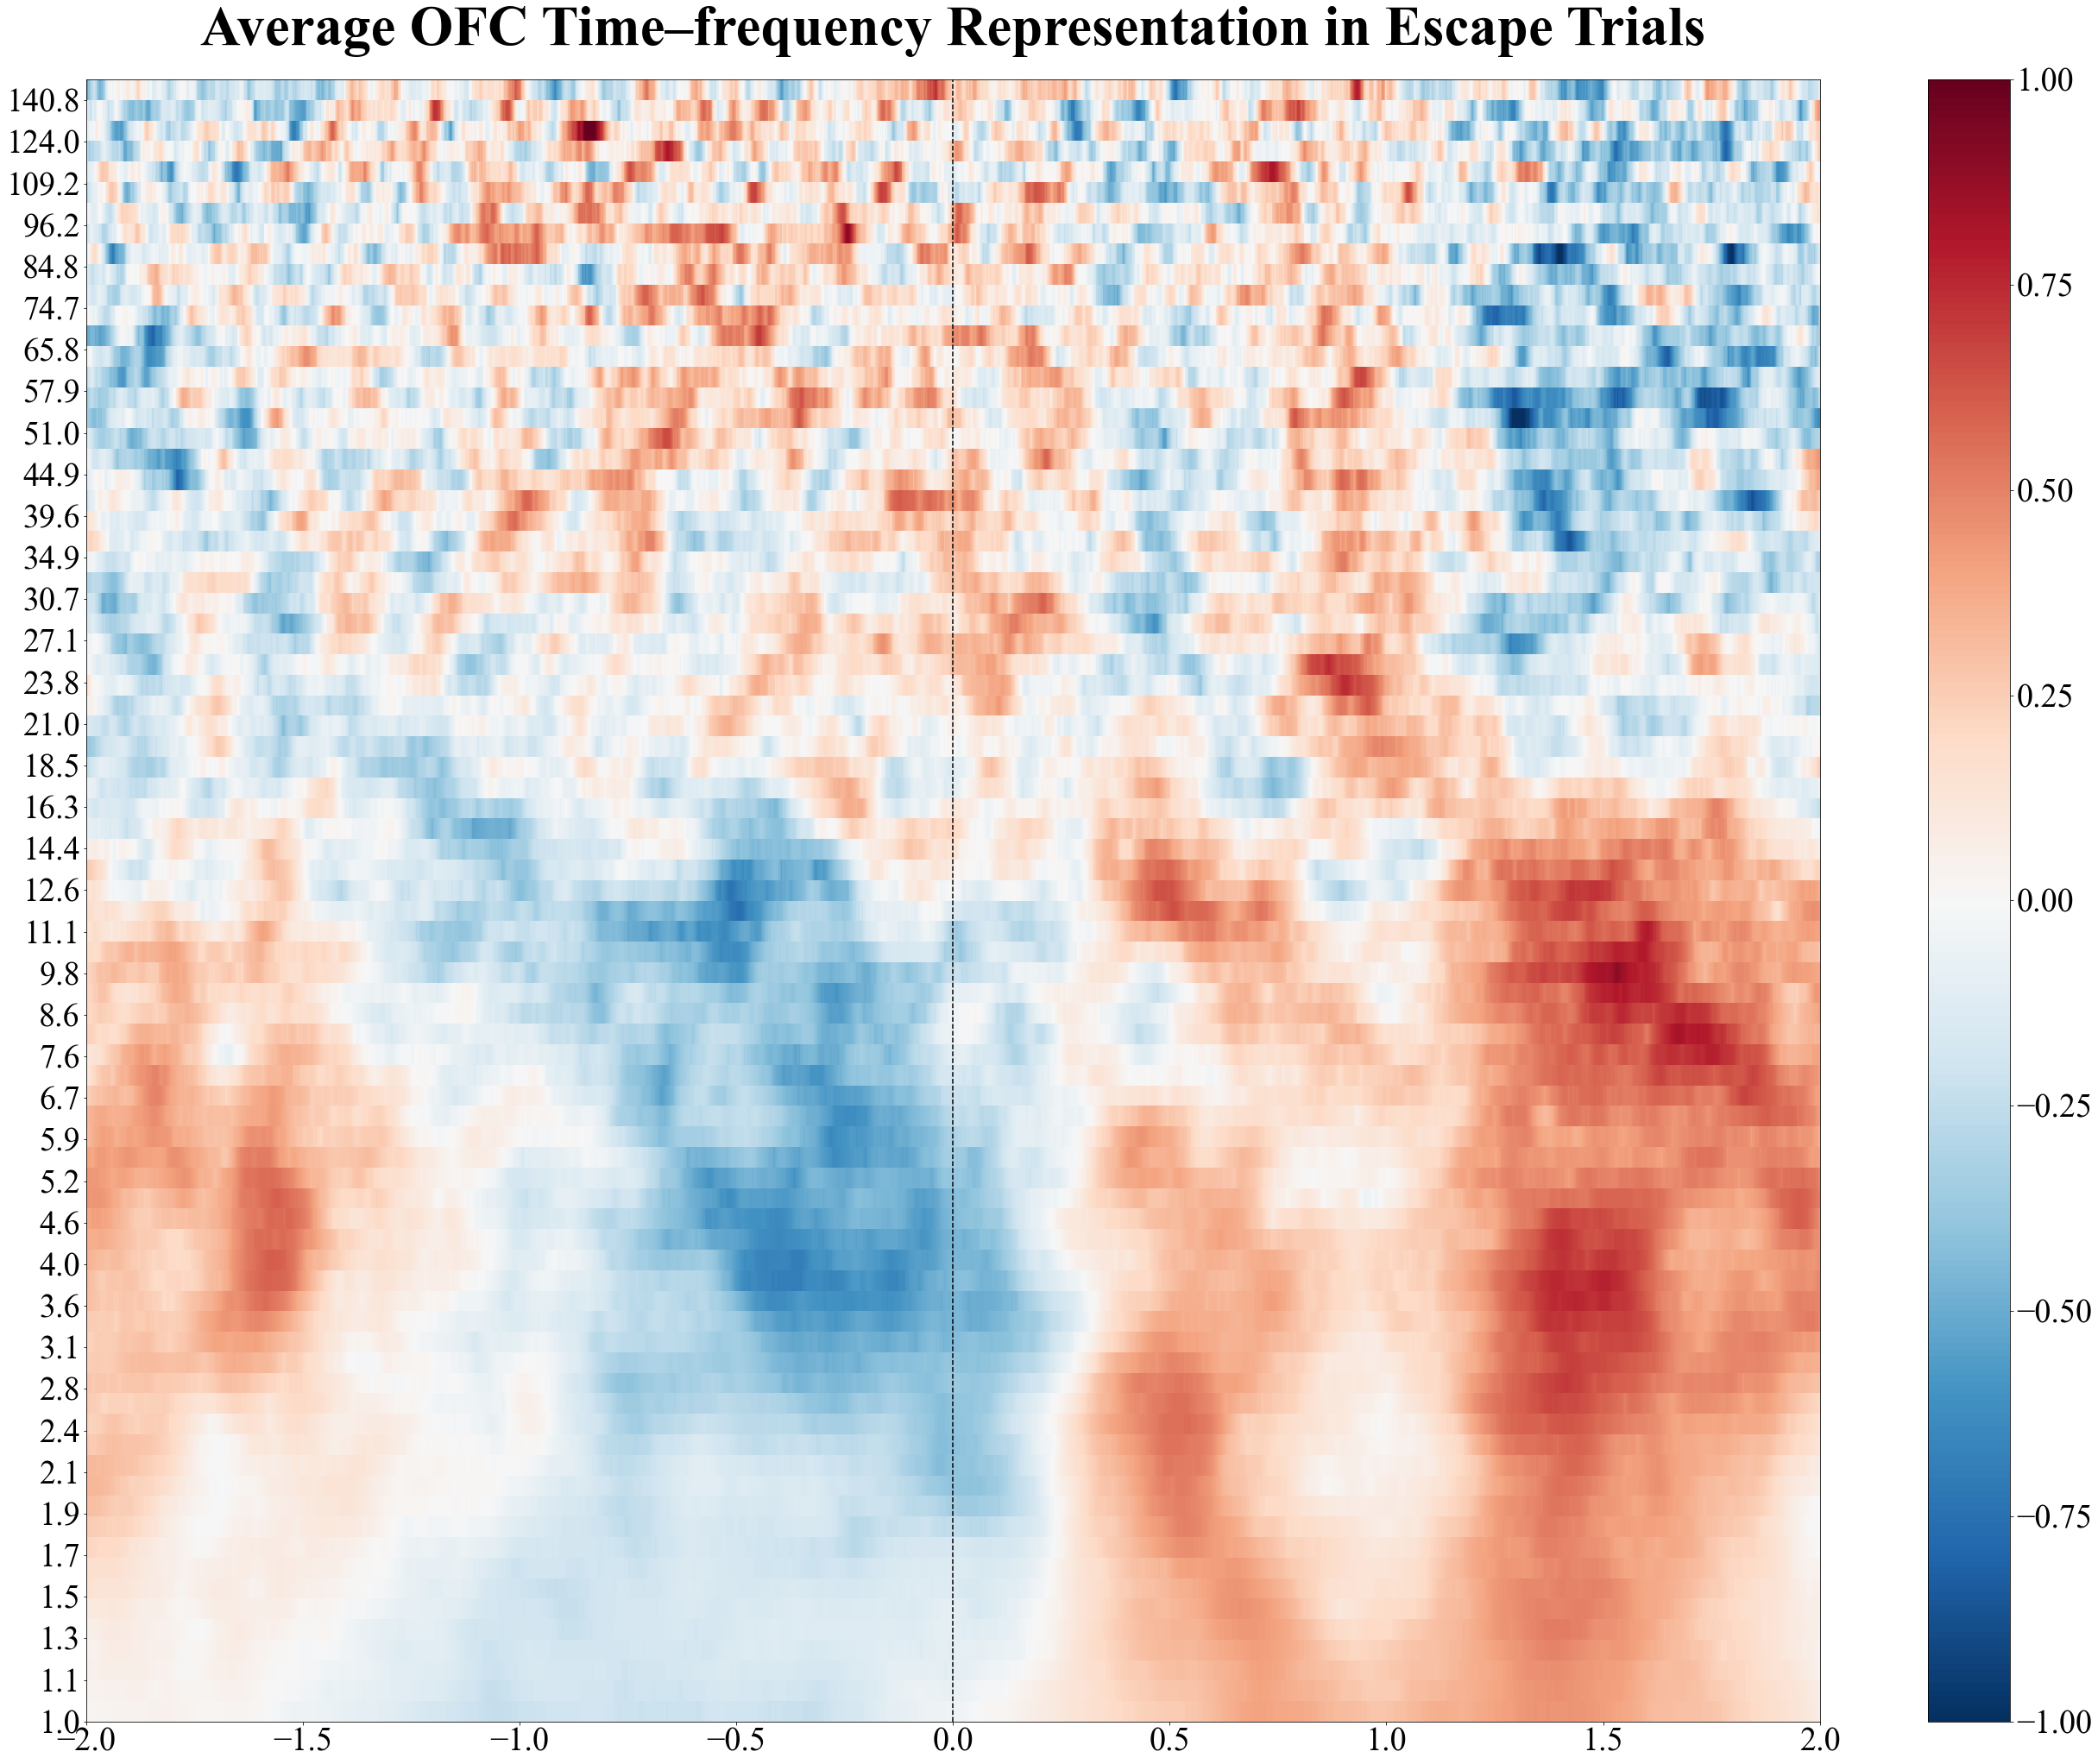

In [9]:
plot_allsub_averages(all_subs_average_ofc_escape, "Average OFC Time–frequency Representation in Escape Trials", 'average_ofc_escape_all_subs.png', -2, 2)

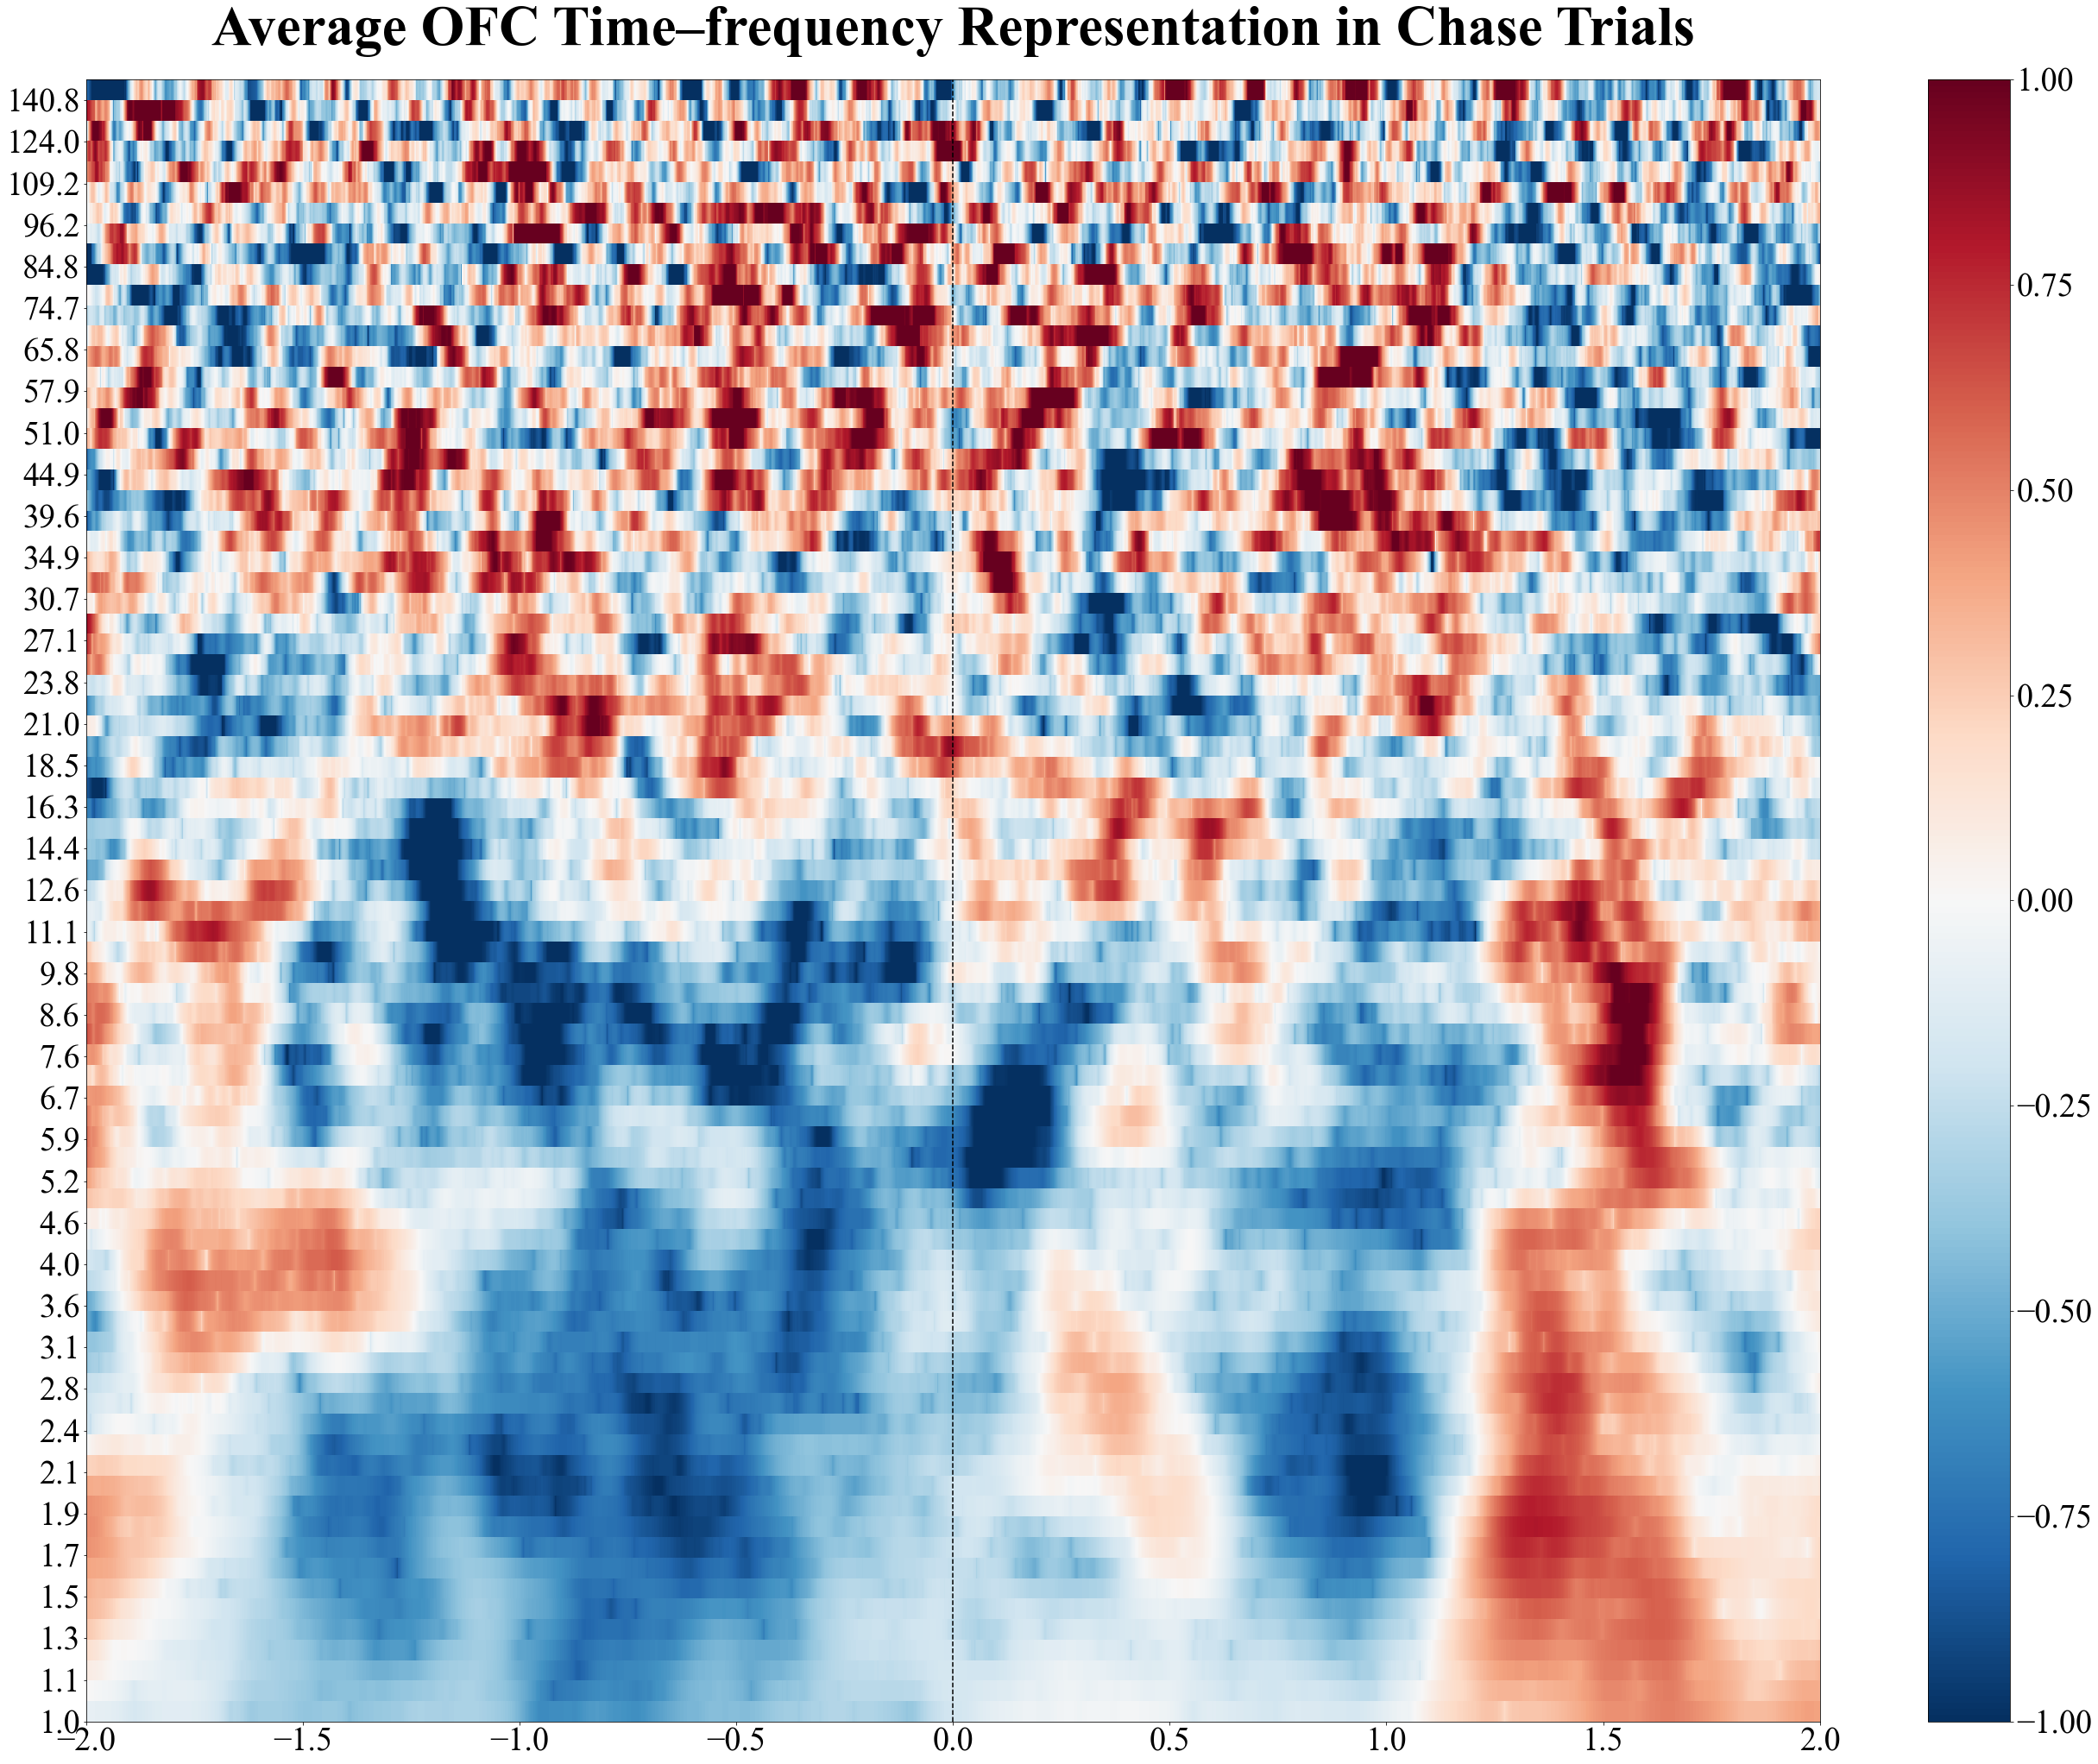

In [10]:
plot_allsub_averages(all_subs_average_ofc_chase, "Average OFC Time–frequency Representation in Chase Trials", 'average_ofc_chase_all_subs.png', -2, 2)

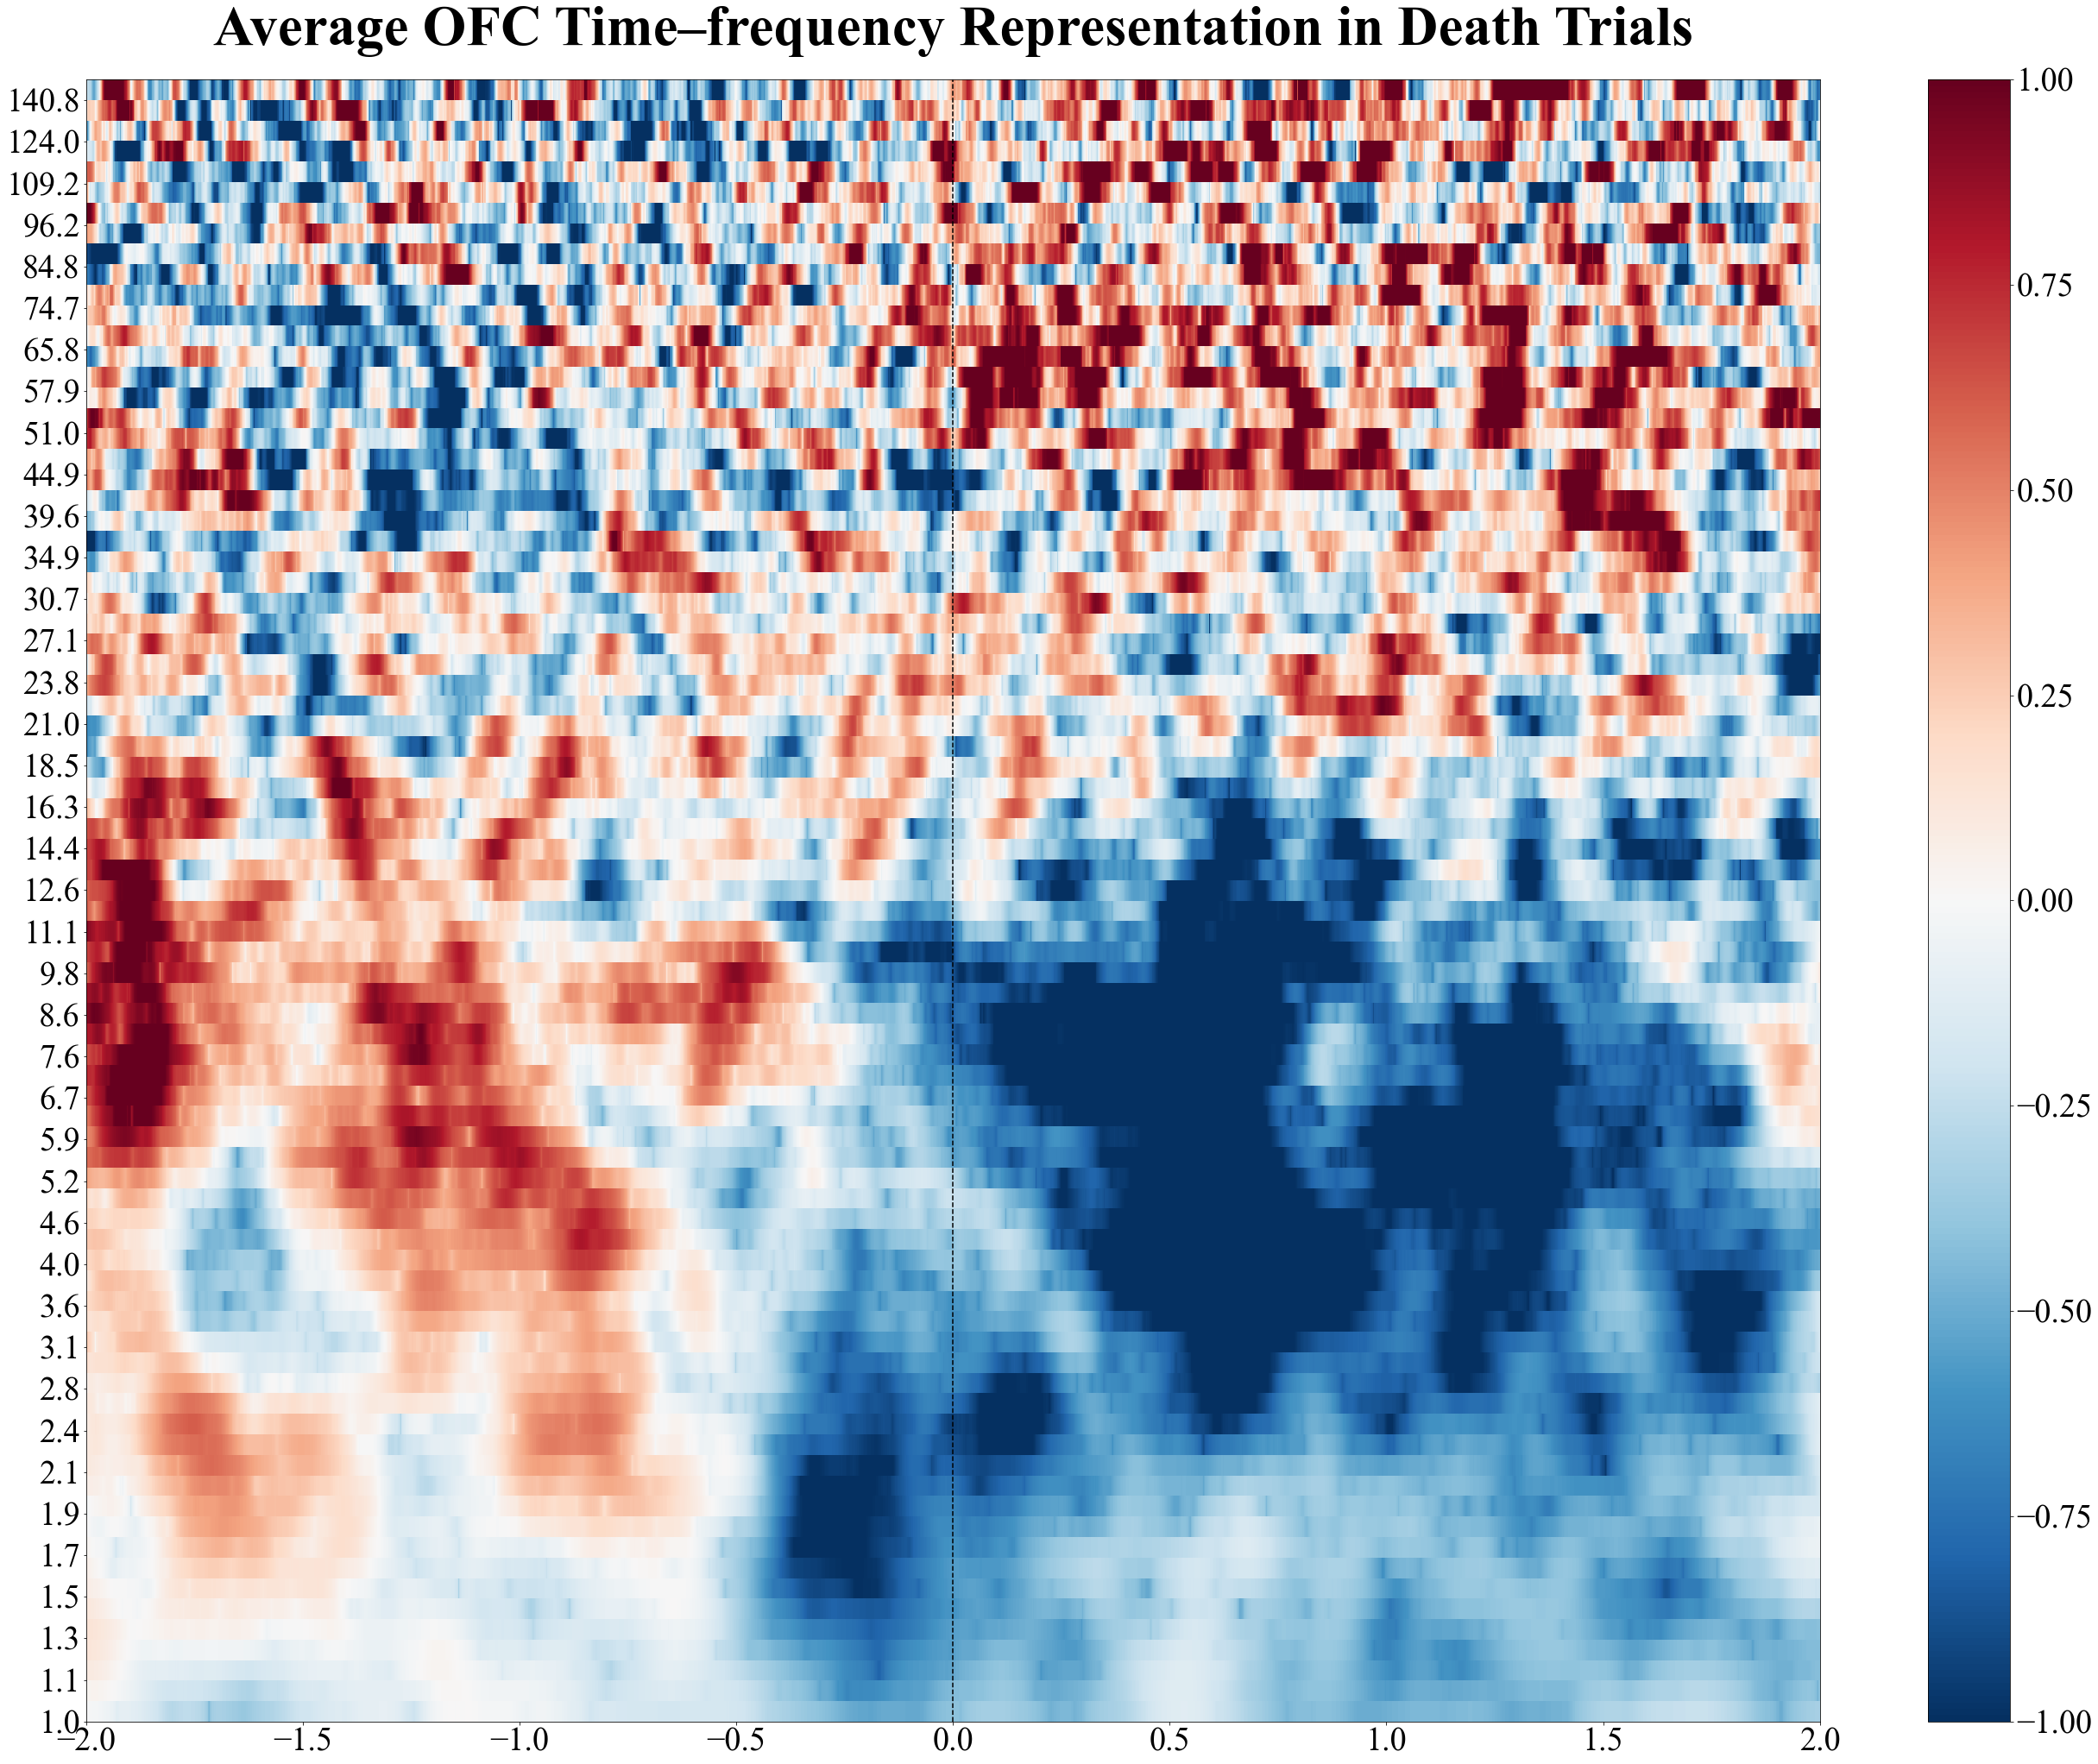

In [11]:
plot_allsub_averages(all_subs_average_ofc_die, "Average OFC Time–frequency Representation in Death Trials", 'average_ofc_death_all_subs.png', -2, 2)

## Anterior Cingulate

In [12]:
all_subs_average_cings = calculate_trial_end_average(sub_list, conditions, 'cing')
all_subs_average_cing_escape = all_subs_average_cings[0]
all_subs_average_cing_chase = all_subs_average_cings[1]
all_subs_average_cing_die = all_subs_average_cings[2]

Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH021/ieeg/trial_end/cing-tfr.h5 ...
Adding metadata with 6 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH021']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH025/ieeg/trial_end/cing-tfr.h5 ...
Adding metadata with 6 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH021', 'BJH025']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH016/ieeg/trial_end/cing-tfr.h5 ...
Adding metadata with 6 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH021', 'BJH025', 'BJH016']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/SLCH002/ieeg/trial_end/cing-tfr.h5 ...
Adding metadata with 5 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH021', 'BJH025', 'BJH016', 'SLCH002']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH026/ieeg/trial_end/c

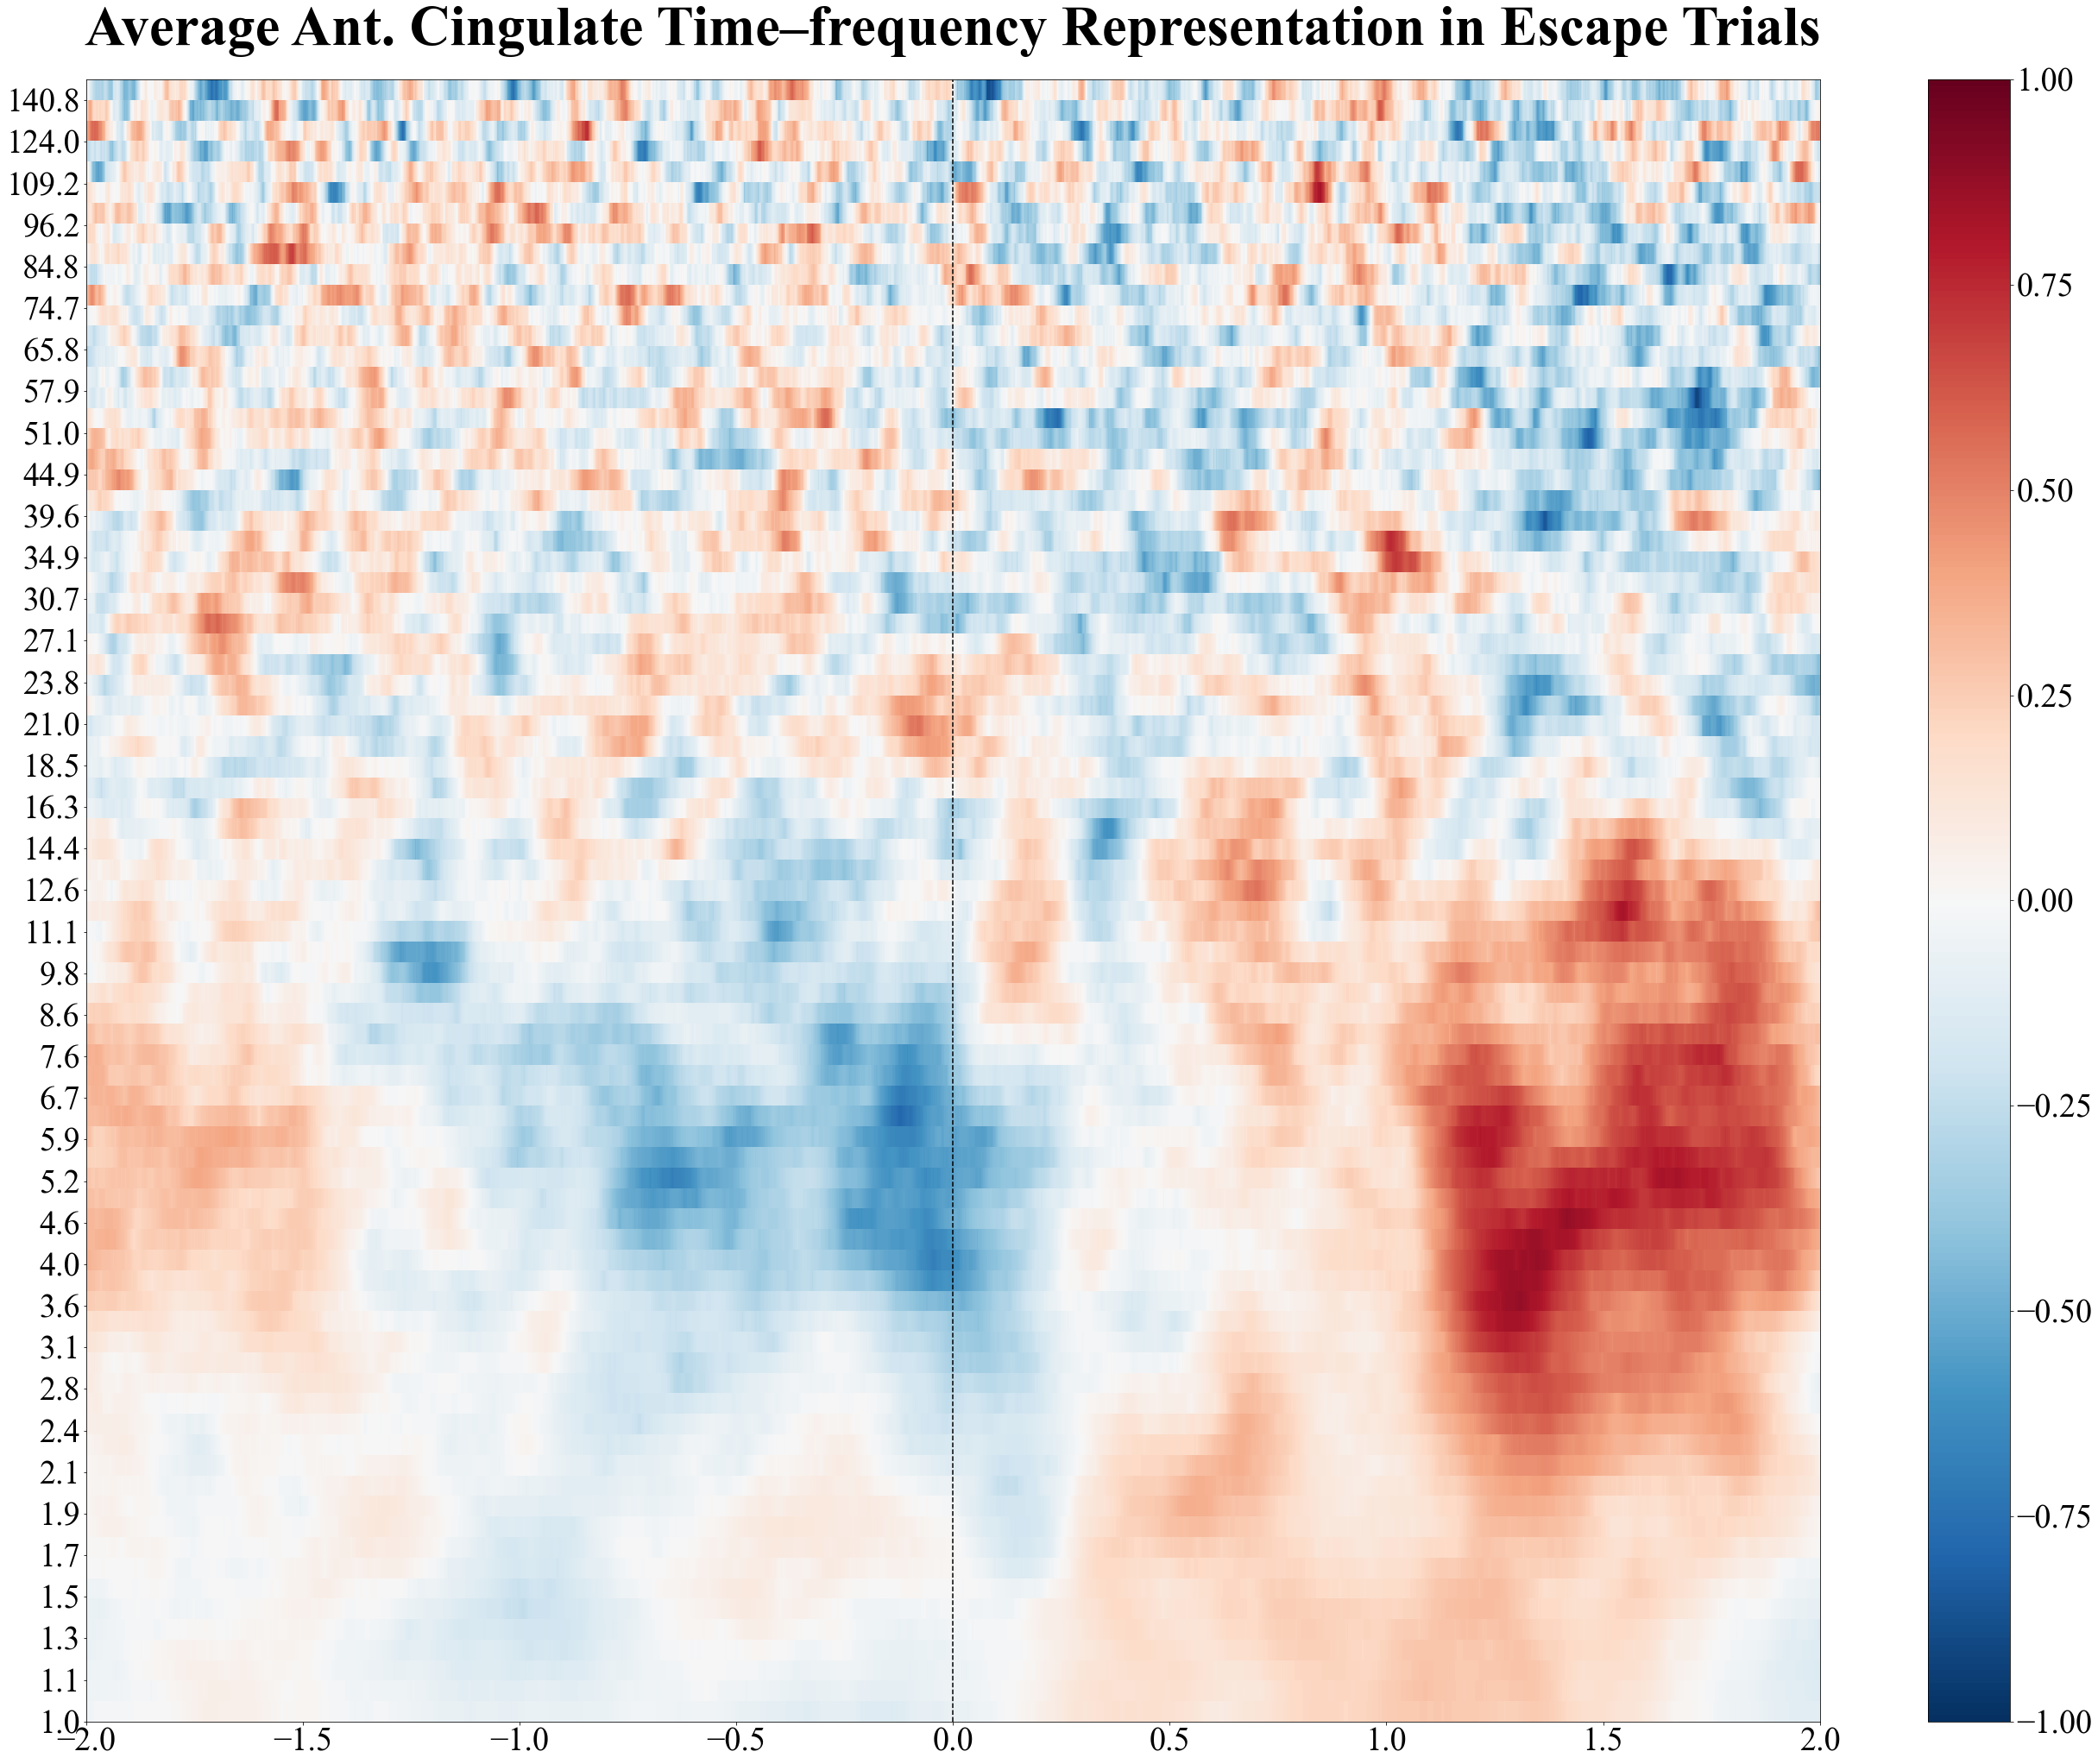

In [13]:
plot_allsub_averages(all_subs_average_cing_escape, "Average Ant. Cingulate Time–frequency Representation in Escape Trials", 'average_cing_escape_all_subs.png', -2, 2)

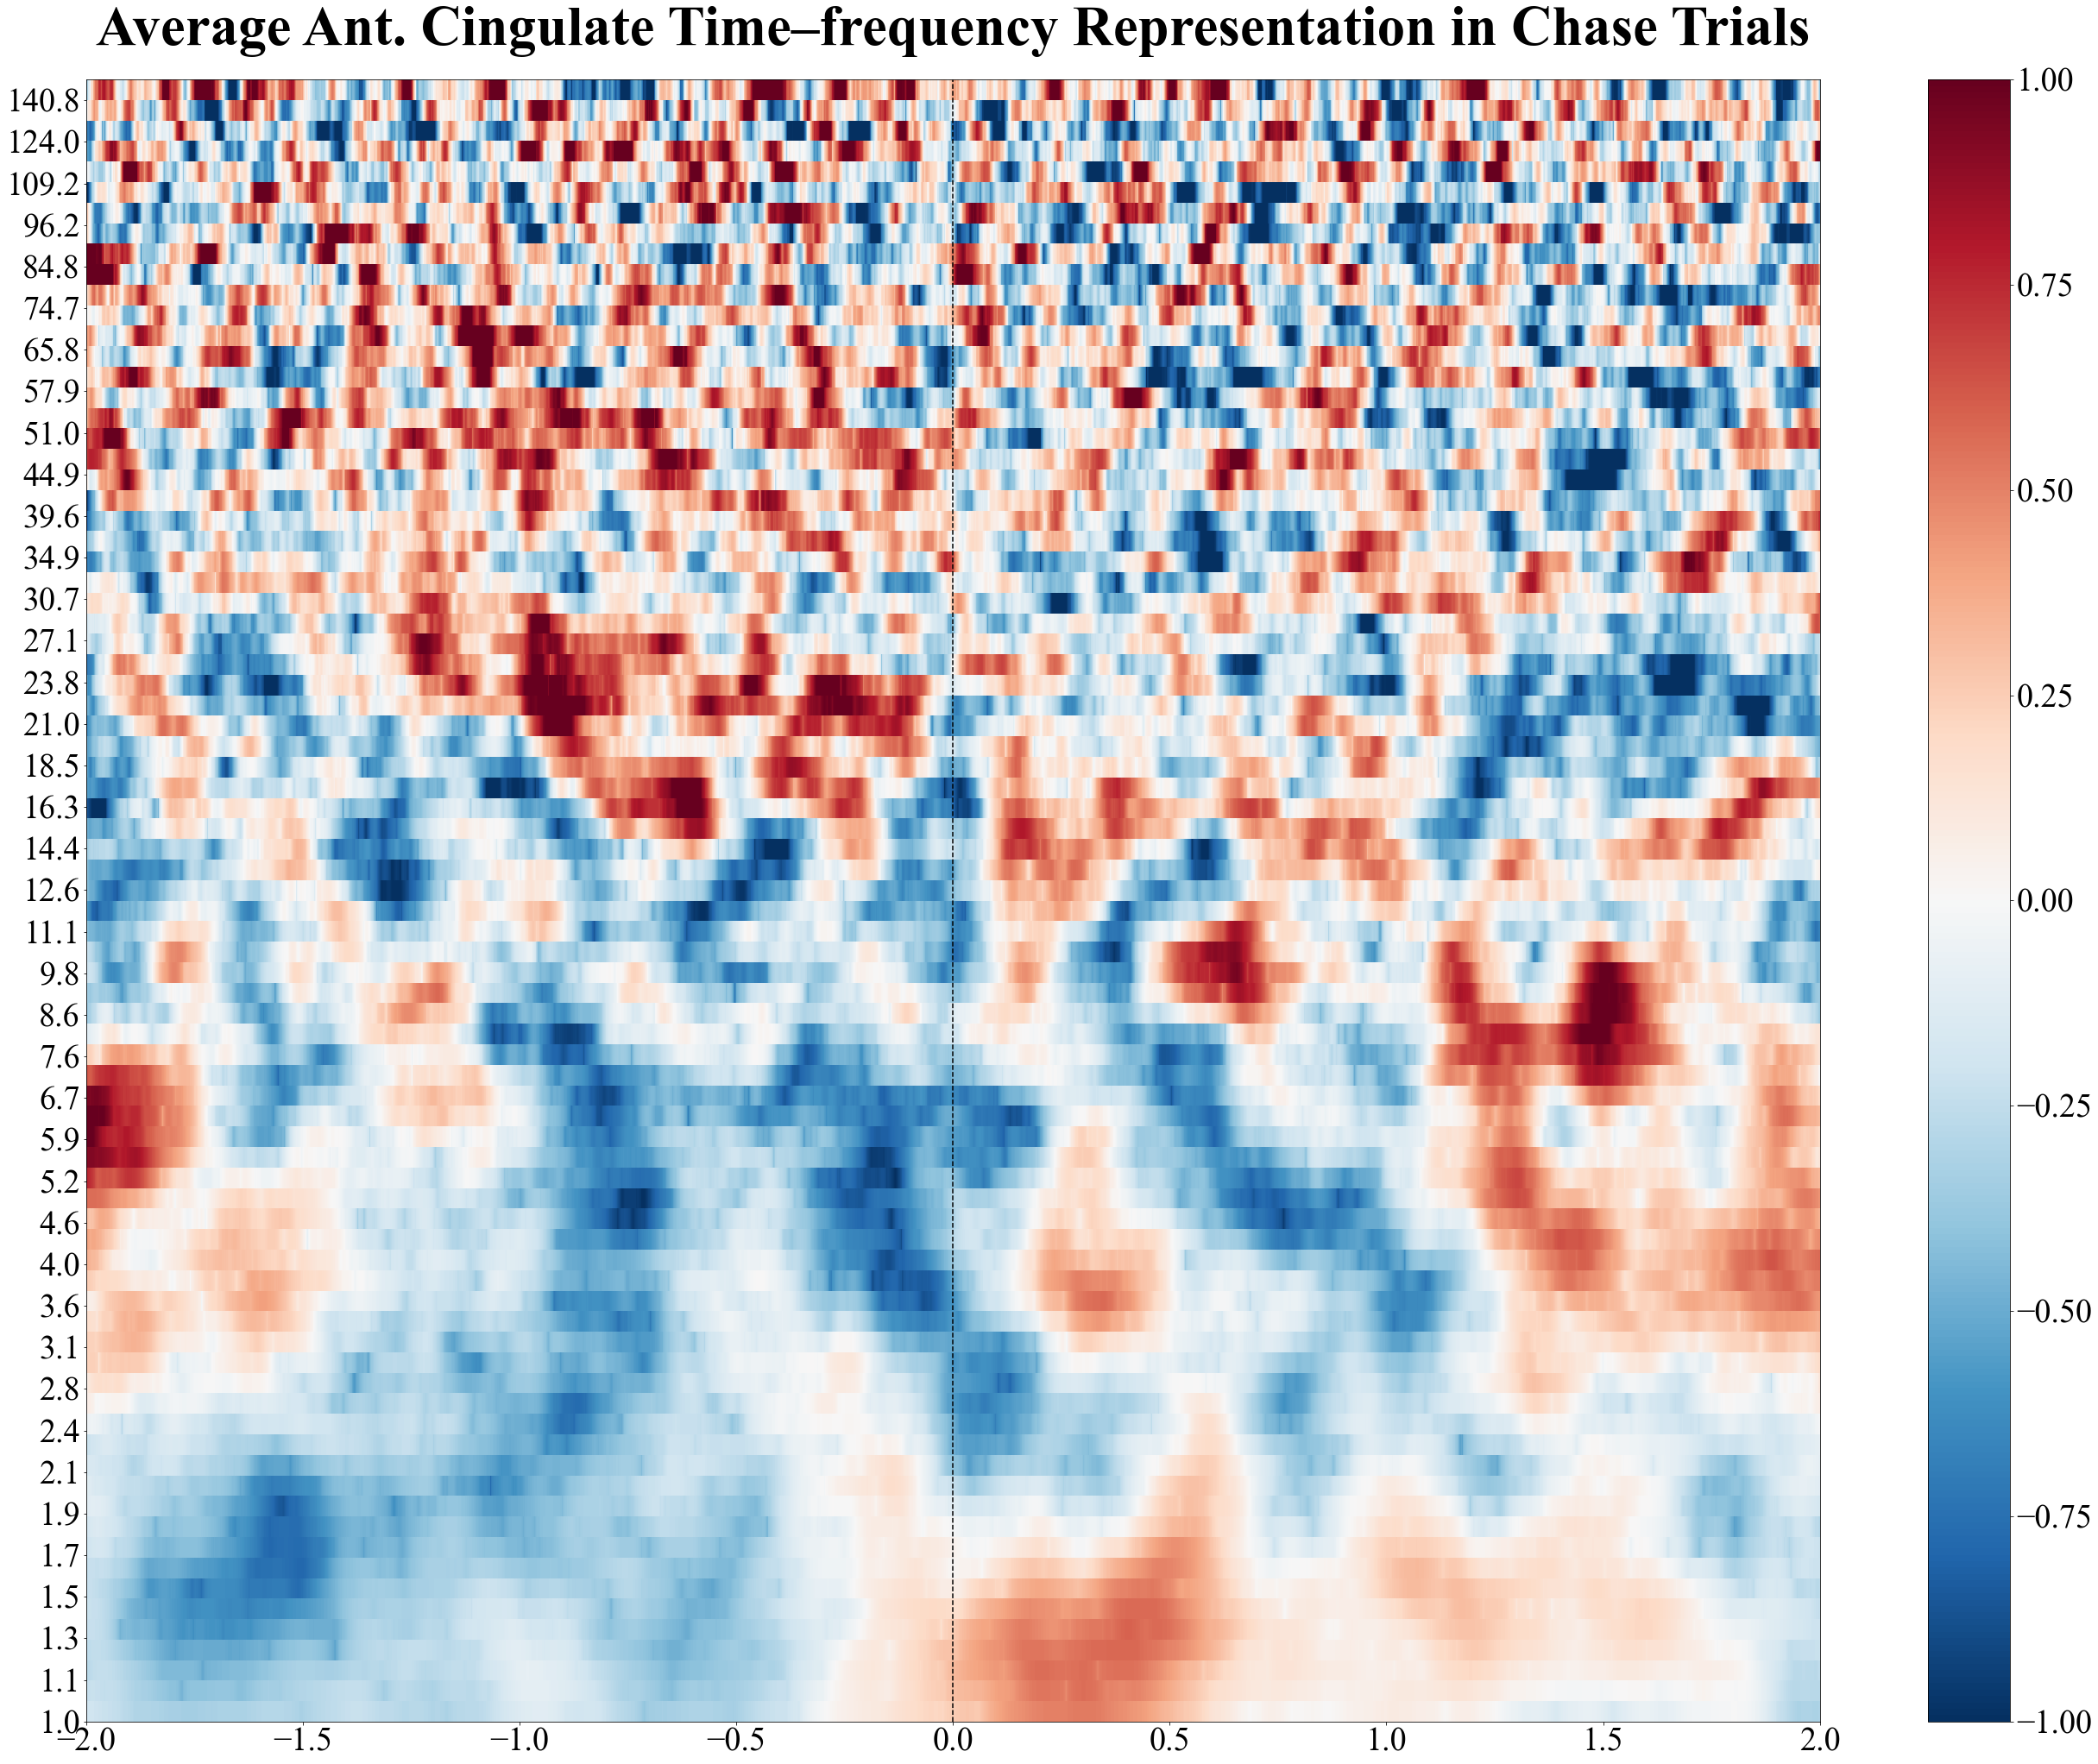

In [14]:
plot_allsub_averages(all_subs_average_cing_chase, "Average Ant. Cingulate Time–frequency Representation in Chase Trials", 'average_cing_chase_all_subs.png', -2, 2)

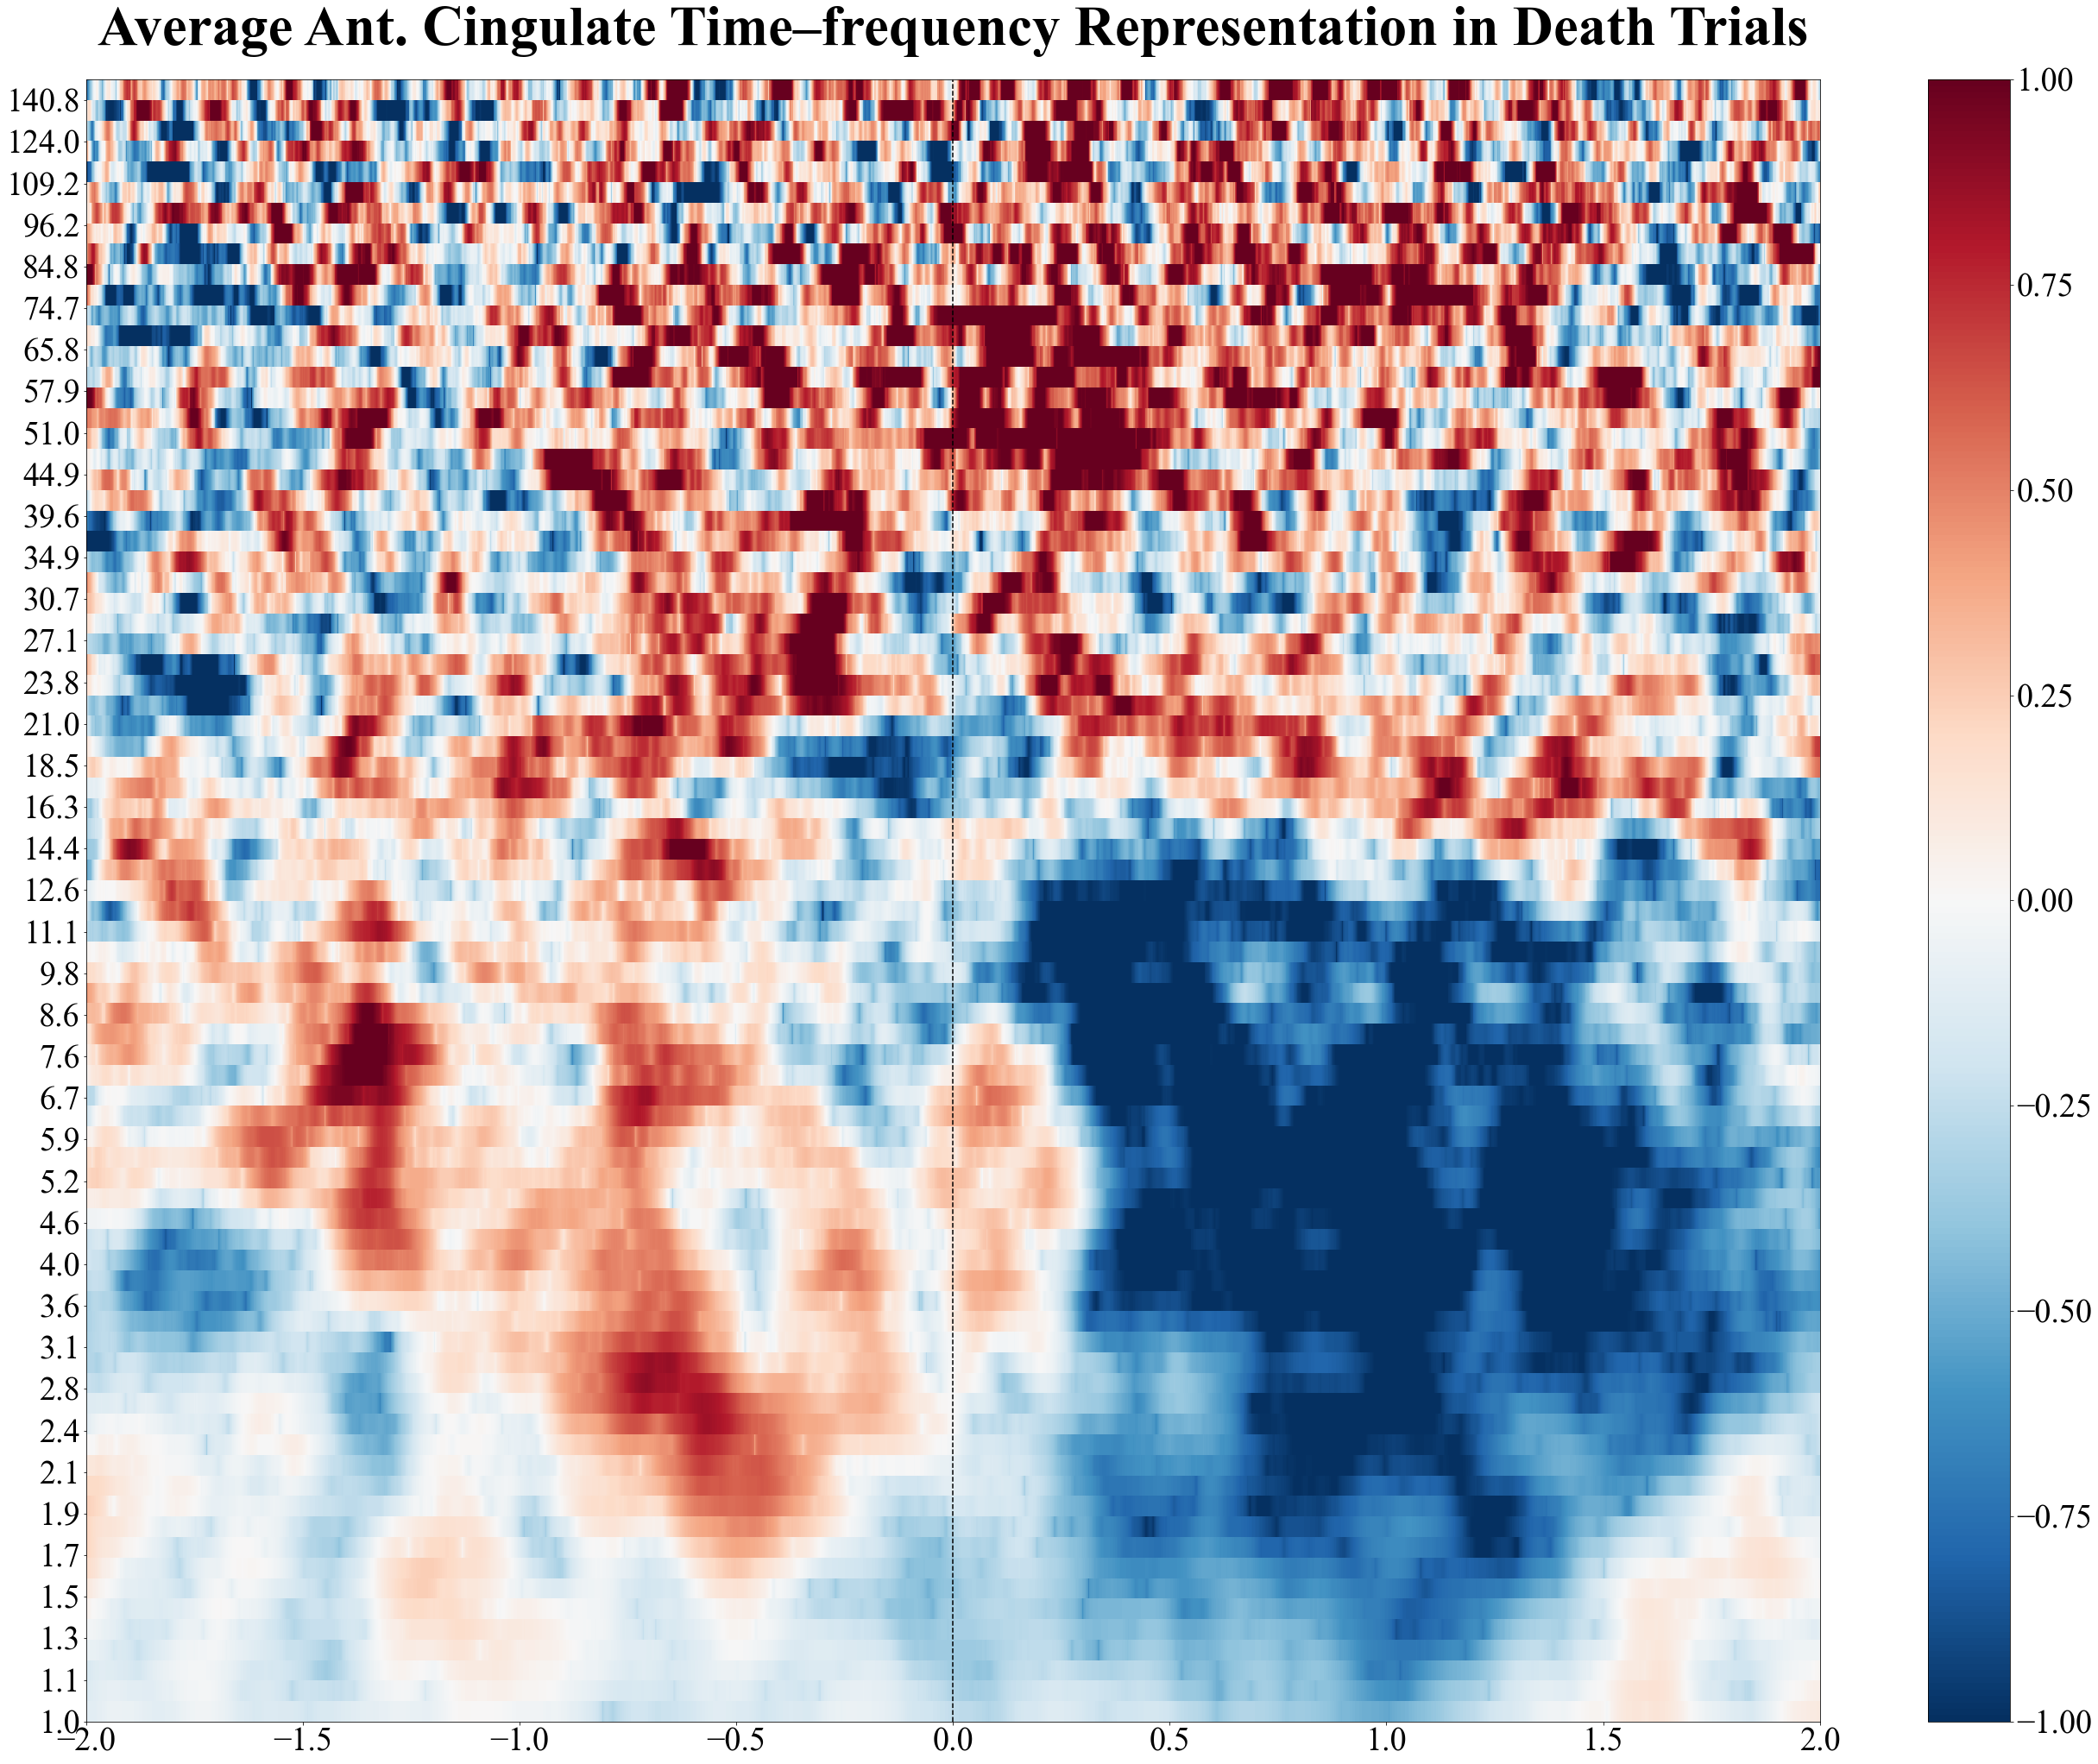

In [15]:
plot_allsub_averages(all_subs_average_cing_die, "Average Ant. Cingulate Time–frequency Representation in Death Trials", 'average_cing_death_all_subs.png', -2, 2)

## Amygdala

In [16]:
all_subs_average_amygs = calculate_trial_end_average(sub_list, conditions, 'amyg')
all_subs_average_amyg_escape = all_subs_average_amygs[0]
all_subs_average_amyg_chase = all_subs_average_amygs[1]
all_subs_average_amyg_die = all_subs_average_amygs[2]

Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH021/ieeg/trial_end/amyg-tfr.h5 ...
Adding metadata with 6 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH021']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH025/ieeg/trial_end/amyg-tfr.h5 ...
Adding metadata with 6 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH021', 'BJH025']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH016/ieeg/trial_end/amyg-tfr.h5 ...
Adding metadata with 6 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH021', 'BJH025', 'BJH016']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/SLCH002/ieeg/trial_end/amyg-tfr.h5 ...
Adding metadata with 5 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH021', 'BJH025', 'BJH016', 'SLCH002']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH026/ieeg/trial_end/a

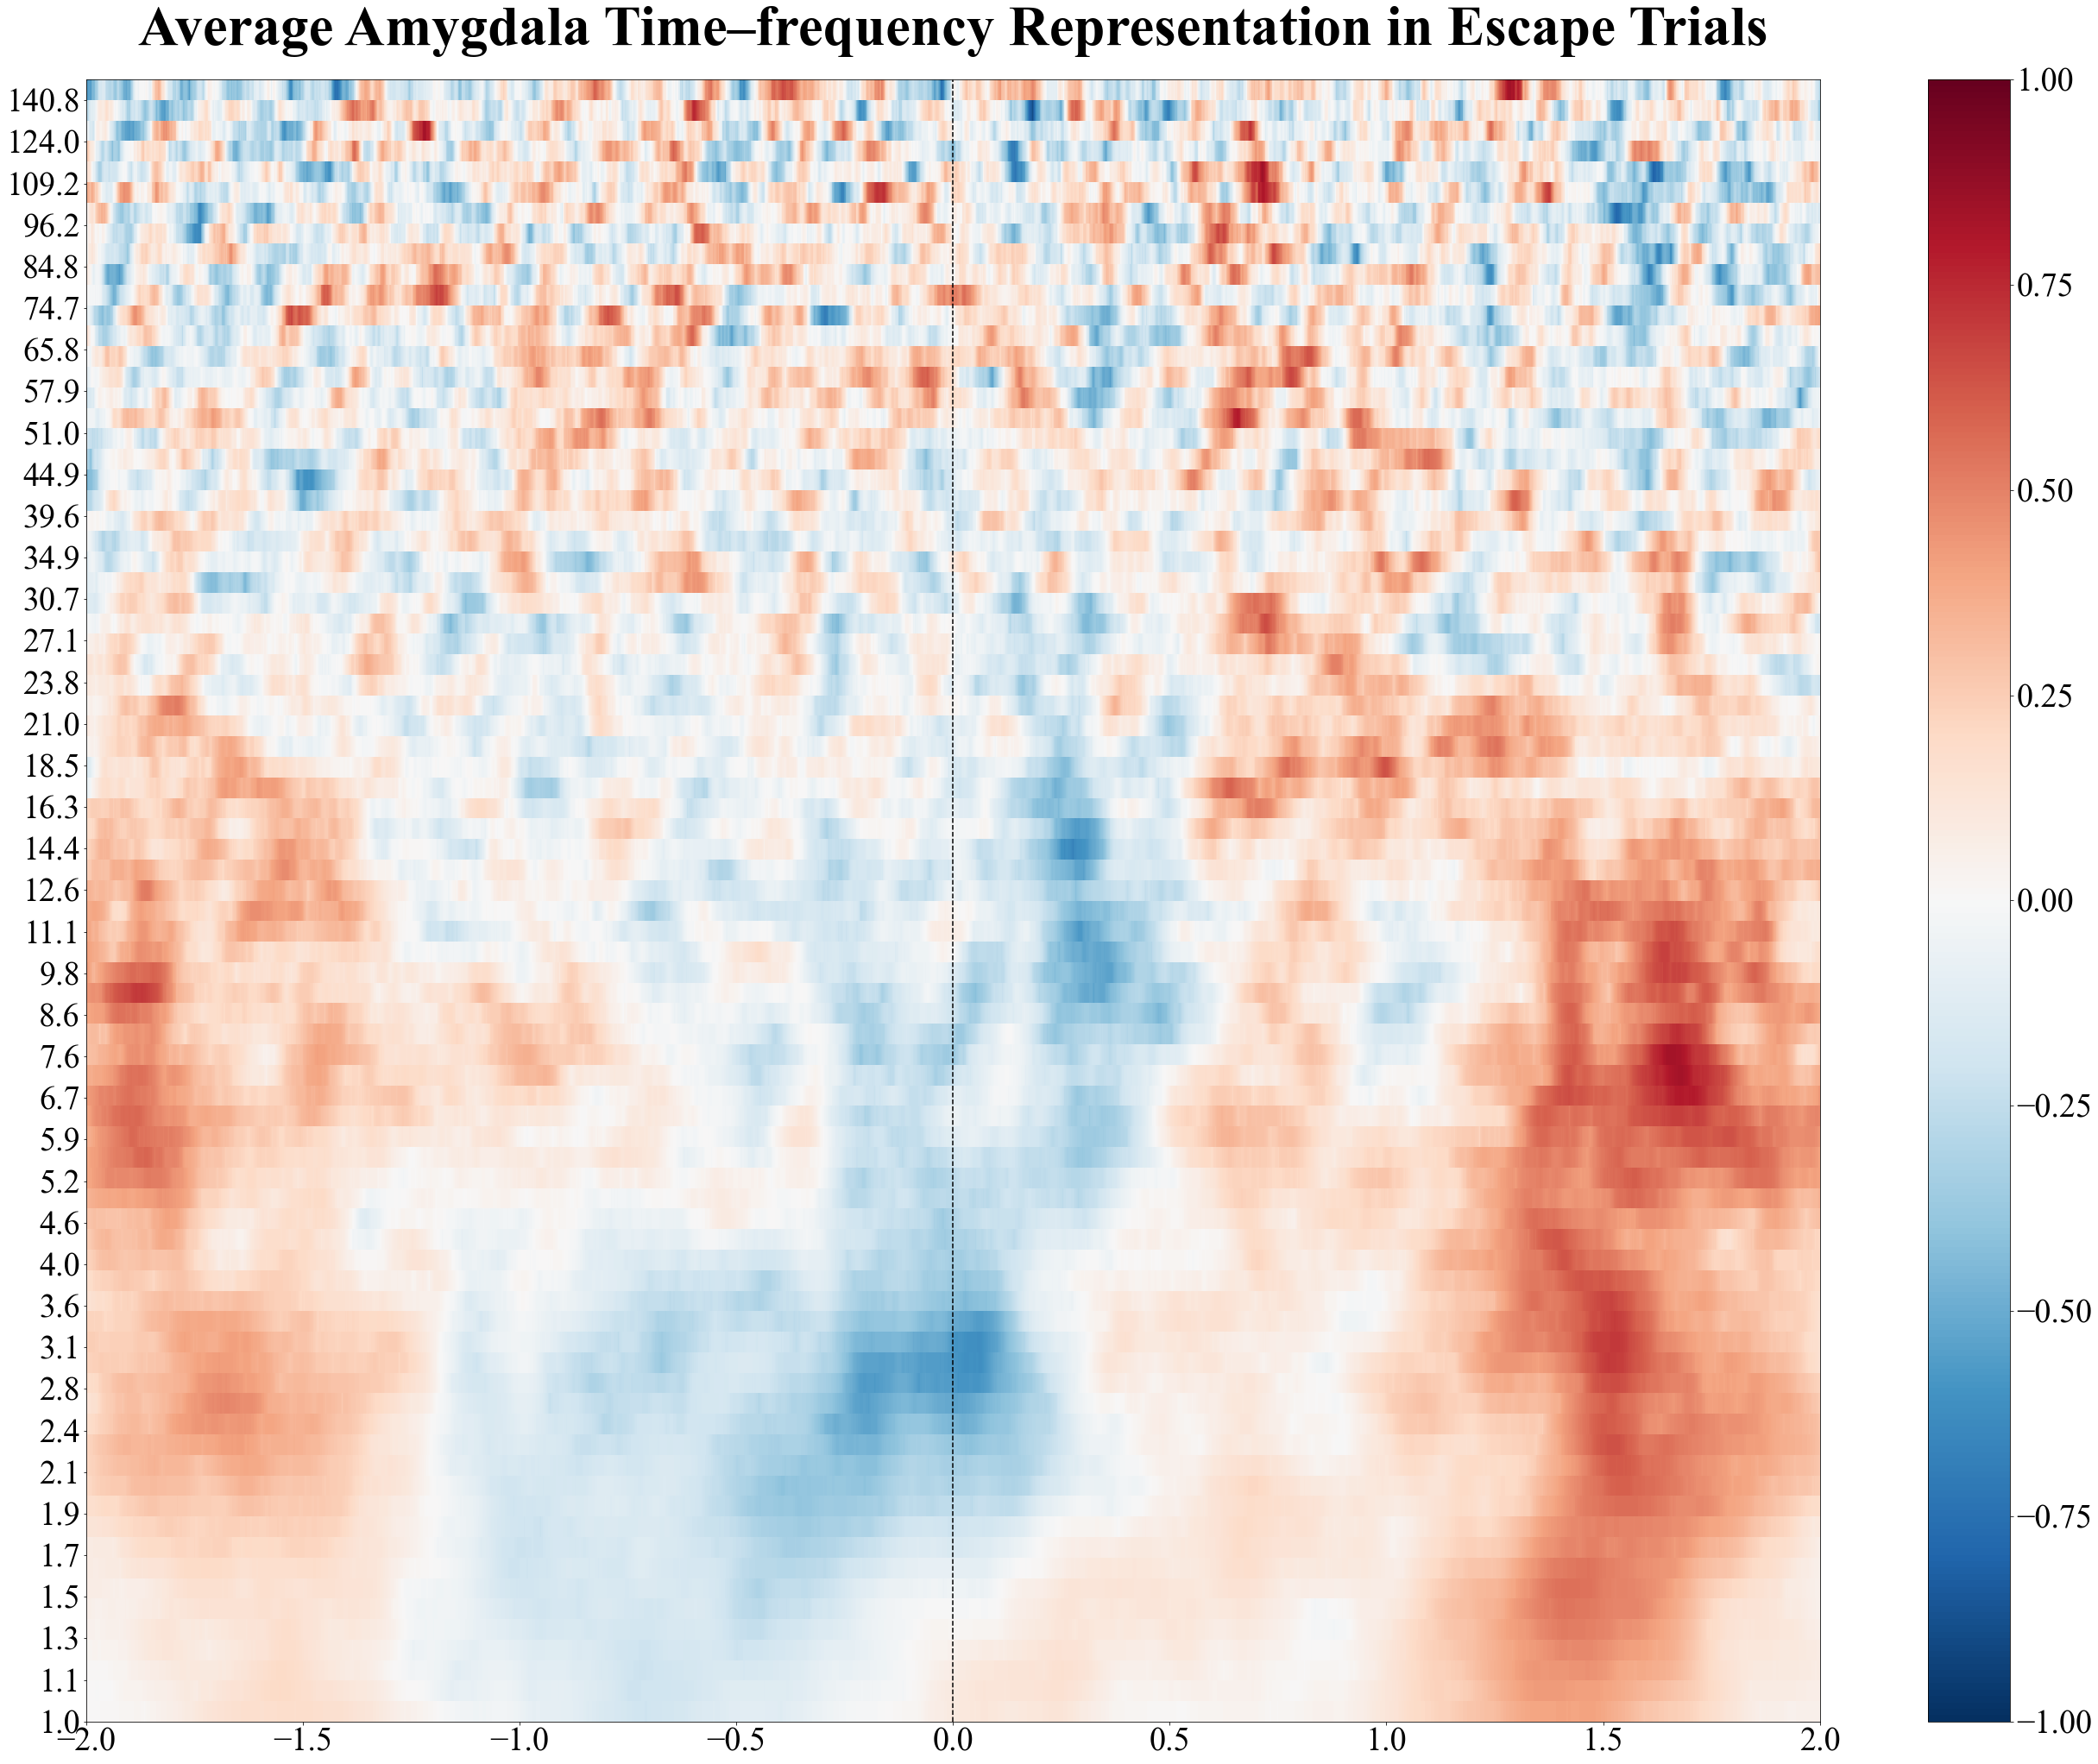

In [17]:
plot_allsub_averages(all_subs_average_amyg_escape, "Average Amygdala Time–frequency Representation in Escape Trials", 'average_amyg_escape_all_subs.png', -2, 2)

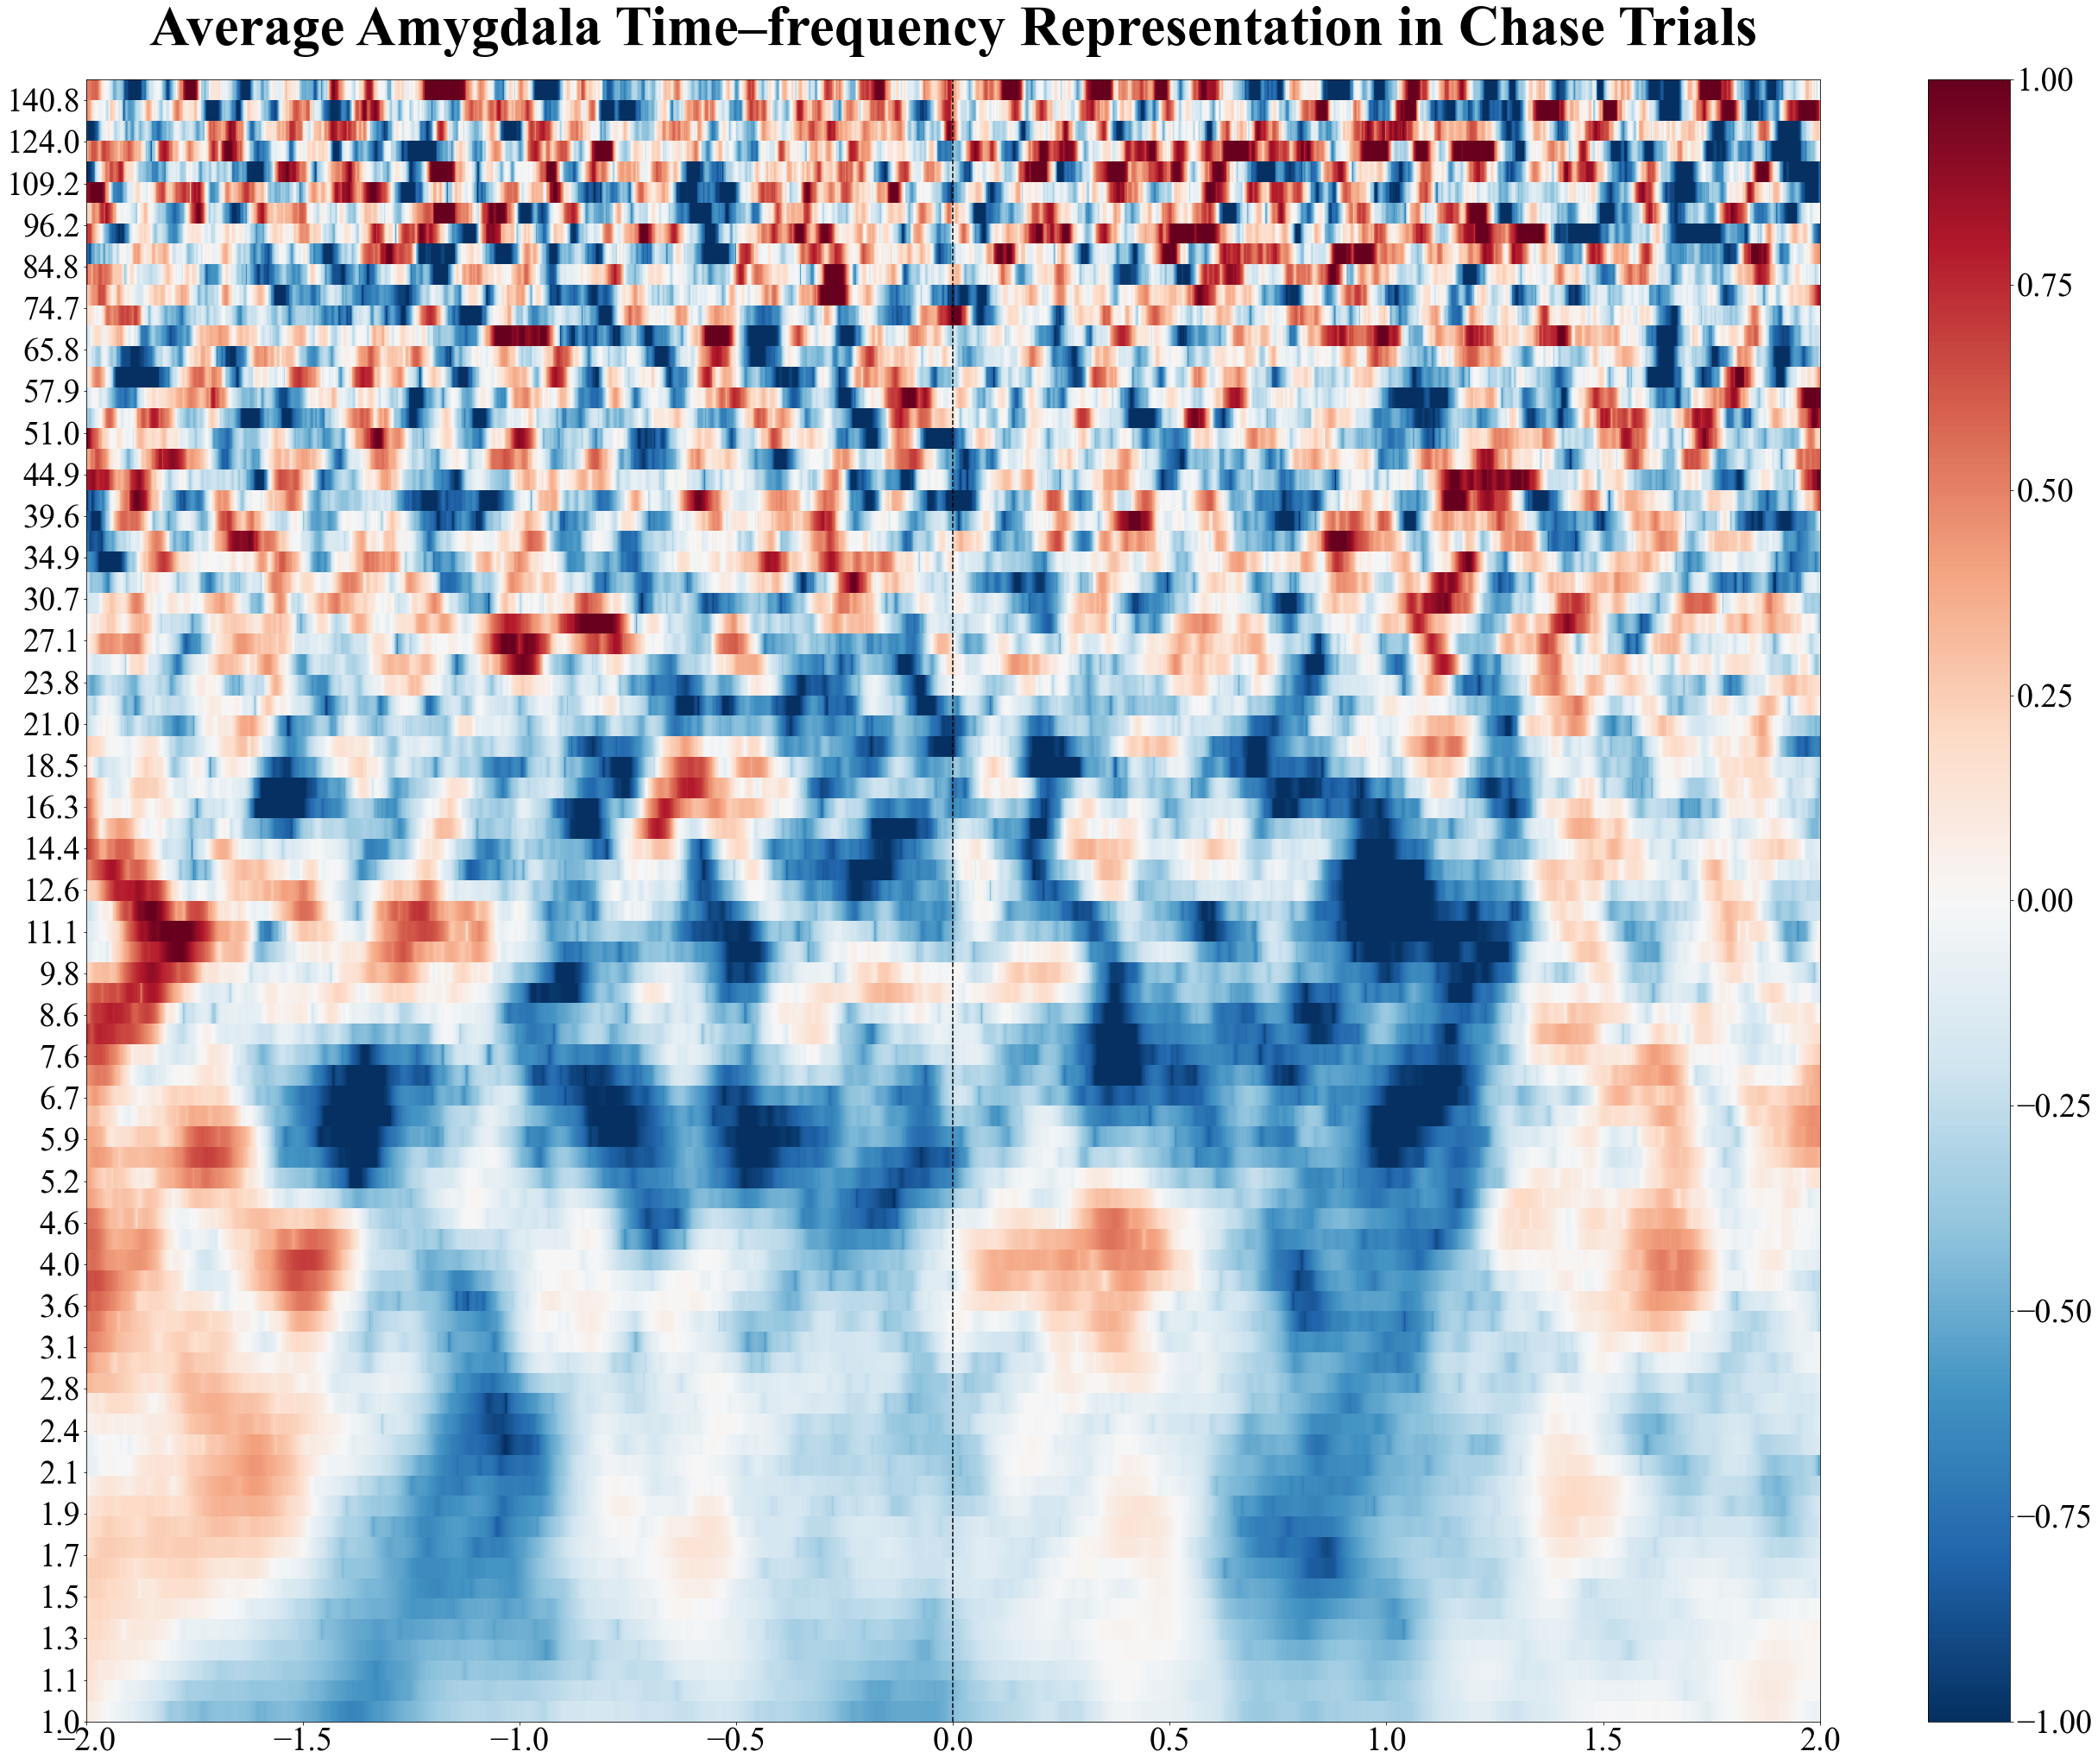

In [18]:
plot_allsub_averages(all_subs_average_amyg_chase, "Average Amygdala Time–frequency Representation in Chase Trials", 'average_amyg_chase_all_subs.png', -2, 2)

In [2]:
plot_allsub_averages(all_subs_average_amyg_die, "Average Amygdala Time–frequency Representation in Death Trials", 'average_amyg_death_all_subs.png', -2, 2)

# Other Regions

## dlPFC

In [20]:
all_subs_average_dlpfcs = calculate_trial_end_average(sub_list, conditions, 'dlpfc')
all_subs_average_dlpfc_escape = all_subs_average_dlpfcs[0]
all_subs_average_dlpfc_chase = all_subs_average_dlpfcs[1]
all_subs_average_dlpfc_die = all_subs_average_dlpfcs[2]

Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH021/ieeg/trial_end/dlpfc-tfr.h5 ...
Adding metadata with 6 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH021']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH025/ieeg/trial_end/dlpfc-tfr.h5 ...
Adding metadata with 6 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH021', 'BJH025']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH016/ieeg/trial_end/dlpfc-tfr.h5 ...
Adding metadata with 6 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH021', 'BJH025', 'BJH016']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/SLCH002/ieeg/trial_end/dlpfc-tfr.h5 ...
Adding metadata with 5 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH021', 'BJH025', 'BJH016', 'SLCH002']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH026/ieeg/trial_e

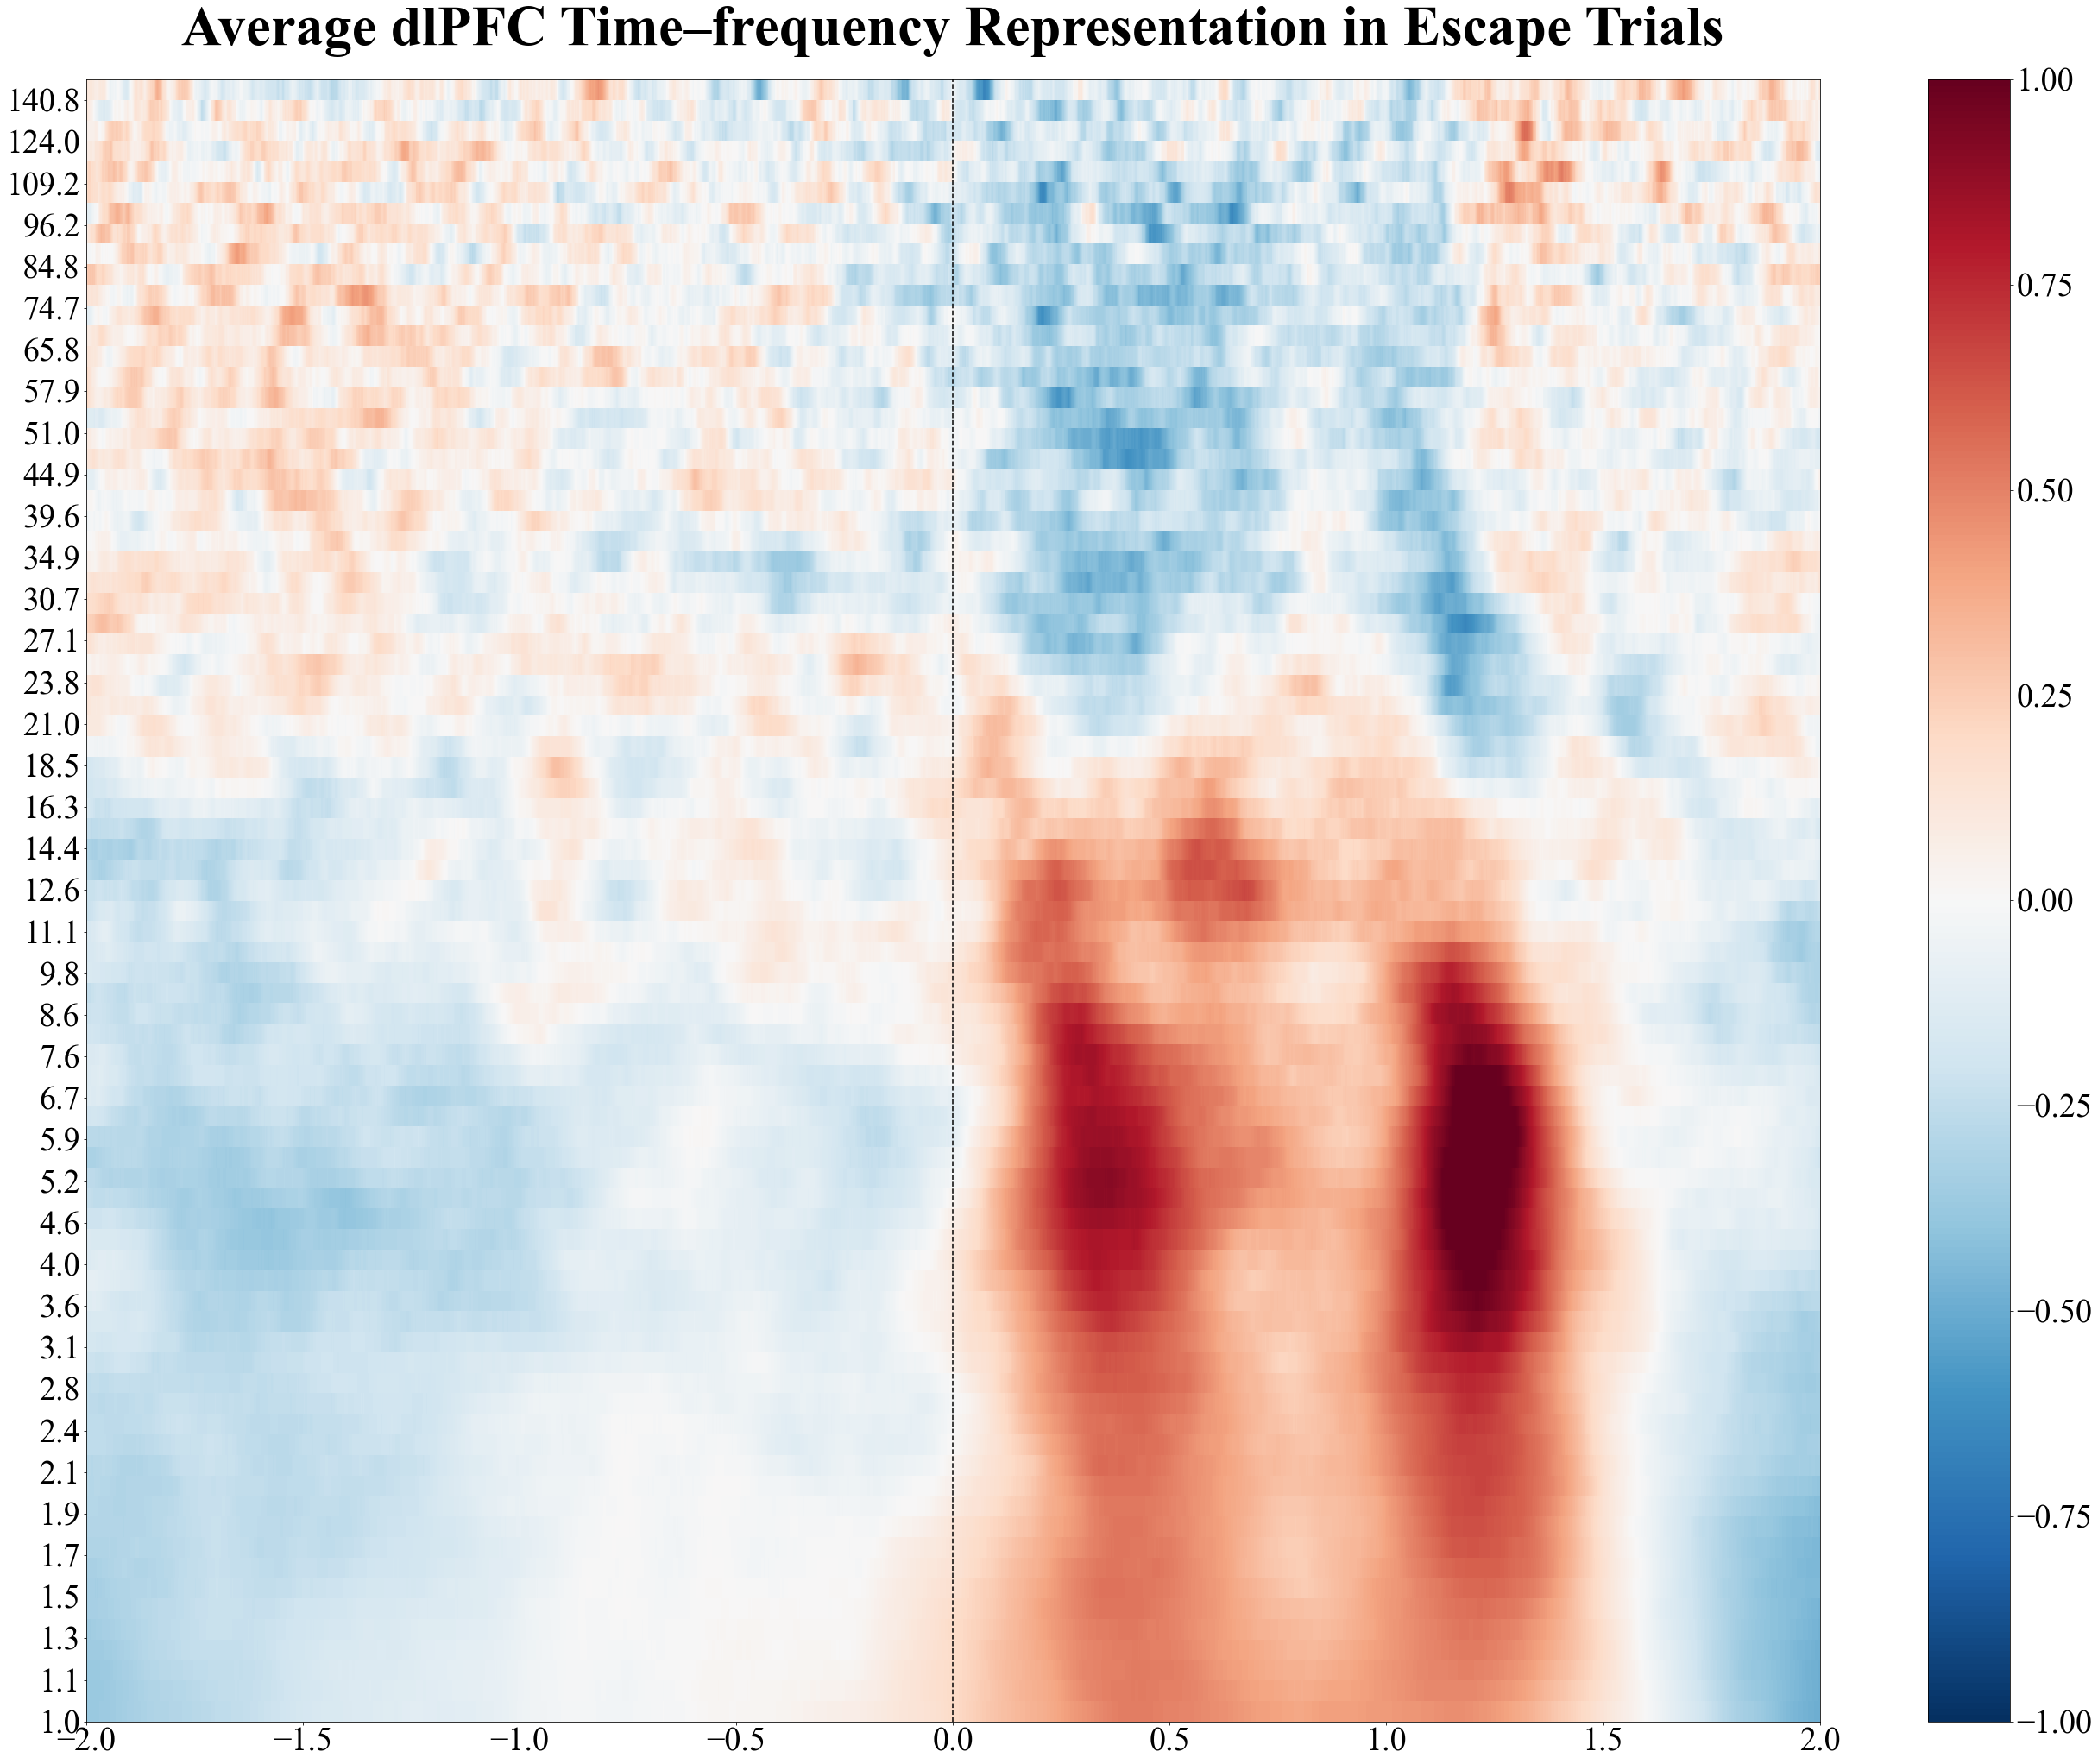

In [21]:
plot_allsub_averages(all_subs_average_dlpfc_escape, "Average dlPFC Time–frequency Representation in Escape Trials", 'average_dlpfc_escape_all_subs.png', -2, 2)

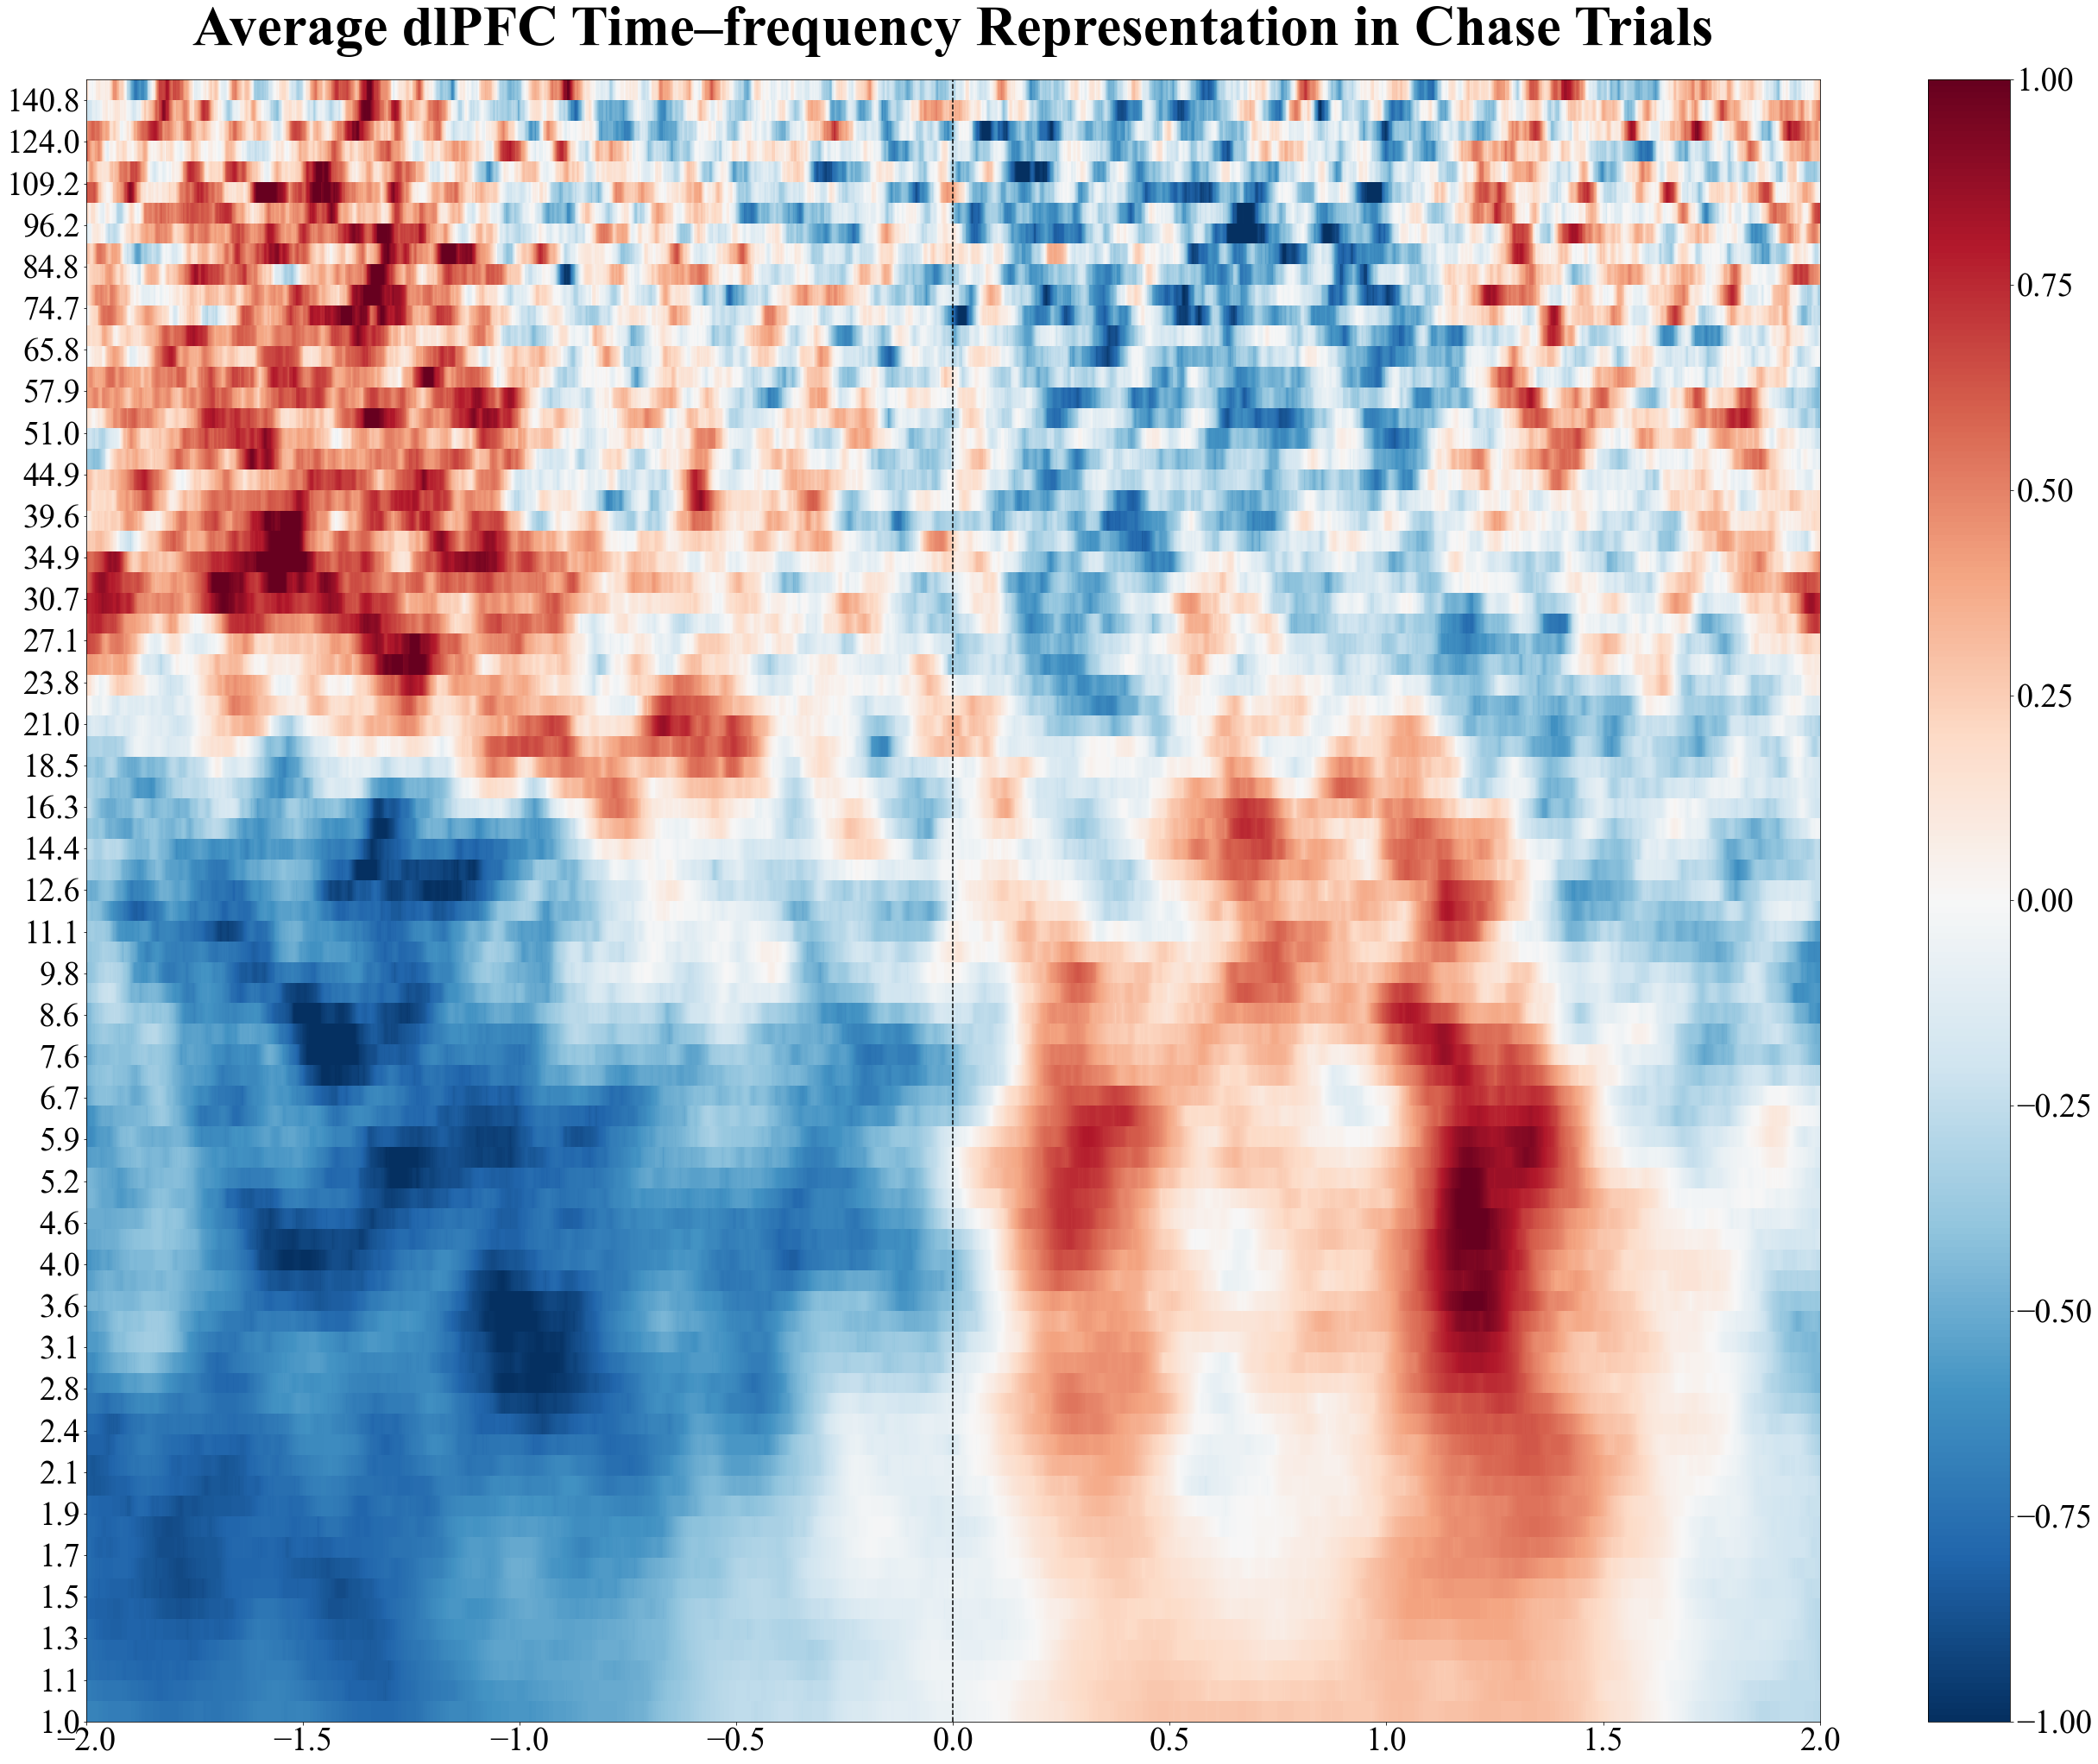

In [22]:
plot_allsub_averages(all_subs_average_dlpfc_chase, "Average dlPFC Time–frequency Representation in Chase Trials", 'average_dlpfc_chase_all_subs.png', -2, 2)

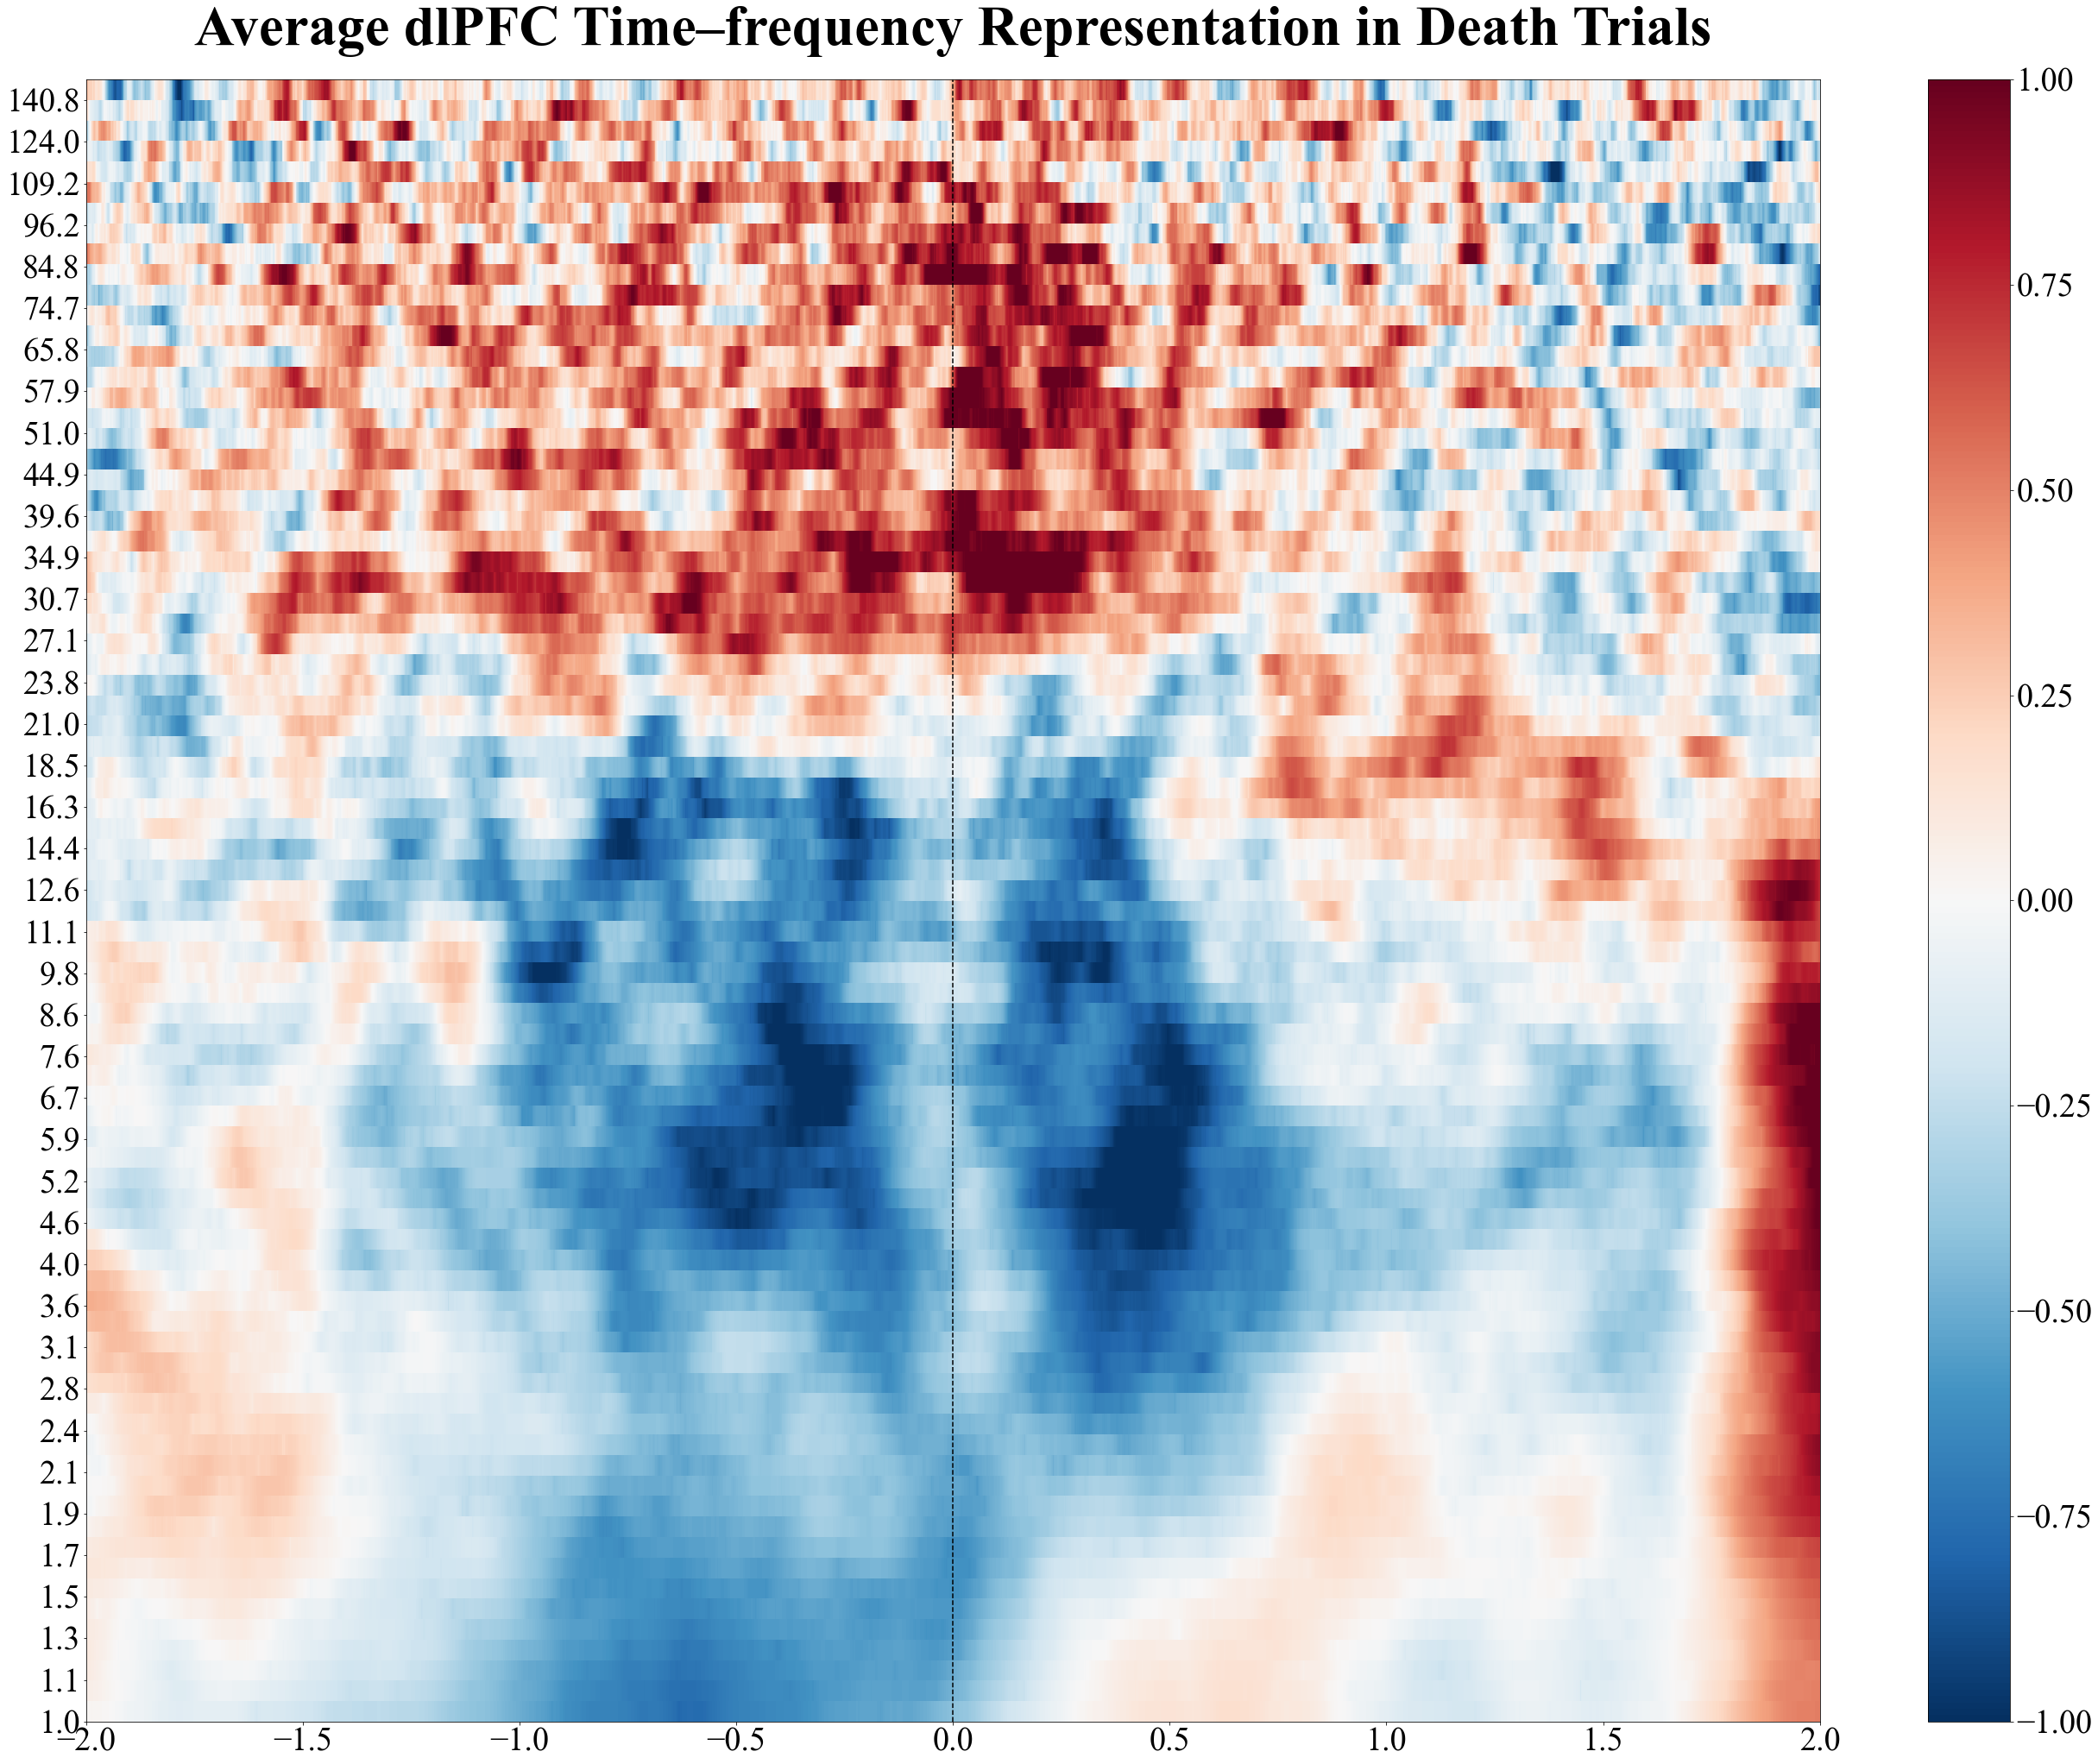

In [23]:
plot_allsub_averages(all_subs_average_dlpfc_die, "Average dlPFC Time–frequency Representation in Death Trials", 'average_dlpfc_death_all_subs.png', -2, 2)

## Insula

In [24]:
all_subs_average_insulas = calculate_trial_end_average(sub_list, conditions, 'insula')
all_subs_average_insula_escape = all_subs_average_insulas[0]
all_subs_average_insula_chase = all_subs_average_insulas[1]
all_subs_average_insula_die = all_subs_average_insulas[2]

Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH021/ieeg/trial_end/insula-tfr.h5 ...
Adding metadata with 6 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH021']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH025/ieeg/trial_end/insula-tfr.h5 ...
Adding metadata with 6 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH021', 'BJH025']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH016/ieeg/trial_end/insula-tfr.h5 ...
Adding metadata with 6 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH021', 'BJH025', 'BJH016']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/SLCH002/ieeg/trial_end/insula-tfr.h5 ...
Adding metadata with 5 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH021', 'BJH025', 'BJH016', 'SLCH002']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH026/ieeg/tri

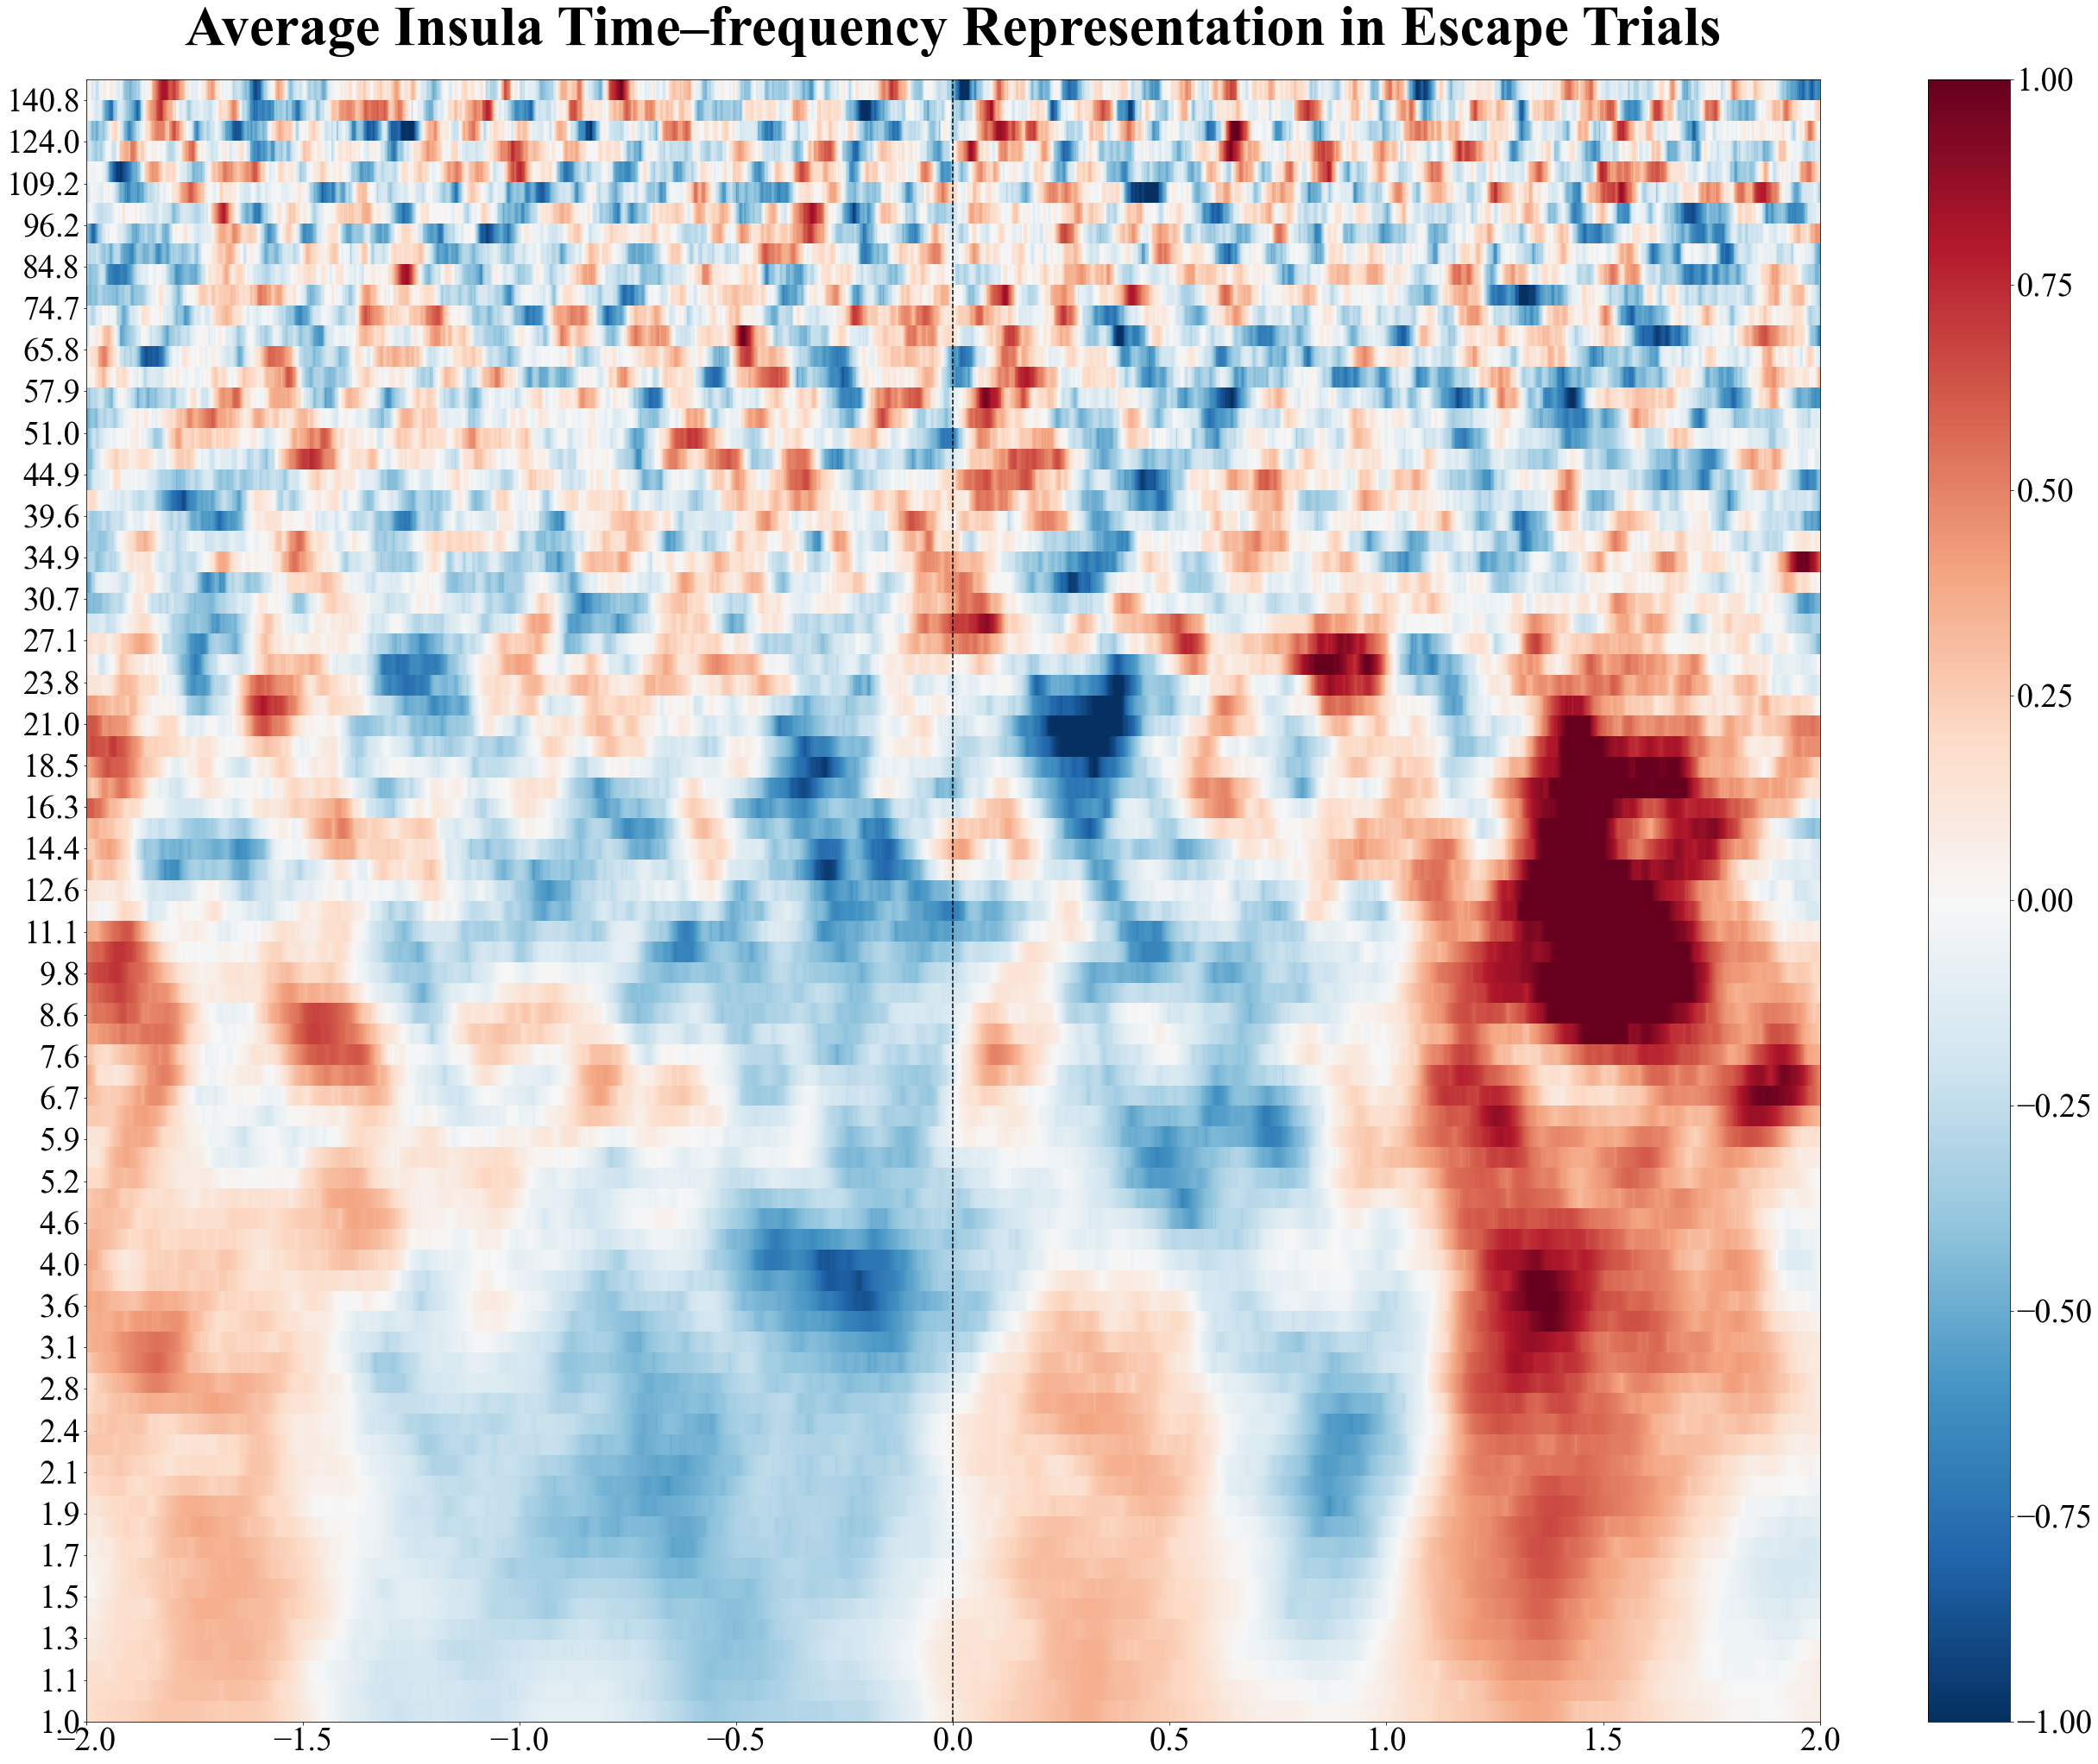

In [25]:
plot_allsub_averages(all_subs_average_insula_escape, "Average Insula Time–frequency Representation in Escape Trials", 'average_insula_escape_all_subs.png', -2, 2)

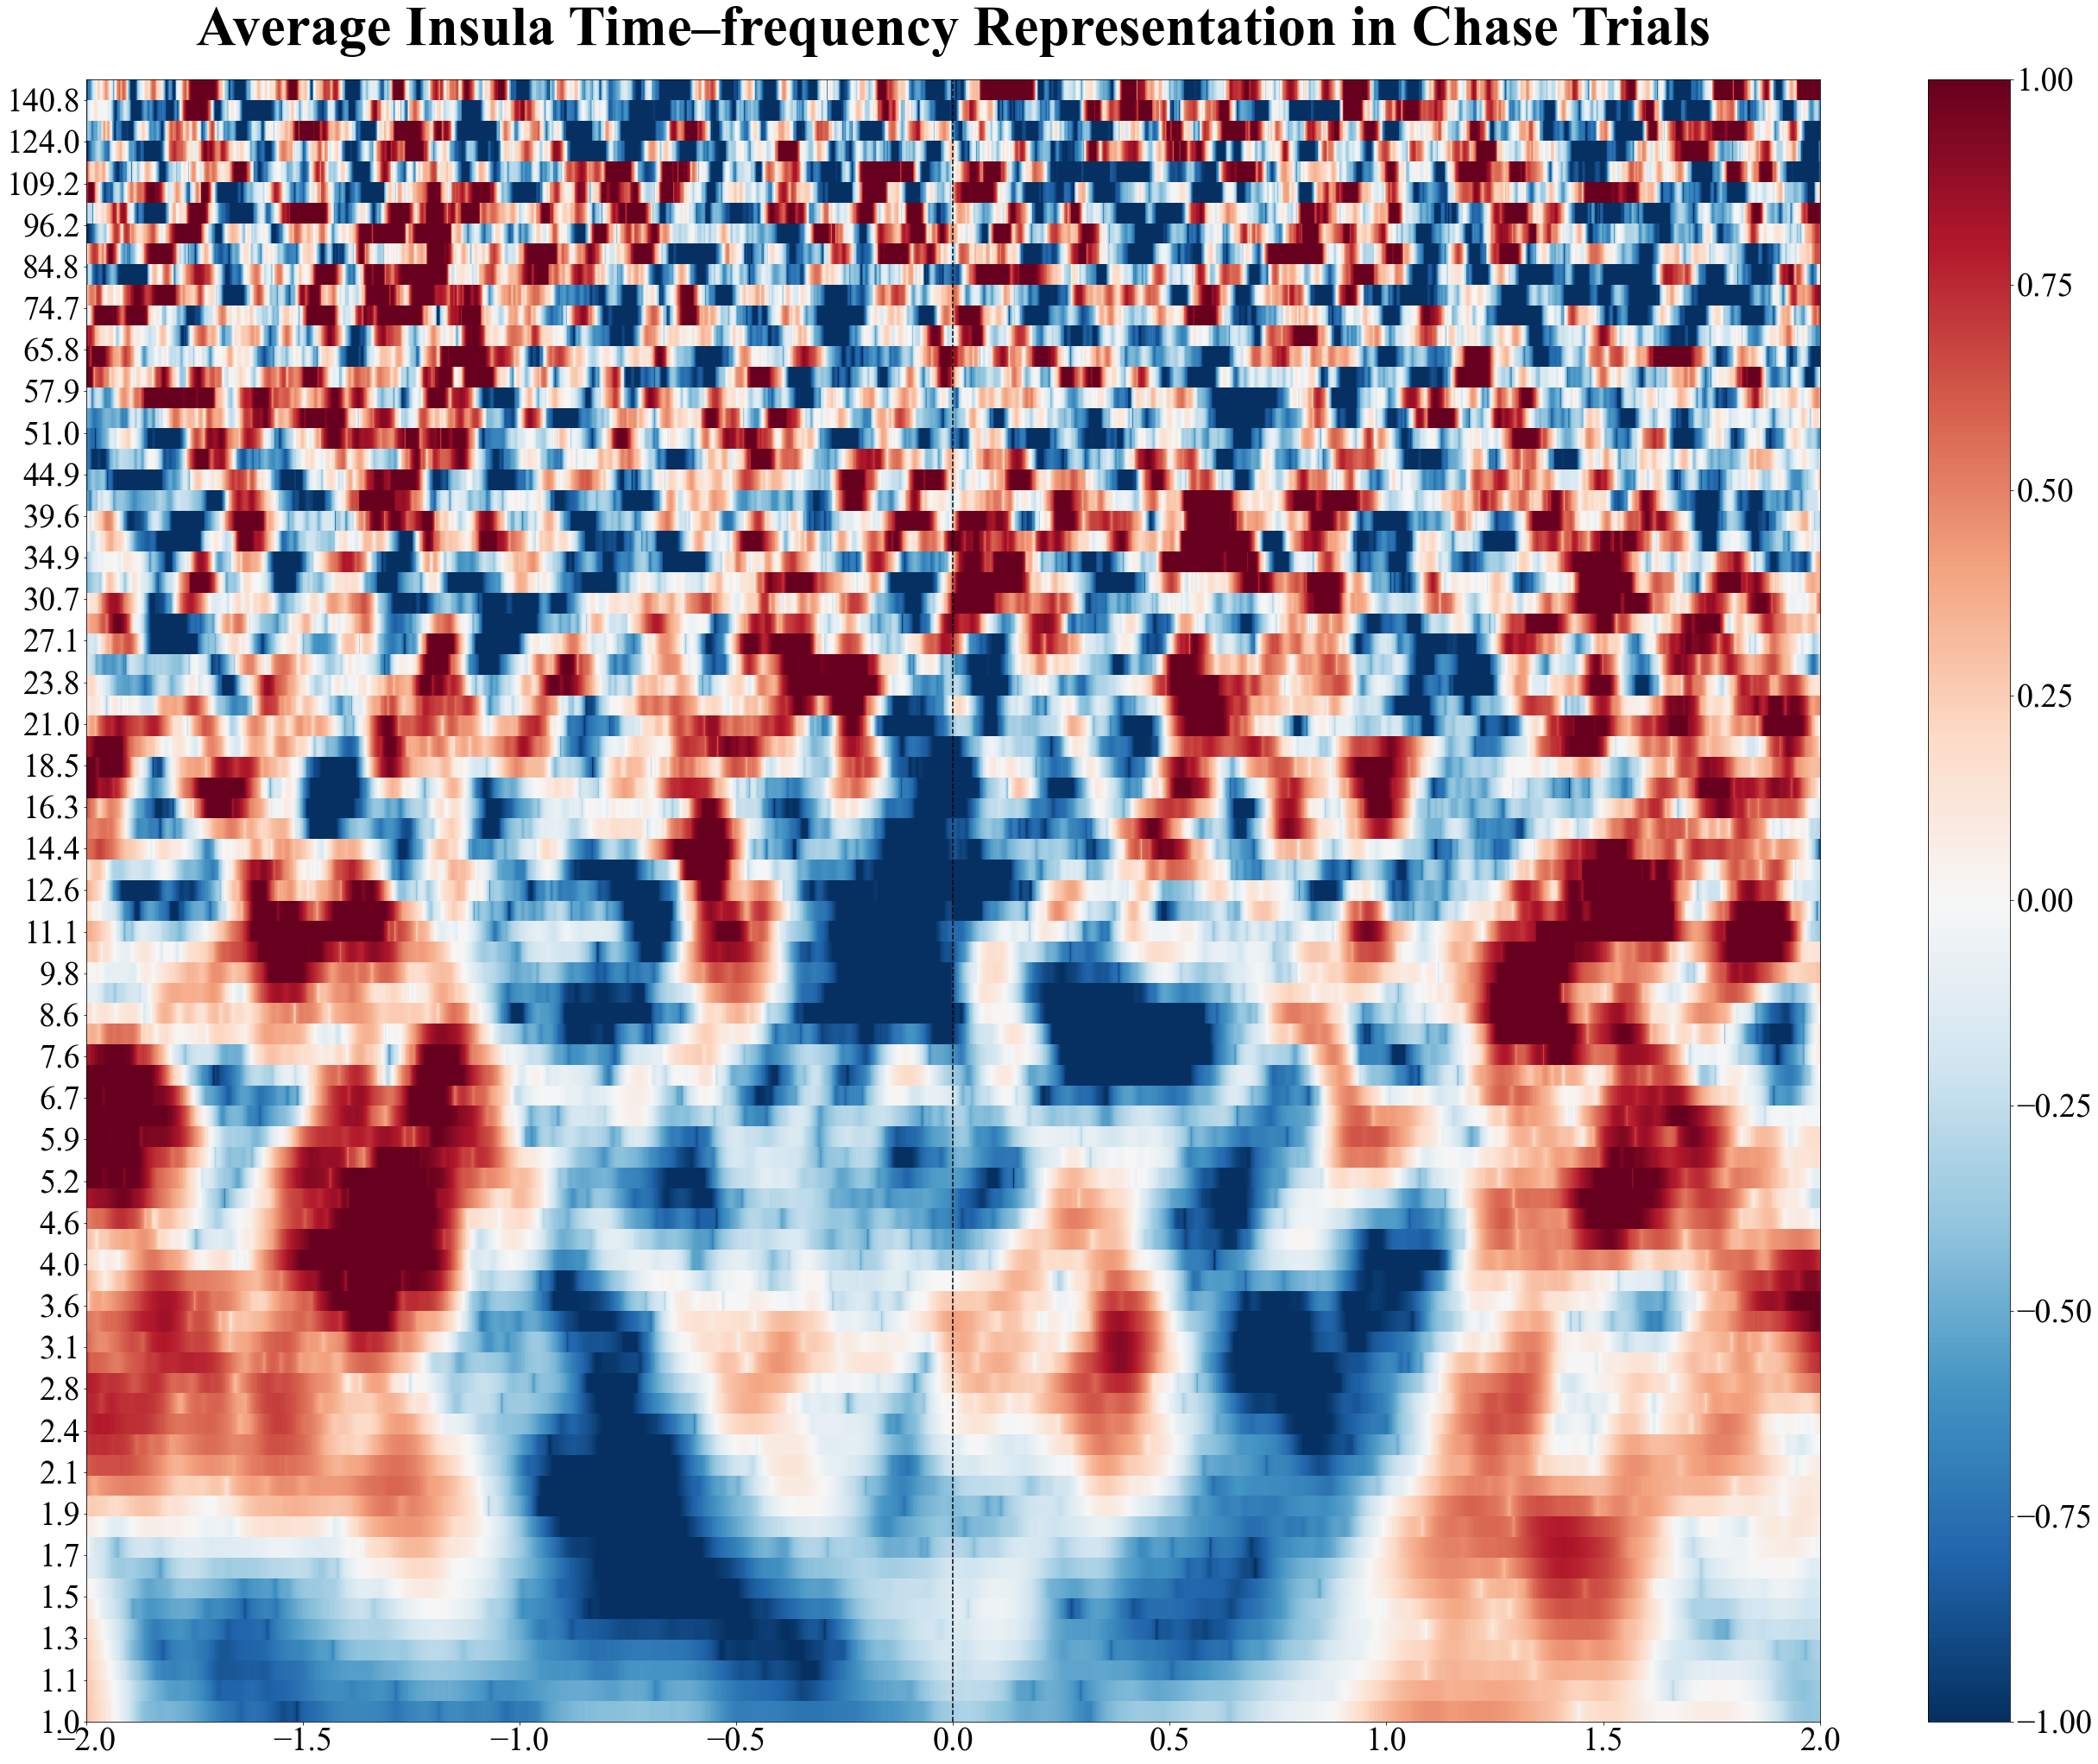

In [26]:
plot_allsub_averages(all_subs_average_insula_chase, "Average Insula Time–frequency Representation in Chase Trials", 'average_insula_chase_all_subs.png', -2, 2)

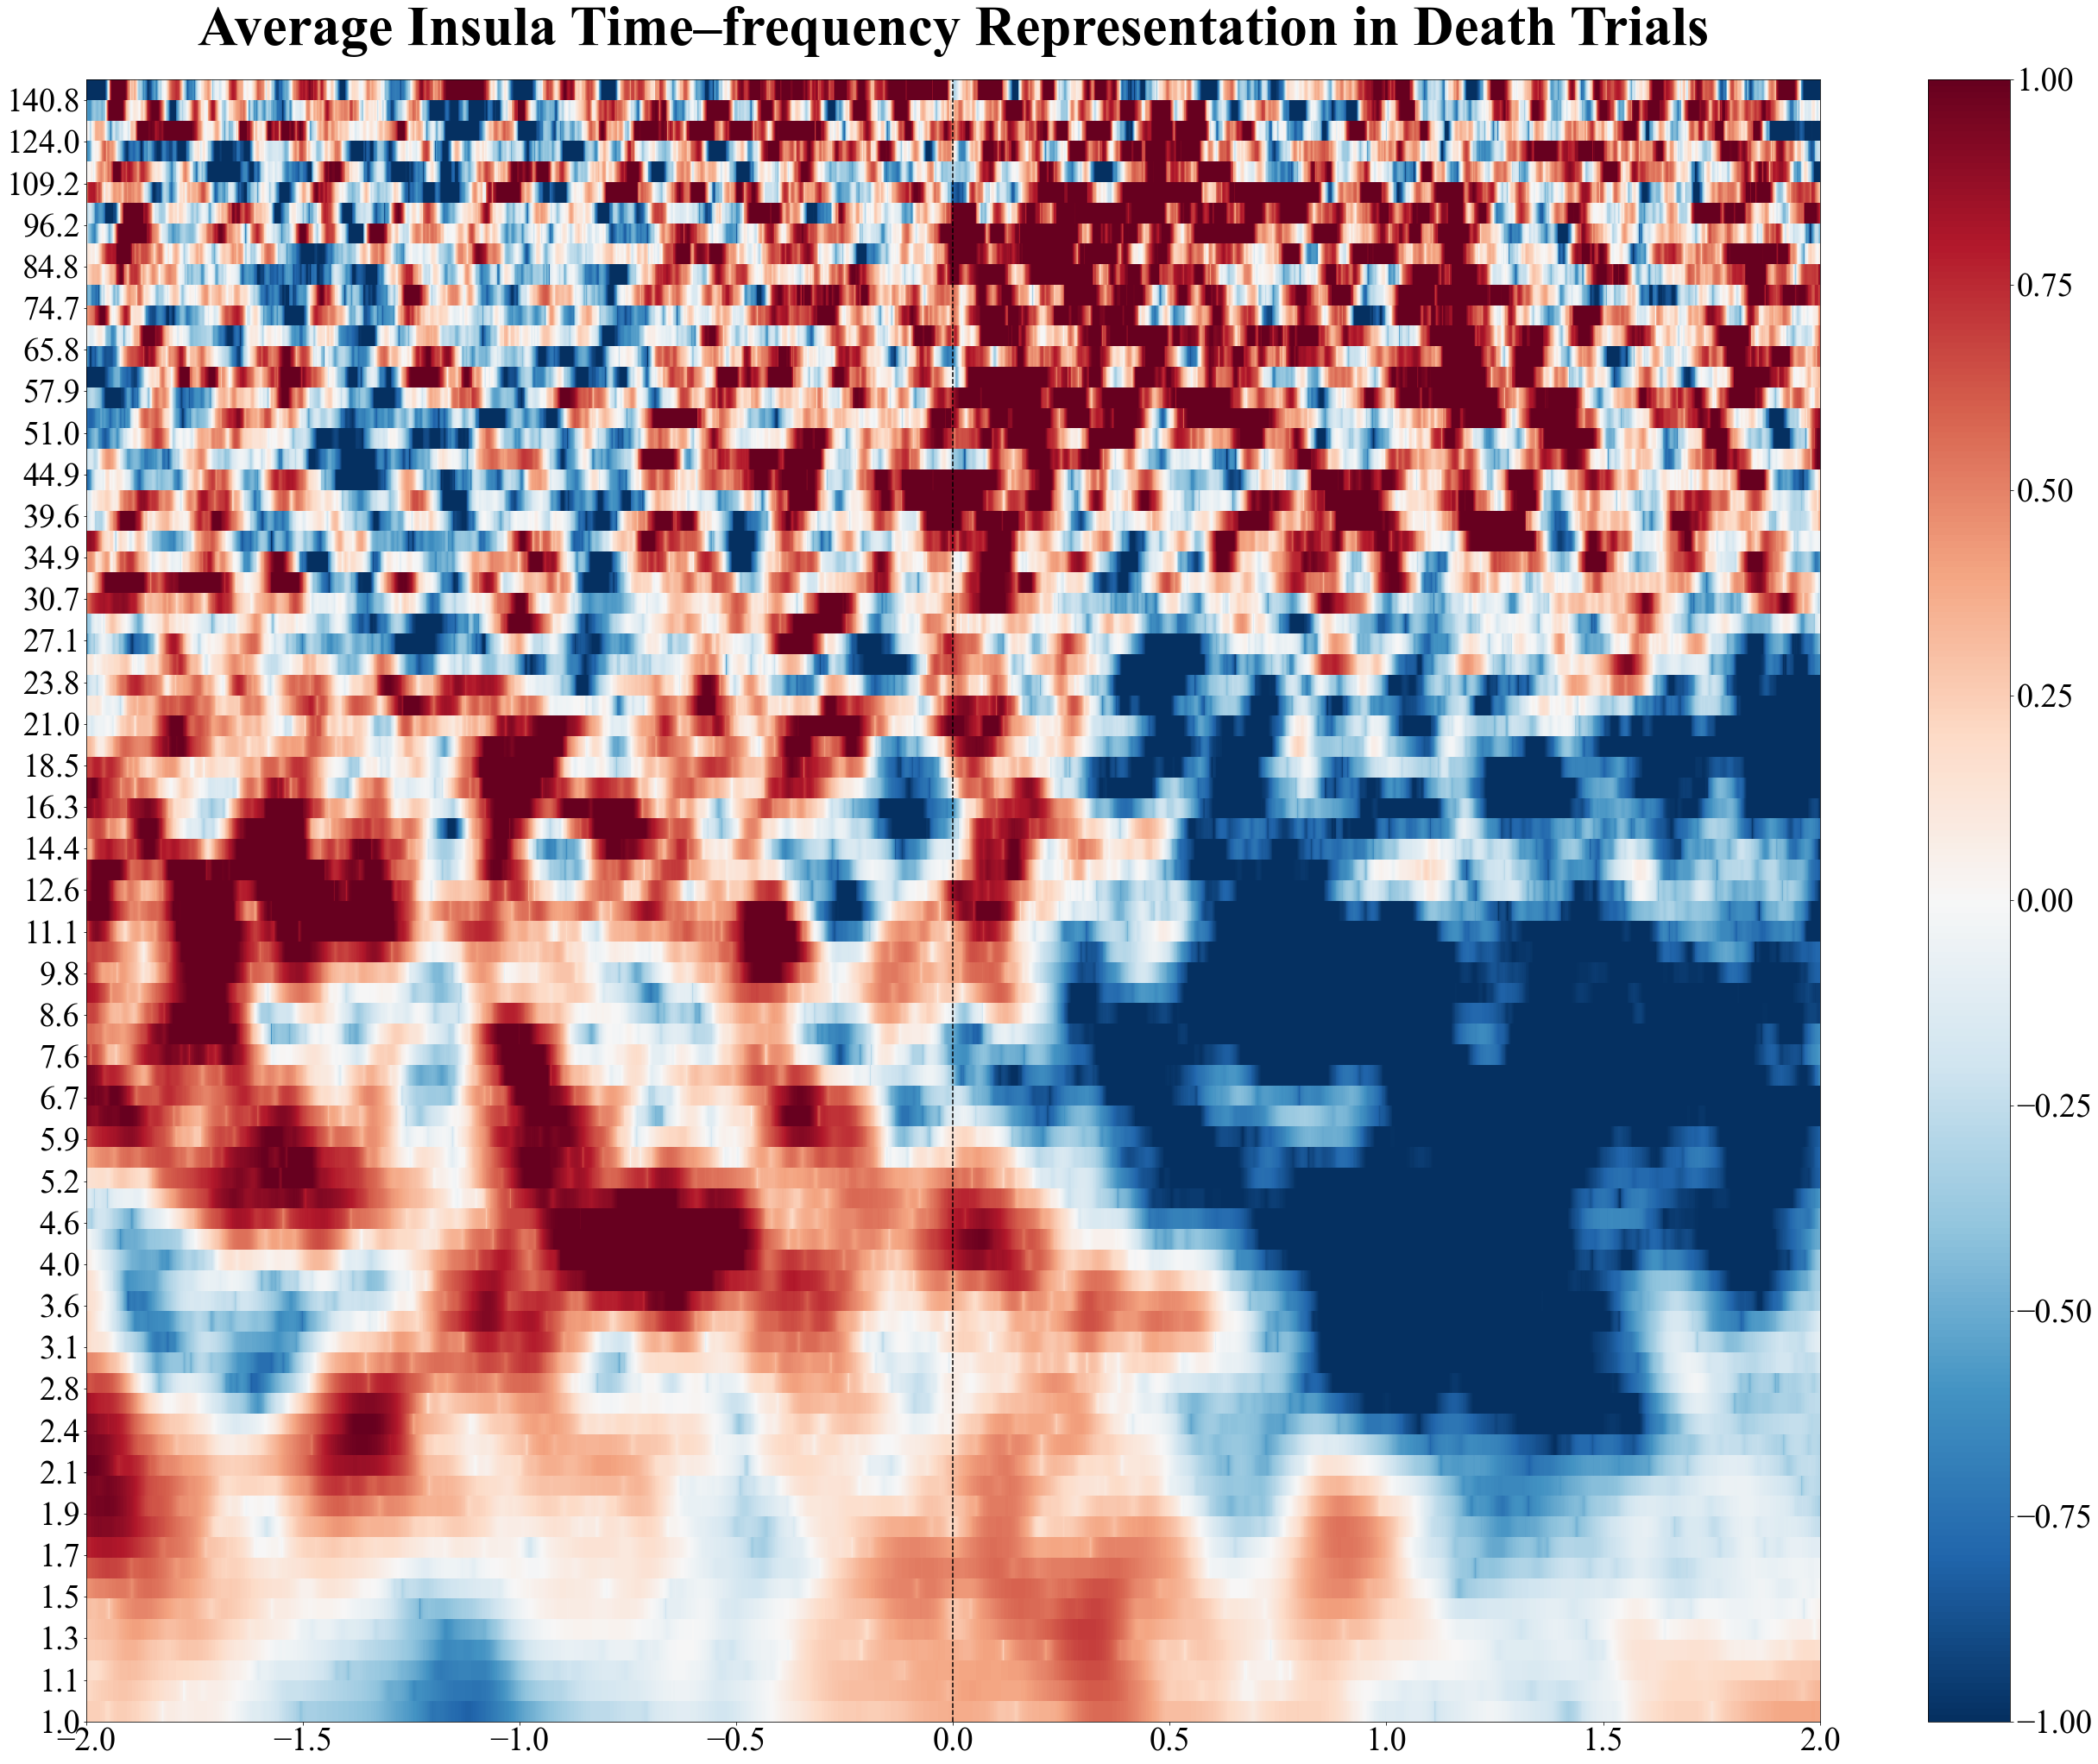

In [27]:
plot_allsub_averages(all_subs_average_insula_die, "Average Insula Time–frequency Representation in Death Trials", 'average_insula_death_all_subs.png', -2, 2)

## EC

In [28]:
all_subs_average_ecs = calculate_trial_end_average(sub_list, conditions, 'ec')
all_subs_average_ec_escape = all_subs_average_ecs[0]
all_subs_average_ec_chase = all_subs_average_ecs[1]
all_subs_average_ec_die = all_subs_average_ecs[2]

currently used subs: []
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH025/ieeg/trial_end/ec-tfr.h5 ...
Adding metadata with 6 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH025']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH016/ieeg/trial_end/ec-tfr.h5 ...
Adding metadata with 6 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH025', 'BJH016']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/SLCH002/ieeg/trial_end/ec-tfr.h5 ...
Adding metadata with 5 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH025', 'BJH016', 'SLCH002']
currently used subs: ['BJH025', 'BJH016', 'SLCH002']
Reading /home/brooke/knight_server/remote/bstavel/pacman/preprocessing/BJH027/ieeg/trial_end/ec-tfr.h5 ...
Adding metadata with 6 columns
log transforming
z-scoring to baseline
currently used subs: ['BJH025', 'BJH016', 'SLCH002', 'BJH027']
Reading /home/brooke/kni

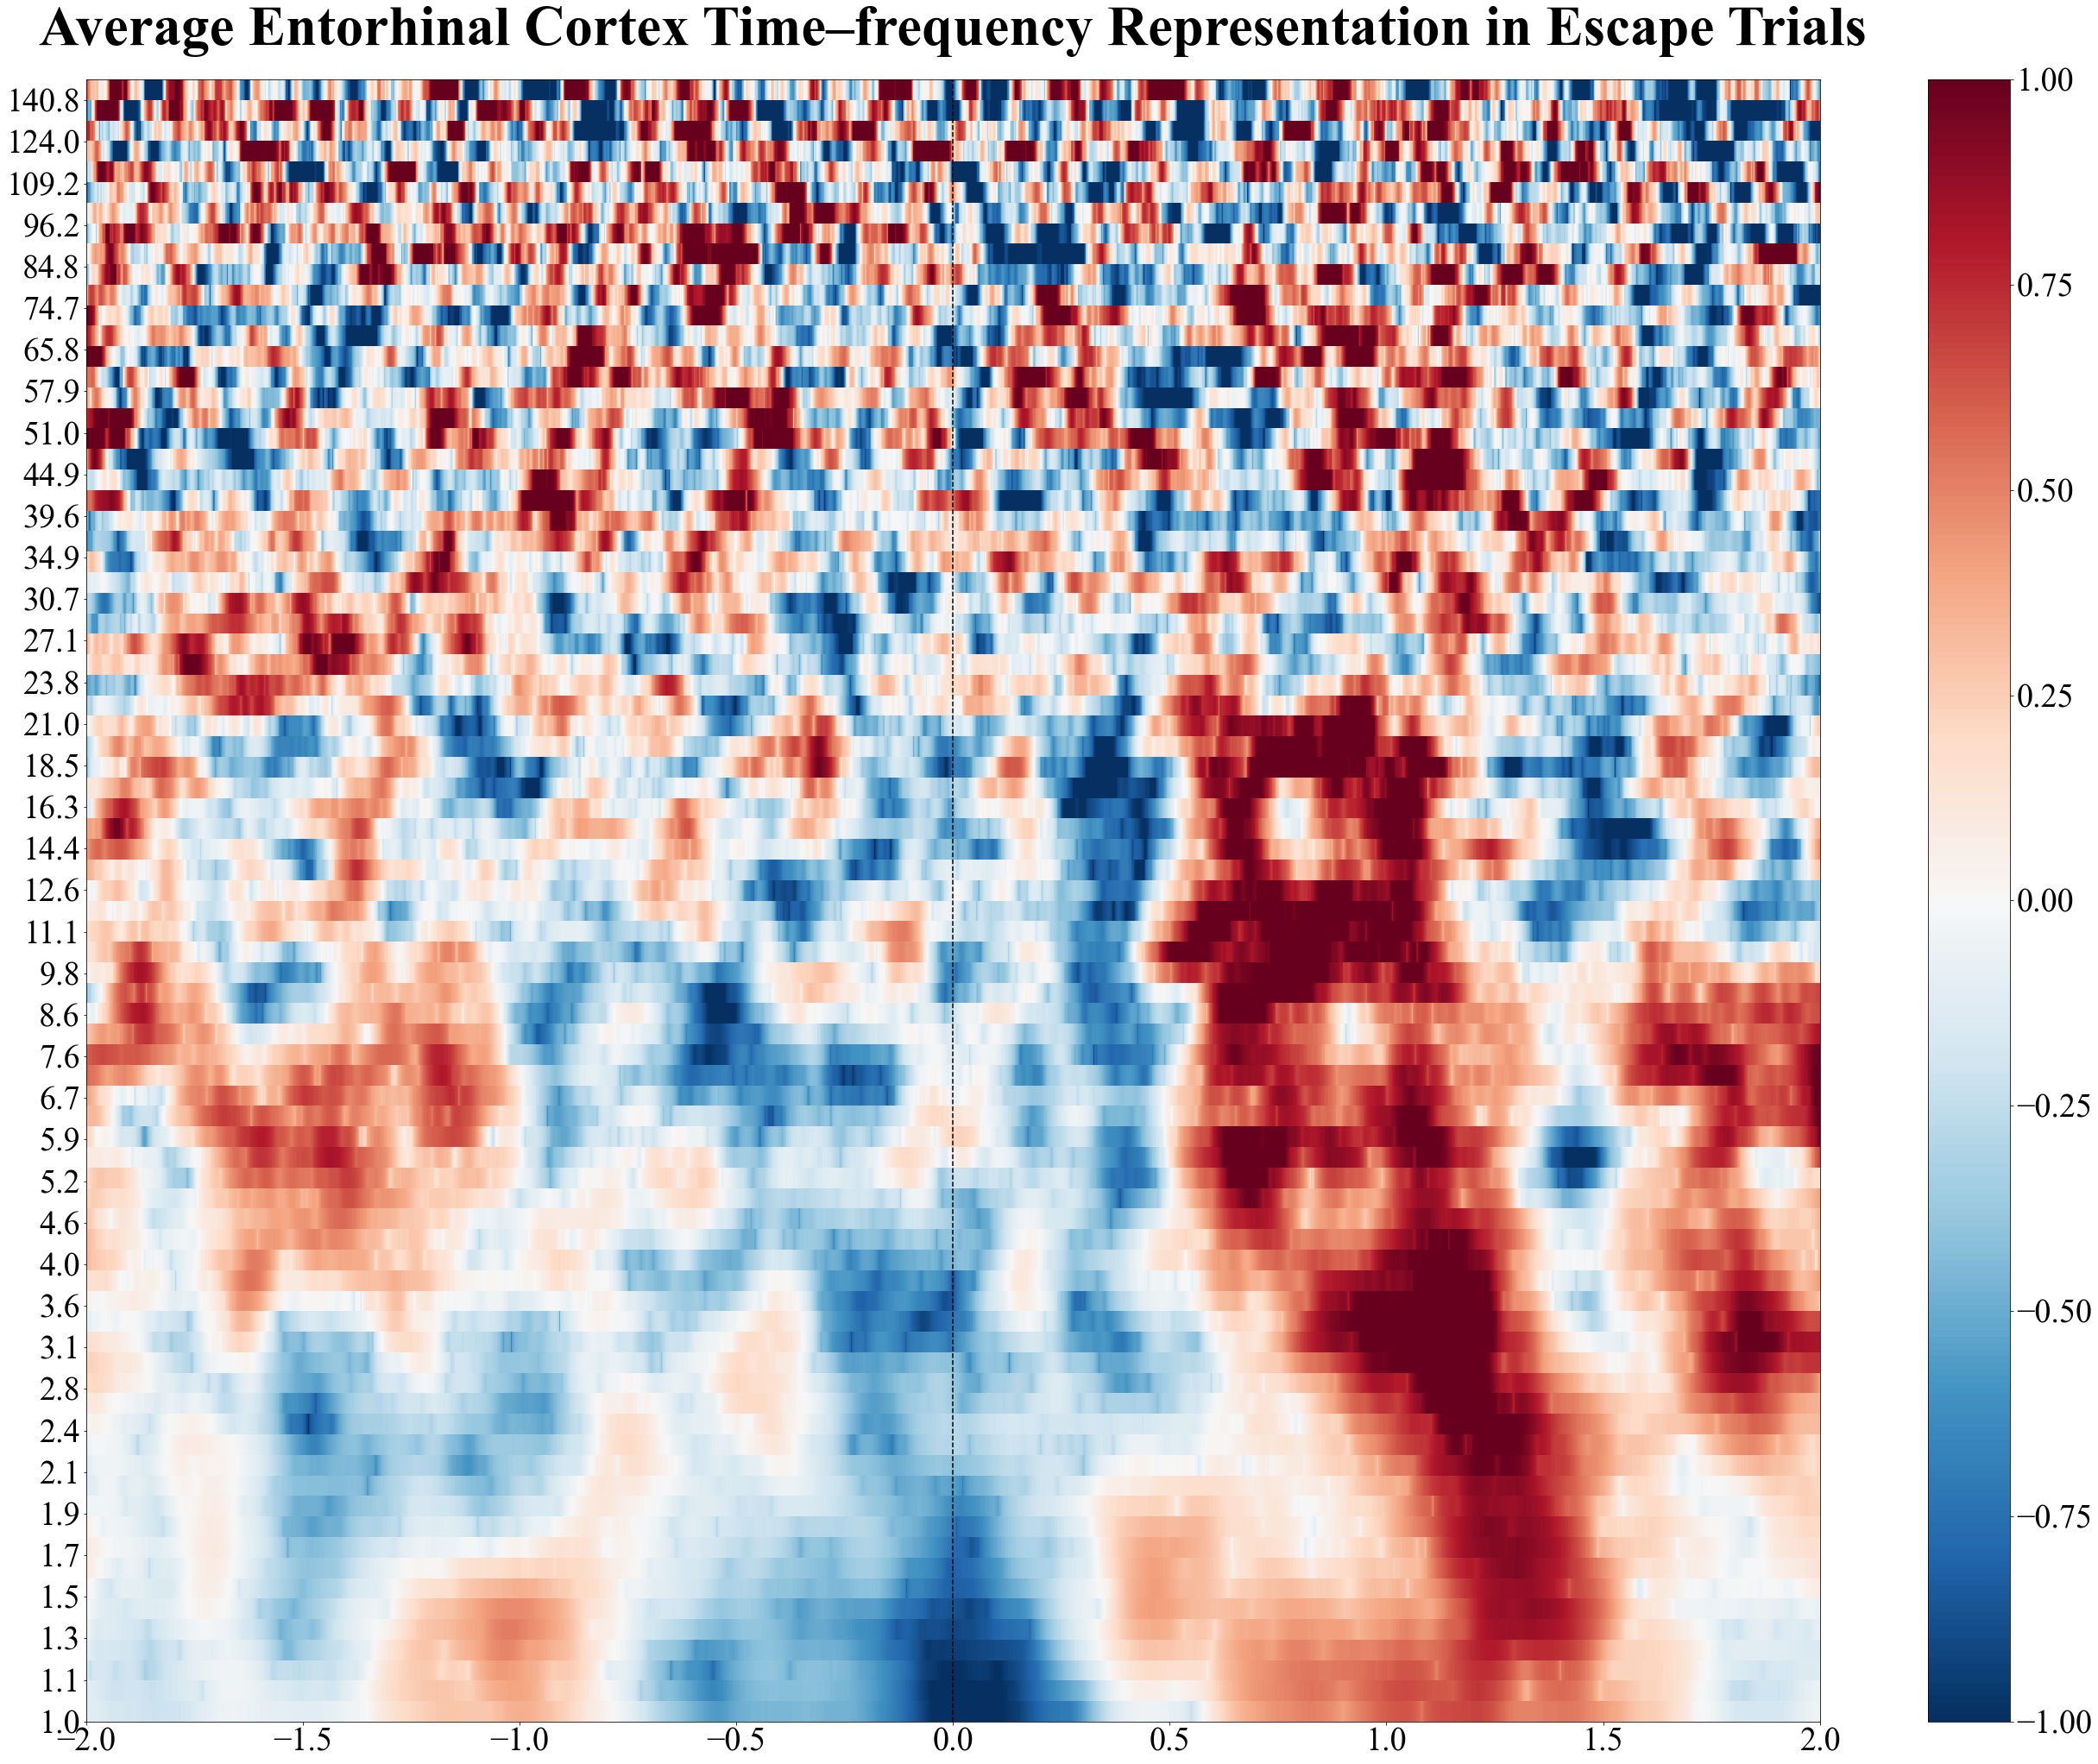

In [29]:
plot_allsub_averages(all_subs_average_ec_escape, "Average Entorhinal Cortex Time–frequency Representation in Escape Trials", 'average_ec_escape_all_subs.png', -2, 2)

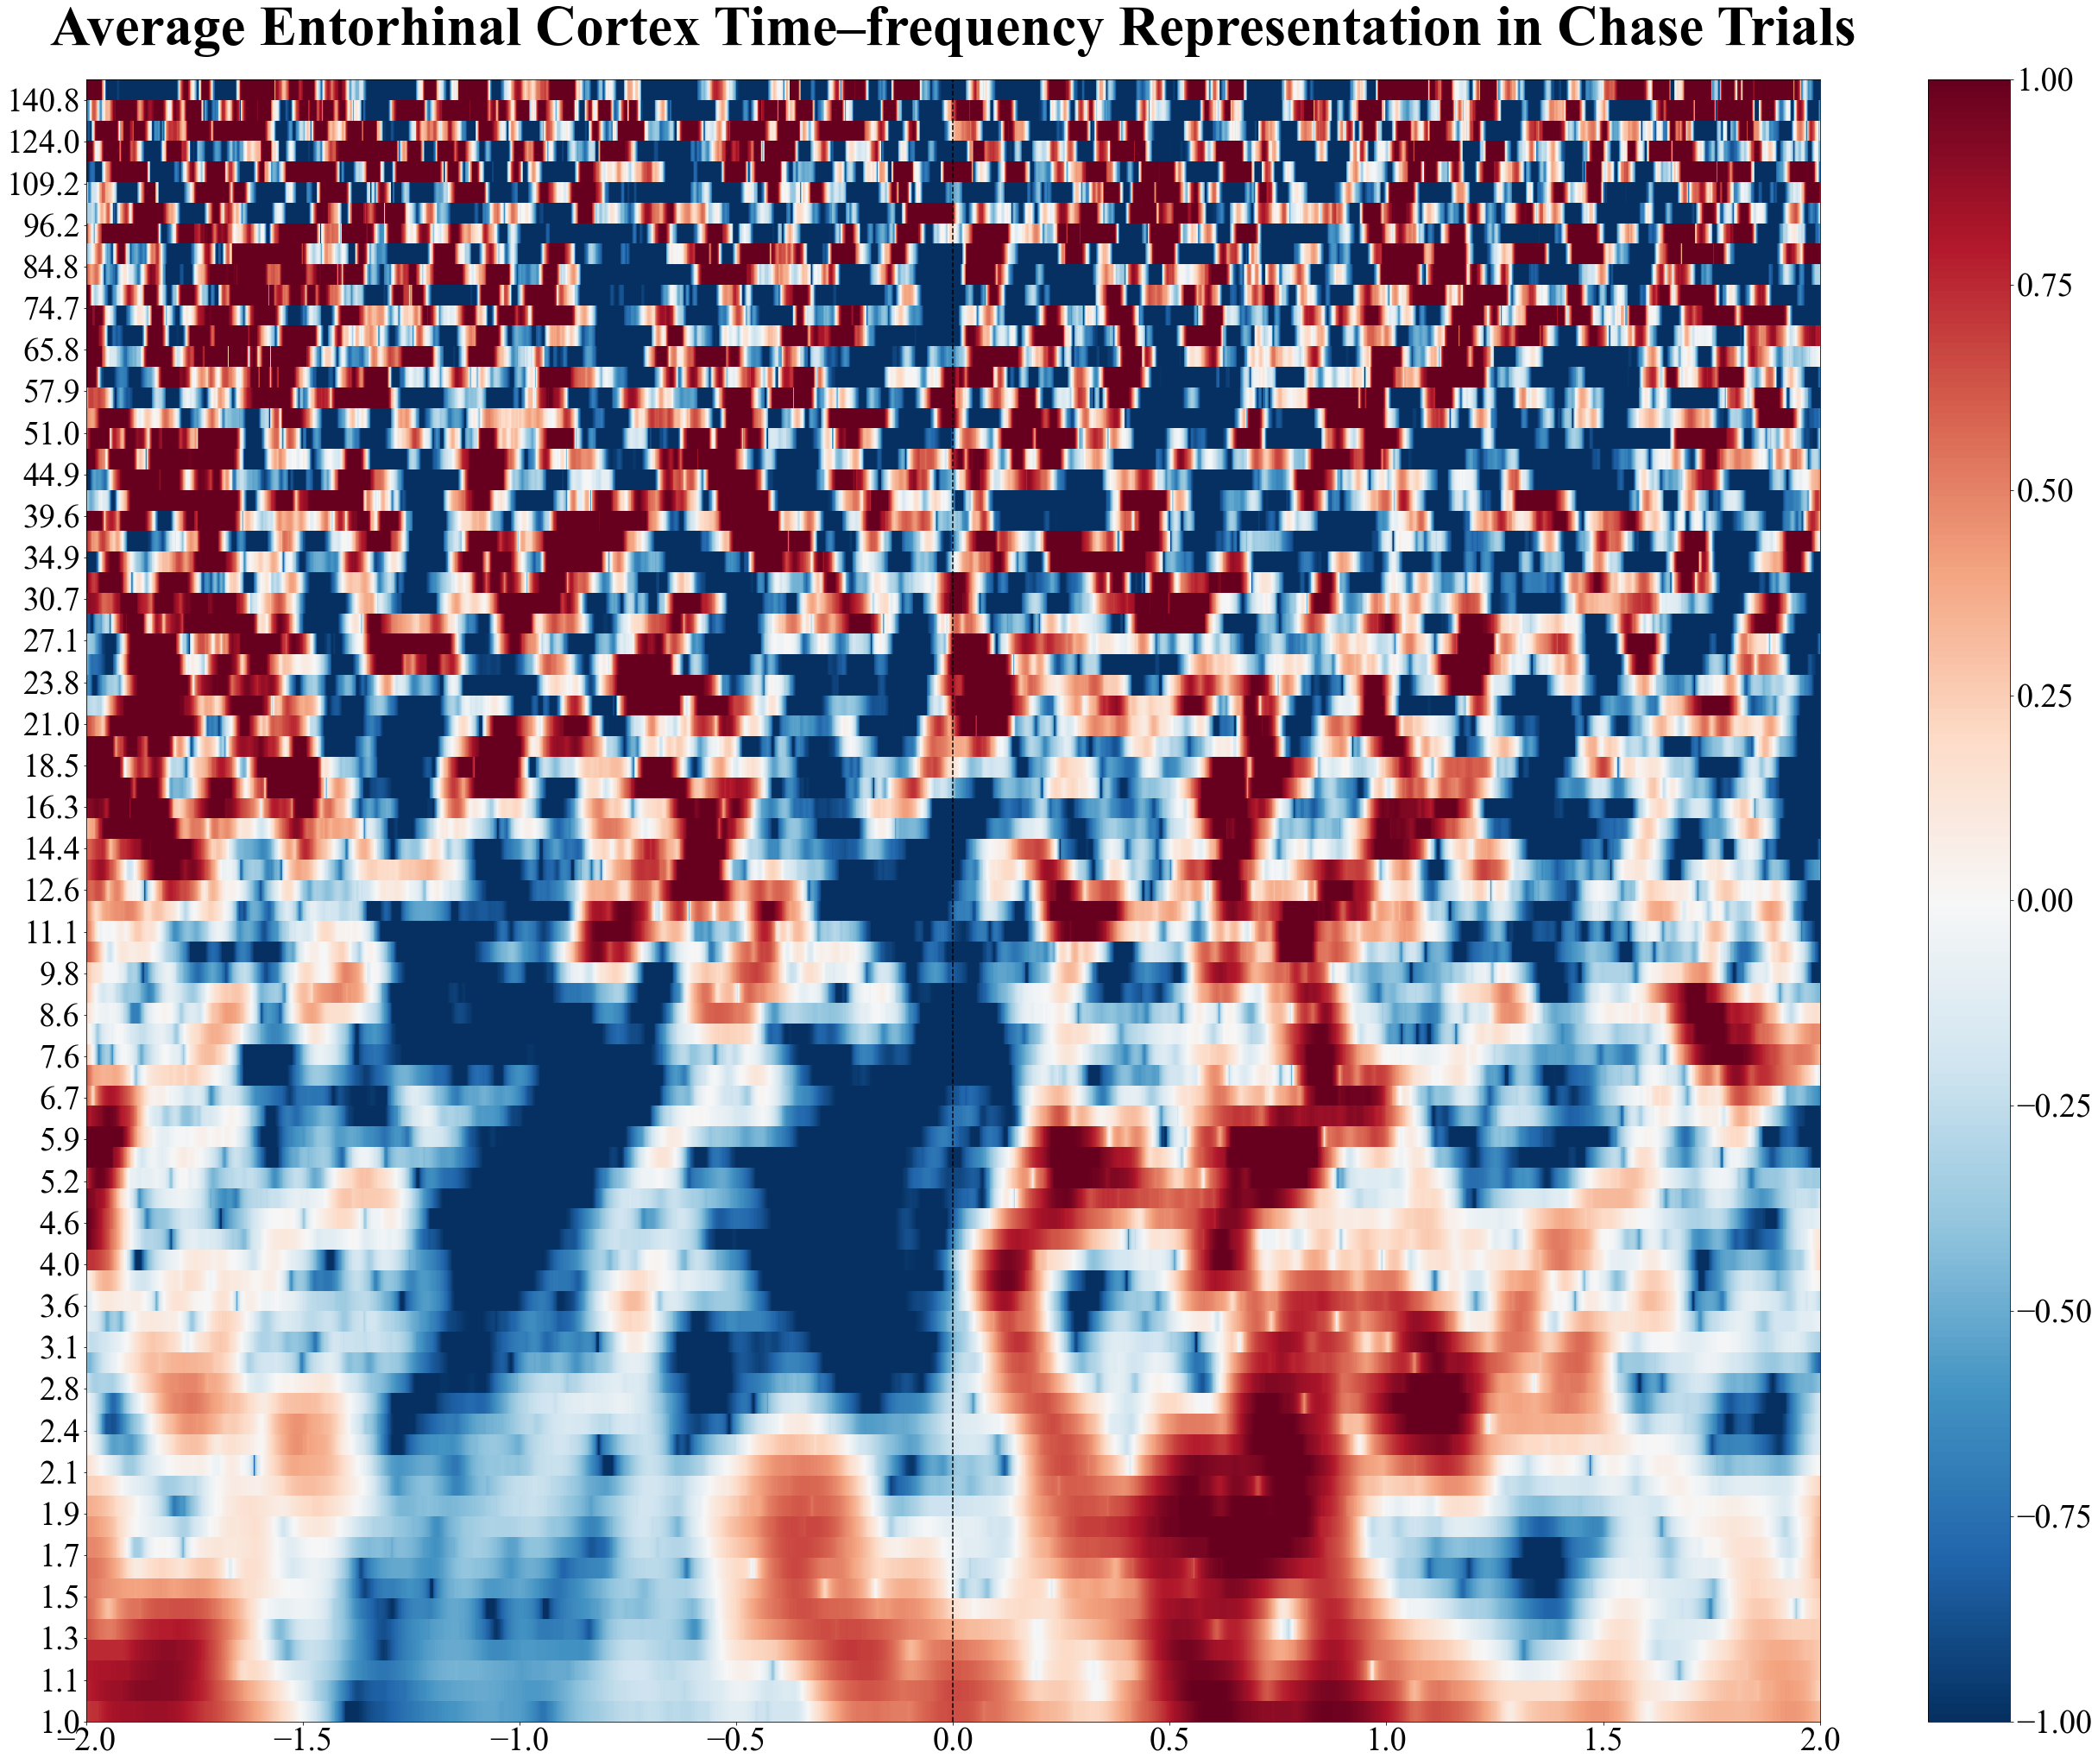

In [30]:
plot_allsub_averages(all_subs_average_ec_chase, "Average Entorhinal Cortex Time–frequency Representation in Chase Trials", 'average_ec_chase_all_subs.png', -2, 2)

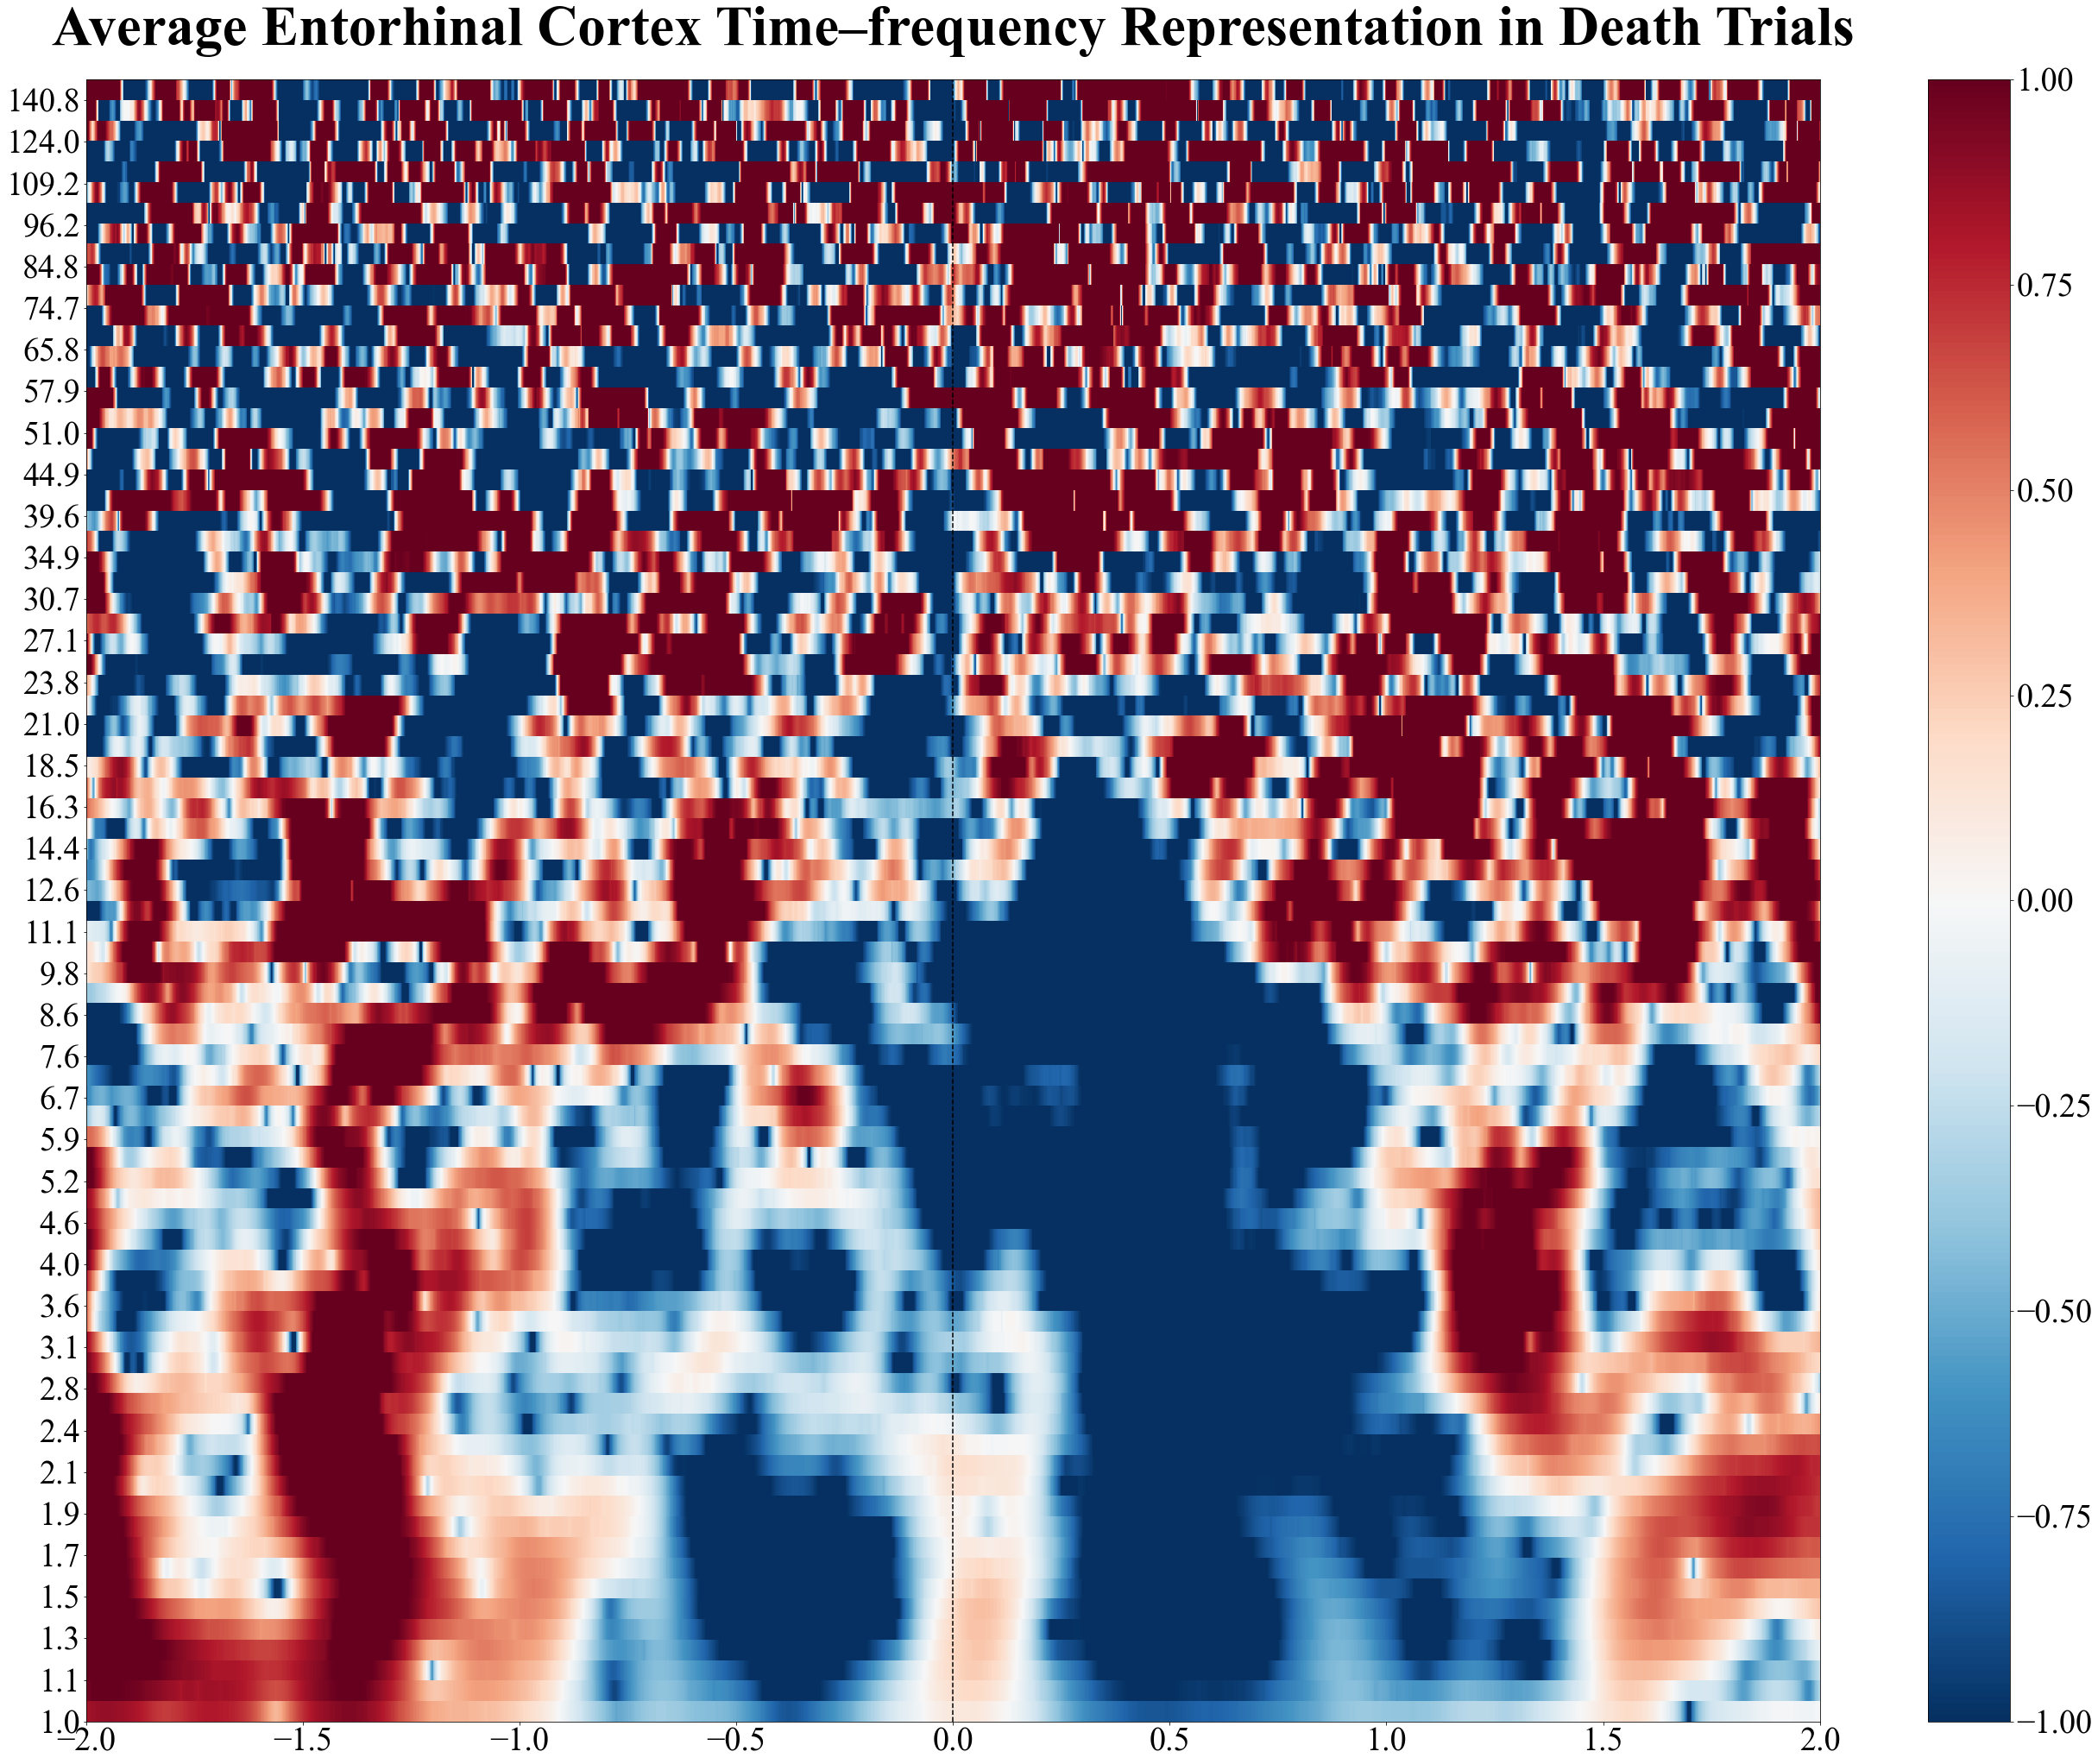

In [31]:
plot_allsub_averages(all_subs_average_ec_die, "Average Entorhinal Cortex Time–frequency Representation in Death Trials", 'average_ec_death_all_subs.png', -2, 2)